<a href="https://colab.research.google.com/github/drdwaynem/Trial/blob/main/Dwayne_AI_Pain.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# ============================================================
# STEP 1: Install packages and check runtime
# ============================================================

import sys, os, platform, subprocess, importlib.util, random, warnings
from pathlib import Path

print("Python:", sys.version)
print("Platform:", platform.platform())

# -----------------------------
# Install missing packages
# -----------------------------
def pip_install(packages):
    cmd = [sys.executable, "-m", "pip", "install", "-q"] + packages
    print("Installing:", " ".join(packages))
    subprocess.check_call(cmd)

needed = []

for pkg, pip_name in [
    ("librosa", "librosa"),
    ("cv2", "opencv-python-headless"),
    ("sklearn", "scikit-learn"),
    ("pandas", "pandas"),
    ("numpy", "numpy"),
    ("matplotlib", "matplotlib"),
    ("tqdm", "tqdm"),
    ("requests", "requests"),
    ("torchvision", "torchvision"),
    ("PIL", "pillow"),
]:
    if importlib.util.find_spec(pkg) is None:
        needed.append(pip_name)

if needed:
    pip_install(needed)
else:
    print("All required packages are available.")

# -----------------------------
# Imports
# -----------------------------
import re, io, json, math, time, glob, shutil, zipfile, tarfile
from dataclasses import dataclass, asdict
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tqdm.auto import tqdm

import cv2
import librosa
import librosa.display
import requests

import sklearn
from sklearn.model_selection import StratifiedKFold, StratifiedGroupKFold, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    confusion_matrix,
    roc_auc_score,
    average_precision_score,
    brier_score_loss,
    roc_curve,
    precision_recall_curve,
    ConfusionMatrixDisplay,
    cohen_kappa_score,
)
from sklearn.inspection import permutation_importance
from sklearn.isotonic import IsotonicRegression
from sklearn.base import BaseEstimator, ClassifierMixin

import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import models, transforms
from PIL import Image

from IPython.display import Video, HTML

warnings.filterwarnings("ignore")

# -----------------------------
# Reproducibility
# -----------------------------
RANDOM_STATE = 42

random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_STATE)

# -----------------------------
# Runtime checks
# -----------------------------
print("sklearn:", sklearn.__version__)
print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

# Check ffmpeg availability
try:
    result = subprocess.run(
        ["ffmpeg", "-version"],
        stdout=subprocess.PIPE,
        stderr=subprocess.PIPE,
        text=True
    )
    print("ffmpeg available:", result.returncode == 0)
except Exception as e:
    print("ffmpeg not found:", e)

Python: 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
Platform: Linux-6.6.113+-x86_64-with-glibc2.35
All required packages are available.
sklearn: 1.6.1
PyTorch: 2.10.0+cu128
CUDA available: True
GPU: Tesla T4
ffmpeg available: True


In [2]:
# ============================================================
# STEP 2: Configuration
# ============================================================

from dataclasses import dataclass, asdict
from pathlib import Path
import json, shutil

@dataclass
class CFG:
    # Figshare article IDs
    video_article_id: int = 17913911
    label_article_id: int = 16910299

    # Project folders
    project_root: str = "/content/ifpalvd_project"
    data_root: str = "/content/ifpalvd_project/data"
    artifact_root: str = "/content/ifpalvd_project/artifacts"

    # Local dataset folders
    video_root: str = "/content/ifpalvd_project/data/ifpalvd_videos"
    label_root: str = "/content/ifpalvd_project/data/labels"

    # Google Drive settings
    mount_drive: bool = True
    drive_root: str = "/content/drive/MyDrive"
    drive_folder_name: str = "Video files for IFPaLVD"

    # Audio settings
    sample_rate: int = 16000

    # Static image arm
    n_frames_per_video: int = 8
    frame_size: int = 224

    # Video motion arm
    run_video_motion_features: bool = True
    video_motion_n_frames: int = 16
    video_motion_frame_size: int = 112

    # Temporal video arm
    run_temporal_model: bool = True
    temporal_n_frames: int = 8
    temporal_hidden_dim: int = 128
    temporal_epochs: int = 12
    temporal_lr: float = 1e-3
    temporal_batch_size: int = 8

    # Modeling
    target: str = "pain_level"
    n_splits: int = 5
    use_grouped_cv: bool = True
    run_random_forest: bool = True

    # Debugging
    debug_max_videos: int | None = None

    # Preview
    preview_n_examples: int = 4
    preview_frames_per_video: int = 4
    preview_seconds: int = 3

    # Advanced extensions
    run_ordinal_model: bool = True

    run_ssl_pretraining: bool = True
    ssl_embed_dim: int = 64
    ssl_hidden_dim: int = 128
    ssl_epochs: int = 80
    ssl_lr: float = 1e-3
    ssl_temperature: float = 0.07

    run_calibration_before_after: bool = True
    calibration_methods: tuple = ("platt", "isotonic")
    calibration_holdout_frac: float = 0.2

    run_robustness_analysis: bool = True
    corruption_noise_std: float = 0.35

    run_explainability: bool = True
    explain_n_examples: int = 2


cfg = CFG()

# Create folder structure
folders = [
    cfg.project_root,
    cfg.data_root,
    cfg.video_root,
    cfg.label_root,
    cfg.artifact_root,
    f"{cfg.artifact_root}/tables",
    f"{cfg.artifact_root}/figures",
    f"{cfg.artifact_root}/features",
    f"{cfg.artifact_root}/downloads",
    f"{cfg.artifact_root}/audio",
    f"{cfg.artifact_root}/models",
]

for folder in folders:
    Path(folder).mkdir(parents=True, exist_ok=True)

print(json.dumps(asdict(cfg), indent=2))

{
  "video_article_id": 17913911,
  "label_article_id": 16910299,
  "project_root": "/content/ifpalvd_project",
  "data_root": "/content/ifpalvd_project/data",
  "artifact_root": "/content/ifpalvd_project/artifacts",
  "video_root": "/content/ifpalvd_project/data/ifpalvd_videos",
  "label_root": "/content/ifpalvd_project/data/labels",
  "mount_drive": true,
  "drive_root": "/content/drive/MyDrive",
  "drive_folder_name": "Video files for IFPaLVD",
  "sample_rate": 16000,
  "n_frames_per_video": 8,
  "frame_size": 224,
  "run_video_motion_features": true,
  "video_motion_n_frames": 16,
  "video_motion_frame_size": 112,
  "run_temporal_model": true,
  "temporal_n_frames": 8,
  "temporal_hidden_dim": 128,
  "temporal_epochs": 12,
  "temporal_lr": 0.001,
  "temporal_batch_size": 8,
  "target": "pain_level",
  "n_splits": 5,
  "use_grouped_cv": true,
  "run_random_forest": true,
  "debug_max_videos": null,
  "preview_n_examples": 4,
  "preview_frames_per_video": 4,
  "preview_seconds": 3,
 

In [3]:
# ============================================================
# STEP 2B: Locate IFPaLVD videos in Google Drive and copy locally
# ============================================================

if cfg.mount_drive:
    try:
        from google.colab import drive
        drive.mount("/content/drive", force_remount=True)
    except Exception as e:
        print("Drive mount skipped or unavailable:", e)

video_exts = {".mp4", ".avi", ".mov", ".mkv", ".mpg", ".mpeg", ".wmv", ".webm"}

def list_video_files(root: Path):
    if not root.exists():
        return []
    return sorted([
        p for p in root.rglob("*")
        if p.is_file() and p.suffix.lower() in video_exts
    ])

def find_named_folder(folder_name: str, search_roots: list[str]):
    matches = []

    for base_root in search_roots:
        base = Path(base_root)
        if not base.exists():
            continue

        for p in base.rglob("*"):
            if p.is_dir() and p.name.strip().lower() == folder_name.strip().lower():
                matches.append(p)

    if not matches:
        return None

    return sorted(set(matches), key=lambda p: (len(p.parts), str(p)))[0]


preferred_drive_root = Path(cfg.drive_root) / cfg.drive_folder_name
search_roots = [cfg.drive_root, "/content/drive"]

source_root = (
    preferred_drive_root
    if preferred_drive_root.exists()
    else find_named_folder(cfg.drive_folder_name, search_roots)
)

if source_root is None:
    raise FileNotFoundError(
        f"Could not locate the Drive folder named: {cfg.drive_folder_name}"
    )

source_videos = list_video_files(source_root)

print(f"Drive source folder: {source_root}")
print(f"Videos found in Drive: {len(source_videos)}")

for p in source_videos[:10]:
    print("-", p.name)

if not source_videos:
    raise FileNotFoundError(
        "Folder was found, but no video files were visible. "
        "Make sure the dataset is extracted, not only stored as a zip."
    )

local_video_root = Path(cfg.video_root)
local_video_root.mkdir(parents=True, exist_ok=True)

copied = 0

for src in tqdm(source_videos, desc="Copying videos locally"):
    dst = local_video_root / src.name

    if not dst.exists() or dst.stat().st_size != src.stat().st_size:
        shutil.copy2(src, dst)
        copied += 1

candidate_videos = list_video_files(local_video_root)

print(f"Copied/updated videos: {copied}")
print(f"Local video folder: {cfg.video_root}")
print(f"Visible local videos: {len(candidate_videos)}")

for p in candidate_videos[:10]:
    print("-", p.name)

Mounted at /content/drive
Drive source folder: /content/drive/MyDrive/Video files for IFPaLVD
Videos found in Drive: 47
- kasus 10_POST_2.avi
- kasus 10_PRE_1.avi
- kasus 11_POST_3.avi
- kasus 11_PRE_1.avi
- kasus 12_POST_2.avi
- kasus 12_PRE_1.avi
- kasus 13_POST_1.avi
- kasus 14_POST_1.avi
- kasus 14_PRE_1.avi
- kasus 15_POST_2.avi


Copying videos locally:   0%|          | 0/47 [00:00<?, ?it/s]

Copied/updated videos: 47
Local video folder: /content/ifpalvd_project/data/ifpalvd_videos
Visible local videos: 47
- kasus 10_POST_2.avi
- kasus 10_PRE_1.avi
- kasus 11_POST_3.avi
- kasus 11_PRE_1.avi
- kasus 12_POST_2.avi
- kasus 12_PRE_1.avi
- kasus 13_POST_1.avi
- kasus 14_POST_1.avi
- kasus 14_PRE_1.avi
- kasus 15_POST_2.avi


In [4]:
# ============================================================
# STEP 3: Download IFPaLVD videos and labels from Figshare
# ============================================================

def figshare_article_metadata(article_id: int) -> dict:
    url = f"https://api.figshare.com/v2/articles/{article_id}"
    r = requests.get(url, timeout=60)
    r.raise_for_status()
    return r.json()


def download_url(url: str, out_path: Path, chunk_size: int = 1024 * 1024):
    out_path.parent.mkdir(parents=True, exist_ok=True)

    if out_path.exists() and out_path.stat().st_size > 0:
        print(f"Already exists: {out_path.name} ({out_path.stat().st_size / 1e6:.1f} MB)")
        return out_path

    with requests.get(url, stream=True, timeout=120) as r:
        r.raise_for_status()
        total = int(r.headers.get("Content-Length", 0))

        with open(out_path, "wb") as f, tqdm(
            total=total,
            unit="B",
            unit_scale=True,
            desc=out_path.name
        ) as pbar:
            for chunk in r.iter_content(chunk_size=chunk_size):
                if chunk:
                    f.write(chunk)
                    pbar.update(len(chunk))

    return out_path


def choose_out_name(file_meta: dict, default_prefix: str) -> str:
    name = str(file_meta.get("name") or "").strip()

    if name:
        return name

    ctype = str(file_meta.get("mimetype") or "").lower()

    if "zip" in ctype:
        return f"{default_prefix}.zip"
    elif "video" in ctype:
        subtype = ctype.split("/")[-1] if "/" in ctype else "mp4"
        return f"{default_prefix}.{subtype}"
    elif "csv" in ctype:
        return f"{default_prefix}.csv"

    return default_prefix


def download_figshare_article(article_id: int, dest_dir: Path, prefix: str) -> list[Path]:
    meta = figshare_article_metadata(article_id)

    print("Article title:", meta.get("title"))
    files = meta.get("files", [])
    print("Number of files:", len(files))

    paths = []

    for i, f in enumerate(files):
        name = choose_out_name(f, f"{prefix}_{i}")
        url = f.get("download_url") or f"https://api.figshare.com/v2/file/download/{f['id']}"
        out_path = dest_dir / name

        print(
            f"- {name} | "
            f"{f.get('size', 0) / 1e6:.2f} MB | "
            f"{f.get('mimetype', 'unknown')}"
        )

        paths.append(download_url(url, out_path))

    return paths


def maybe_unpack_any_archives(root: Path):
    extracted = []

    for p in sorted(root.rglob("*")):
        if not p.is_file():
            continue

        if zipfile.is_zipfile(p):
            out_dir = p.parent / f"{p.stem}_unzipped"
            out_dir.mkdir(parents=True, exist_ok=True)

            with zipfile.ZipFile(p) as zf:
                zf.extractall(out_dir)

            extracted.append(out_dir)

        elif tarfile.is_tarfile(p):
            out_dir = p.parent / f"{p.stem}_untarred"
            out_dir.mkdir(parents=True, exist_ok=True)

            with tarfile.open(p) as tf:
                tf.extractall(out_dir)

            extracted.append(out_dir)

    return extracted

In [5]:
# ============================================================
# STEP 3B: Download or reuse local files
# ============================================================

video_exts = {".mp4", ".avi", ".mov", ".mkv", ".mpg", ".mpeg", ".wmv", ".webm"}
label_exts = {".csv", ".xlsx", ".xls"}

existing_videos = [
    p for p in Path(cfg.video_root).rglob("*")
    if p.is_file() and p.suffix.lower() in video_exts
]

existing_label_tables = [
    p for p in Path(cfg.label_root).rglob("*")
    if p.is_file() and p.suffix.lower() in label_exts
]

download_dir = Path(cfg.artifact_root) / "downloads"
download_dir.mkdir(parents=True, exist_ok=True)

# Download videos only if no local/manual videos are present
if existing_videos:
    print(f"Skipping video download because {len(existing_videos)} videos already exist in cfg.video_root.")
    video_downloads = []
else:
    video_downloads = download_figshare_article(
        cfg.video_article_id,
        download_dir / "videos",
        "ifpalvd_videos"
    )

# Download labels only if no local/manual label file is present
if existing_label_tables:
    print(f"Skipping label download because {len(existing_label_tables)} label table(s) already exist in cfg.label_root.")
    label_downloads = []
else:
    label_downloads = download_figshare_article(
        cfg.label_article_id,
        download_dir / "labels",
        "ifpalvd_labels"
    )

extracted_dirs = maybe_unpack_any_archives(download_dir)

print("Video downloads:", video_downloads)
print("Label downloads:", label_downloads)
print("Extracted dirs:", extracted_dirs)

Skipping video download because 47 videos already exist in cfg.video_root.
Article title: Infant Pain and Cry Data Labels.csv
Number of files: 1
- Infant Pain and Cry Data Labels.csv | 0.01 MB | text/plain


Infant Pain and Cry Data Labels.csv:   0%|          | 0.00/8.97k [00:00<?, ?B/s]

Video downloads: []
Label downloads: [PosixPath('/content/ifpalvd_project/artifacts/downloads/labels/Infant Pain and Cry Data Labels.csv')]
Extracted dirs: []


In [6]:
# ============================================================
# STEP 3C: Move downloaded/extracted videos and labels into project folders
# ============================================================

all_downloaded_files = [p for p in download_dir.rglob("*") if p.is_file()]

downloaded_videos = [
    p for p in all_downloaded_files
    if p.suffix.lower() in video_exts
]

downloaded_labels = [
    p for p in all_downloaded_files
    if p.suffix.lower() in label_exts
]

copied_videos = 0
for src in downloaded_videos:
    dst = Path(cfg.video_root) / src.name

    if not dst.exists() or dst.stat().st_size != src.stat().st_size:
        shutil.copy2(src, dst)
        copied_videos += 1

copied_labels = 0
for src in downloaded_labels:
    dst = Path(cfg.label_root) / src.name

    if not dst.exists() or dst.stat().st_size != src.stat().st_size:
        shutil.copy2(src, dst)
        copied_labels += 1

final_videos = [
    p for p in Path(cfg.video_root).rglob("*")
    if p.is_file() and p.suffix.lower() in video_exts
]

final_labels = [
    p for p in Path(cfg.label_root).rglob("*")
    if p.is_file() and p.suffix.lower() in label_exts
]

print(f"Copied videos into cfg.video_root: {copied_videos}")
print(f"Copied labels into cfg.label_root: {copied_labels}")
print(f"Final videos available: {len(final_videos)}")
print(f"Final label tables available: {len(final_labels)}")

for p in final_labels:
    print("Label file:", p)

Copied videos into cfg.video_root: 0
Copied labels into cfg.label_root: 1
Final videos available: 47
Final label tables available: 1
Label file: /content/ifpalvd_project/data/labels/Infant Pain and Cry Data Labels.csv


In [7]:
# ============================================================
# STEP 4: Unpack files and create a data inventory
# ============================================================

def unpack_file(path: Path, dest_dir: Path):
    dest_dir.mkdir(parents=True, exist_ok=True)
    lower = path.name.lower()

    try:
        if zipfile.is_zipfile(path):
            with zipfile.ZipFile(path, "r") as zf:
                zf.extractall(dest_dir)
            return True

        elif lower.endswith((".tar", ".tar.gz", ".tgz", ".tar.bz2")):
            with tarfile.open(path, "r:*") as tf:
                tf.extractall(dest_dir)
            return True

    except Exception as e:
        print(f"Could not unpack {path}: {e}")

    return False


raw_video_dir = Path(cfg.video_root)
raw_label_dir = Path(cfg.label_root)

raw_video_dir.mkdir(parents=True, exist_ok=True)
raw_label_dir.mkdir(parents=True, exist_ok=True)

# Unpack downloaded video archives if video_downloads exists
for p in video_downloads:
    p = Path(p)
    ok = unpack_file(p, raw_video_dir)

    if not ok and p.suffix.lower() in video_exts:
        dst = raw_video_dir / p.name
        if not dst.exists() or dst.stat().st_size != p.stat().st_size:
            shutil.copy2(p, dst)

# Unpack downloaded label archives if label_downloads exists
for p in label_downloads:
    p = Path(p)
    ok = unpack_file(p, raw_label_dir)

    if not ok and p.suffix.lower() in label_exts:
        dst = raw_label_dir / p.name
        if not dst.exists() or dst.stat().st_size != p.stat().st_size:
            shutil.copy2(p, dst)

In [8]:
# ============================================================
# STEP 4B: Create inventory table
# ============================================================

def inventory(root: Path) -> pd.DataFrame:
    rows = []

    for p in root.rglob("*"):
        if p.is_file():
            rows.append({
                "path": str(p),
                "folder": str(p.parent),
                "name": p.name,
                "suffix": p.suffix.lower(),
                "size_mb": p.stat().st_size / 1e6,
            })

    if not rows:
        return pd.DataFrame(columns=["path", "folder", "name", "suffix", "size_mb"])

    return (
        pd.DataFrame(rows)
        .sort_values(["suffix", "name"])
        .reset_index(drop=True)
    )


inv_df = inventory(Path(cfg.data_root))

inv_path = Path(cfg.artifact_root) / "tables" / "data_inventory.csv"
inv_df.to_csv(inv_path, index=False)

display(inv_df.head(30))
print("Inventory saved to:", inv_path)
print("Total files:", len(inv_df))

,path,folder,name,suffix,size_mb
0,/content/ifpalvd_project/data/ifpalvd_videos/k...,/content/ifpalvd_project/data/ifpalvd_videos,kasus 10_POST_2.avi,.avi,39.613058
1,/content/ifpalvd_project/data/ifpalvd_videos/k...,/content/ifpalvd_project/data/ifpalvd_videos,kasus 10_PRE_1.avi,.avi,38.854292
2,/content/ifpalvd_project/data/ifpalvd_videos/k...,/content/ifpalvd_project/data/ifpalvd_videos,kasus 11_POST_3.avi,.avi,38.702772
3,/content/ifpalvd_project/data/ifpalvd_videos/k...,/content/ifpalvd_project/data/ifpalvd_videos,kasus 11_PRE_1.avi,.avi,38.399230
4,/content/ifpalvd_project/data/ifpalvd_videos/k...,/content/ifpalvd_project/data/ifpalvd_videos,kasus 12_POST_2.avi,.avi,39.157870
5,/content/ifpalvd_project/data/ifpalvd_videos/k...,/content/ifpalvd_project/data/ifpalvd_videos,kasus 12_PRE_1.avi,.avi,39.157686
6,/content/ifpalvd_project/data/ifpalvd_videos/k...,/content/ifpalvd_project/data/ifpalvd_videos,kasus 13_POST_1.avi,.avi,38.702778
7,/content/ifpalvd_project/data/ifpalvd_videos/k...,/content/ifpalvd_project/data/ifpalvd_videos,kasus 14_POST_1.avi,.avi,39.309668
8,/content/ifpalvd_project/data/ifpalvd_videos/k...,/content/ifpalvd_project/data/ifpalvd_videos,kasus 14_PRE_1.avi,.avi,39.006006
9,/content/ifpalvd_project/data/ifpalvd_videos/k...,/content/ifpalvd_project/data/ifpalvd_videos,kasus 15_POST_2.avi,.avi,39.157952


Inventory saved to: /content/ifpalvd_project/artifacts/tables/data_inventory.csv
Total files: 48


In [9]:
# ============================================================
# STEP 4C: Inventory summary
# ============================================================

summary_df = (
    inv_df
    .groupby("suffix", dropna=False)
    .agg(
        n_files=("name", "count"),
        total_size_mb=("size_mb", "sum")
    )
    .reset_index()
    .sort_values("n_files", ascending=False)
)

summary_path = Path(cfg.artifact_root) / "tables" / "data_inventory_summary.csv"
summary_df.to_csv(summary_path, index=False)

display(summary_df)
print("Inventory summary saved to:", summary_path)

,suffix,n_files,total_size_mb
0,.avi,47,1842.630004
1,.csv,1,0.008974


Inventory summary saved to: /content/ifpalvd_project/artifacts/tables/data_inventory_summary.csv


In [10]:
# ============================================================
# STEP 5: Load labels
# ============================================================

def normalize_text(x):
    if pd.isna(x):
        return ""
    return re.sub(r"[^a-z0-9]+", " ", str(x).lower()).strip()


def normalize_key(x):
    x = Path(str(x)).stem
    x = x.lower()
    x = re.sub(r"\.(mp4|avi|mov|mkv|mpeg|mpg|wav)$", "", x)
    x = re.sub(r"[^a-z0-9]+", "", x)
    return x


def read_any_table(path: Path) -> pd.DataFrame:
    if path.suffix.lower() == ".csv":
        for enc in ["utf-8", "utf-8-sig", "latin-1"]:
            try:
                return pd.read_csv(path, encoding=enc)
            except Exception:
                pass
        return pd.read_csv(path)

    if path.suffix.lower() in [".xlsx", ".xls"]:
        return pd.read_excel(path)

    raise ValueError(f"Unsupported table: {path}")


def parse_kasus_tokens(x):
    s = normalize_text(x)

    if not s:
        return None

    m = re.search(r"(?:kasus|case)?\s*(\d+)\s*(pre|post)\s*(\d+)", s)
    if m:
        return {
            "case_id": int(m.group(1)),
            "phase": m.group(2).lower(),
            "clip_id": int(m.group(3)),
        }

    m2 = re.search(r"(?:kasus|case)?\s*(\d+)\s*(pre|post)", s)
    if m2:
        return {
            "case_id": int(m2.group(1)),
            "phase": m2.group(2).lower(),
            "clip_id": None,
        }

    return None


def is_likely_ifpalvd_table(df: pd.DataFrame) -> int:
    cols_norm = [normalize_text(c) for c in df.columns]
    score = 0

    if any("pain" in c for c in cols_norm):
        score += 3

    if any("cry" in c for c in cols_norm):
        score += 1

    if len(df) >= 50:
        score += 1

    obj_cols = [c for c in df.columns if df[c].dtype == "object"]

    sample_vals = []
    for c in obj_cols[:10]:
        sample_vals.extend(df[c].dropna().astype(str).head(50).tolist())

    if any(parse_kasus_tokens(v) is not None for v in sample_vals):
        score += 3

    return score

In [11]:
# ============================================================
# STEP 5B: Find candidate label tables
# ============================================================

label_exts = {".csv", ".xlsx", ".xls"}

search_dirs = [
    Path(cfg.label_root),
    Path(cfg.data_root),
    Path(cfg.artifact_root) / "downloads" / "labels",
    Path(cfg.artifact_root) / "downloads",
]

table_candidates = []

for root in search_dirs:
    if root.exists():
        table_candidates.extend([
            p for p in root.rglob("*")
            if p.is_file() and p.suffix.lower() in label_exts
        ])

table_candidates = sorted(
    {str(p): p for p in table_candidates}.values(),
    key=lambda p: str(p)
)

print("Table candidates:")
for p in table_candidates:
    print("-", p)

label_df = None
label_path = None
best_score = -1
candidate_scores = []

for p in table_candidates:
    try:
        df = read_any_table(p)
        score = is_likely_ifpalvd_table(df)

        candidate_scores.append({
            "path": str(p),
            "rows": len(df),
            "cols": len(df.columns),
            "score": score,
        })

        if score > best_score:
            label_df = df
            label_path = p
            best_score = score

    except Exception as e:
        candidate_scores.append({
            "path": str(p),
            "rows": None,
            "cols": None,
            "score": -1,
            "error": str(e),
        })

candidate_scores_df = (
    pd.DataFrame(candidate_scores)
    .sort_values(["score", "rows"], ascending=[False, False])
)

candidate_scores_path = Path(cfg.artifact_root) / "tables" / "candidate_label_tables.csv"
candidate_scores_df.to_csv(candidate_scores_path, index=False)

display(candidate_scores_df.head(20))

if label_df is None:
    raise FileNotFoundError(
        "Could not find a usable IFPaLVD label table."
    )

print("Using label table:", label_path)
print("Shape:", label_df.shape)
display(label_df.head())
print(label_df.columns.tolist())

Table candidates:
- /content/ifpalvd_project/artifacts/downloads/labels/Infant Pain and Cry Data Labels.csv
- /content/ifpalvd_project/data/labels/Infant Pain and Cry Data Labels.csv


,path,rows,cols,score
0,/content/ifpalvd_project/artifacts/downloads/l...,253,1,8
1,/content/ifpalvd_project/data/labels/Infant Pa...,253,1,8


Using label table: /content/ifpalvd_project/artifacts/downloads/labels/Infant Pain and Cry Data Labels.csv
Shape: (253, 1)


,filename;pain_level;cry_label
0,case 5_PRE_3.avi;No Pain;No Cry
1,case 1_PRE_3.avi;No Pain;No Cry
2,case 3_PRE_1.avi;Severe Pain;Cry
3,case 21_PRE_5.avi;No Pain;No Cry
4,case 7_POST_7.avi;Moderate Pain;Cry


['filename;pain_level;cry_label']


In [12]:
# ============================================================
# STEP 5C: Standardize pain and cry labels
# ============================================================

cols = list(label_df.columns)
norm_cols = {c: normalize_text(c) for c in cols}


def find_col(patterns, required=True):
    for c, n in norm_cols.items():
        if any(p in n for p in patterns):
            return c

    if required:
        raise ValueError(
            f"Could not find required column matching: {patterns}\nColumns: {cols}"
        )

    return None


pain_col = find_col(["pain"], required=True)
cry_col = find_col(["cry"], required=False)

labels = label_df.copy()


def map_pain_label(v):
    s = normalize_text(v)

    if s in ["0", "0 0", "none"] or "no pain" in s:
        return "No Pain"

    if s in ["1", "1 0"] or any(t in s for t in ["moderate", "low", "mild"]):
        return "Moderate Pain"

    if s in ["2", "2 0"] or any(t in s for t in ["severe", "high"]):
        return "Severe Pain"

    if "no" in s and "pain" in s:
        return "No Pain"

    if "pain" in s and any(t in s for t in ["mod", "low", "mild"]):
        return "Moderate Pain"

    if "pain" in s and any(t in s for t in ["sev", "high"]):
        return "Severe Pain"

    return np.nan


labels["pain_level"] = labels[pain_col].map(map_pain_label)

pain_order = ["No Pain", "Moderate Pain", "Severe Pain"]
pain_to_code = {label: i for i, label in enumerate(pain_order)}

labels["pain_code"] = labels["pain_level"].map(pain_to_code)

labels["pain_binary"] = np.where(
    labels["pain_code"].notna(),
    (labels["pain_code"] > 0).astype(int),
    np.nan
)


if cry_col is not None:

    def map_cry(v):
        s = normalize_text(v)

        if s in ["1", "cry", "yes", "true"]:
            return 1

        if s in ["0", "no cry", "nocry", "no", "false"]:
            return 0

        if "no" in s and "cry" in s:
            return 0

        if "cry" in s:
            return 1

        return np.nan

    labels["cry_binary"] = labels[cry_col].map(map_cry)

else:
    labels["cry_binary"] = np.nan

In [13]:
# ============================================================
# STEP 5D: Identify candidate video identifier columns
# ============================================================

string_cols = [
    c for c in labels.columns
    if labels[c].dtype == "object"
]

name_candidate_cols = [
    c for c in string_cols
    if any(
        t in normalize_text(c)
        for t in ["file", "video", "name", "filename", "record", "data", "kasus", "case", "clip"]
    )
]

if not name_candidate_cols:
    name_candidate_cols = string_cols[: min(len(string_cols), 8)]

print("pain_col:", pain_col)
print("cry_col:", cry_col)
print("Candidate identifier columns:", name_candidate_cols)

display(labels.head())

print("Pain-level distribution:")
print(labels["pain_level"].value_counts(dropna=False))

print("\nPain-code distribution:")
print(labels["pain_code"].value_counts(dropna=False).sort_index())

print("\nCry distribution:")
print(labels["cry_binary"].value_counts(dropna=False))

pain_col: filename;pain_level;cry_label
cry_col: filename;pain_level;cry_label
Candidate identifier columns: ['filename;pain_level;cry_label']


,filename;pain_level;cry_label,pain_level,pain_code,pain_binary,cry_binary
0,case 5_PRE_3.avi;No Pain;No Cry,No Pain,0,0.0,0
1,case 1_PRE_3.avi;No Pain;No Cry,No Pain,0,0.0,0
2,case 3_PRE_1.avi;Severe Pain;Cry,Severe Pain,2,1.0,1
3,case 21_PRE_5.avi;No Pain;No Cry,No Pain,0,0.0,0
4,case 7_POST_7.avi;Moderate Pain;Cry,Moderate Pain,1,1.0,1


Pain-level distribution:
pain_level
No Pain          124
Moderate Pain     71
Severe Pain       58
Name: count, dtype: int64

Pain-code distribution:
pain_code
0    124
1     71
2     58
Name: count, dtype: int64

Cry distribution:
cry_binary
0    140
1    113
Name: count, dtype: int64


In [14]:
# ============================================================
# STEP 6: Build audio–visual manifest
# ============================================================

video_exts = {".mp4", ".avi", ".mov", ".mkv", ".mpg", ".mpeg", ".wmv", ".webm"}

root = Path(cfg.video_root)

if not root.exists():
    raise FileNotFoundError(f"cfg.video_root does not exist: {root}")

video_files = sorted([
    p for p in root.rglob("*")
    if p.is_file() and p.suffix.lower() in video_exts
])

print("Videos found:", len(video_files))

for p in video_files[:10]:
    print("-", p)

if not video_files:
    raise FileNotFoundError(
        "No videos were found under cfg.video_root. "
        "Verify the folder path and that the dataset is extracted."
    )

Videos found: 47
- /content/ifpalvd_project/data/ifpalvd_videos/kasus 10_POST_2.avi
- /content/ifpalvd_project/data/ifpalvd_videos/kasus 10_PRE_1.avi
- /content/ifpalvd_project/data/ifpalvd_videos/kasus 11_POST_3.avi
- /content/ifpalvd_project/data/ifpalvd_videos/kasus 11_PRE_1.avi
- /content/ifpalvd_project/data/ifpalvd_videos/kasus 12_POST_2.avi
- /content/ifpalvd_project/data/ifpalvd_videos/kasus 12_PRE_1.avi
- /content/ifpalvd_project/data/ifpalvd_videos/kasus 13_POST_1.avi
- /content/ifpalvd_project/data/ifpalvd_videos/kasus 14_POST_1.avi
- /content/ifpalvd_project/data/ifpalvd_videos/kasus 14_PRE_1.avi
- /content/ifpalvd_project/data/ifpalvd_videos/kasus 15_POST_2.avi


In [15]:
def parse_video_name(x):
    tokens = parse_kasus_tokens(x)

    if tokens is None:
        return {
            "case_id": None,
            "phase": None,
            "clip_id": None,
        }

    return tokens


video_rows = []

for vp in video_files:
    parsed = parse_video_name(vp.name)

    video_rows.append({
        "video_path": str(vp),
        "video_name": vp.name,
        "video_stem_norm": normalize_key(vp.name),
        "case_id": parsed["case_id"],
        "phase": parsed["phase"],
        "clip_id": parsed["clip_id"],
    })

video_df = pd.DataFrame(video_rows)

video_df = (
    video_df
    .sort_values(["video_name", "video_path"])
    .drop_duplicates(subset=["video_stem_norm"], keep="first")
    .reset_index(drop=True)
)

display(video_df.head())

,video_path,video_name,video_stem_norm,case_id,phase,clip_id
0,/content/ifpalvd_project/data/ifpalvd_videos/k...,kasus 10_POST_2.avi,kasus10post2,10,post,2
1,/content/ifpalvd_project/data/ifpalvd_videos/k...,kasus 10_PRE_1.avi,kasus10pre1,10,pre,1
2,/content/ifpalvd_project/data/ifpalvd_videos/k...,kasus 11_POST_3.avi,kasus11post3,11,post,3
3,/content/ifpalvd_project/data/ifpalvd_videos/k...,kasus 11_PRE_1.avi,kasus11pre1,11,pre,1
4,/content/ifpalvd_project/data/ifpalvd_videos/k...,kasus 12_POST_2.avi,kasus12post2,12,post,2


In [16]:
# ============================================================
# STEP 6B: Score label identifier columns against video files
# ============================================================

video_norm_set = set(video_df["video_stem_norm"].dropna().astype(str))

triple_set = set(
    (int(r.case_id), str(r.phase), int(r.clip_id))
    for _, r in video_df.dropna(subset=["case_id", "phase", "clip_id"]).iterrows()
)

case_phase_set = set(
    (int(r.case_id), str(r.phase))
    for _, r in video_df.dropna(subset=["case_id", "phase"]).iterrows()
)


def score_identifier_column(series: pd.Series):
    vals = series.fillna("").astype(str)

    exact = vals.map(normalize_key).isin(video_norm_set).sum()
    parsed = vals.map(parse_kasus_tokens)

    triple = 0
    case_phase = 0

    for p in parsed:
        if p is None or p.get("case_id") is None or p.get("phase") is None:
            continue

        cp = (int(p["case_id"]), str(p["phase"]))

        if cp in case_phase_set:
            case_phase += 1

        if p.get("clip_id") is not None:
            tri = (int(p["case_id"]), str(p["phase"]), int(p["clip_id"]))

            if tri in triple_set:
                triple += 1

    return exact, triple, case_phase


score_rows = []

for c in name_candidate_cols:
    exact, triple, case_phase = score_identifier_column(labels[c])

    score_rows.append({
        "column": c,
        "exact_name_matches": int(exact),
        "triple_matches": int(triple),
        "case_phase_matches": int(case_phase),
    })

score_df = (
    pd.DataFrame(score_rows)
    .sort_values(
        ["exact_name_matches", "triple_matches", "case_phase_matches"],
        ascending=False
    )
)

score_path = Path(cfg.artifact_root) / "tables" / "label_column_scores.csv"
score_df.to_csv(score_path, index=False)

display(score_df)

if score_df.empty:
    raise ValueError("No candidate identifier columns were available for video matching.")

best_name_col = score_df.iloc[0]["column"]
print("Using best identifier column:", best_name_col)

,column,exact_name_matches,triple_matches,case_phase_matches
0,filename;pain_level;cry_label,0,47,253


Using best identifier column: filename;pain_level;cry_label


In [17]:
# ============================================================
# STEP 6C: Match each label row to a video
# ============================================================

def candidate_strings_from_row(row: pd.Series, preferred_col: str):
    vals = []

    if preferred_col in row.index:
        vals.append(row[preferred_col])

    for c in name_candidate_cols:
        if c != preferred_col:
            vals.append(row[c])

    for c in string_cols:
        if c not in name_candidate_cols:
            vals.append(row[c])

    cleaned = []

    for v in vals:
        if pd.isna(v):
            continue

        s = str(v).strip()

        if s and s.lower() != "nan":
            cleaned.append(s)

    return cleaned


def match_row_to_video(row: pd.Series):
    cand_vals = candidate_strings_from_row(row, best_name_col)
    cand_norms = [normalize_key(v) for v in cand_vals if normalize_key(v)]

    # 1. Exact normalized filename match
    for key in cand_norms:
        hit = video_df.loc[video_df["video_stem_norm"] == key]

        if len(hit) >= 1:
            return hit.iloc[0]

    # 2. Partial normalized filename match
    for key in cand_norms:
        if not key:
            continue

        hit = video_df.loc[
            video_df["video_stem_norm"].map(lambda x: key in x or x in key)
        ]

        if len(hit) >= 1:
            return hit.iloc[0]

    # 3. Parsed case/phase/clip match
    for raw in cand_vals:
        parsed = parse_kasus_tokens(raw)

        if parsed is None or parsed["case_id"] is None or parsed["phase"] is None:
            continue

        if parsed["clip_id"] is not None:
            hit = video_df.loc[
                (video_df["case_id"] == parsed["case_id"]) &
                (video_df["phase"] == parsed["phase"]) &
                (video_df["clip_id"] == parsed["clip_id"])
            ]

            if len(hit) >= 1:
                return hit.iloc[0]

        hit2 = video_df.loc[
            (video_df["case_id"] == parsed["case_id"]) &
            (video_df["phase"] == parsed["phase"])
        ]

        if len(hit2) >= 1:
            return hit2.iloc[0]

    return None


matched_rows = []
unmatched = []

for _, row in labels.iterrows():
    m = match_row_to_video(row)

    if m is None:
        unmatched.append({
            best_name_col: row.get(best_name_col, None),
            "pain_level": row.get("pain_level", None),
            "pain_code": row.get("pain_code", None),
        })

    else:
        out = row.to_dict()
        out["video_path"] = m["video_path"]
        out["video_name"] = m["video_name"]
        out["case_id_matched"] = m["case_id"]
        out["phase_matched"] = m["phase"]
        out["clip_id_matched"] = m["clip_id"]
        matched_rows.append(out)


manifest = pd.DataFrame(matched_rows)

if not manifest.empty:
    manifest = (
        manifest
        .drop_duplicates(subset=["video_path"])
        .reset_index(drop=True)
    )

In [18]:
# ============================================================
# STEP 6D: Add leakage-aware group IDs and save manifest
# ============================================================

def derive_group_id(row):
    cid = row.get("case_id_matched", np.nan)

    if pd.notna(cid):
        try:
            return f"case_{int(float(cid))}"
        except Exception:
            return f"case_{cid}"

    parsed = parse_kasus_tokens(row.get("video_name", ""))

    if parsed is not None and parsed.get("case_id") is not None:
        try:
            return f"case_{int(parsed['case_id'])}"
        except Exception:
            return f"case_{parsed['case_id']}"

    return Path(str(row.get("video_name", "unknown"))).stem


if not manifest.empty:
    manifest["group_id"] = manifest.apply(derive_group_id, axis=1)
    manifest["subject_id"] = manifest["group_id"]

    # Remove rows where pain label could not be mapped
    manifest = manifest.loc[manifest["pain_code"].notna()].reset_index(drop=True)

    manifest["pain_code"] = manifest["pain_code"].astype(int)
    manifest["pain_binary"] = manifest["pain_binary"].astype(int)


print("Matched rows:", len(manifest))
print("Unmatched rows:", len(unmatched))

tables_dir = Path(cfg.artifact_root) / "tables"
tables_dir.mkdir(parents=True, exist_ok=True)

video_df.to_csv(tables_dir / "video_index_debug.csv", index=False)
manifest.to_csv(tables_dir / "manifest_ifpalvd.csv", index=False)
pd.DataFrame(unmatched).to_csv(tables_dir / "unmatched_labels.csv", index=False)

display(manifest.head())

print("Manifest saved to:", tables_dir / "manifest_ifpalvd.csv")

if manifest.empty:
    raise ValueError(
        "Manifest is empty after matching. "
        "Check video_index_debug.csv, unmatched_labels.csv, and label_column_scores.csv."
    )

print("\nPain distribution:")
print(manifest["pain_level"].value_counts())

print("\nGroup count:")
print(manifest["group_id"].nunique())

Matched rows: 47
Unmatched rows: 0


,filename;pain_level;cry_label,pain_level,pain_code,pain_binary,cry_binary,video_path,video_name,case_id_matched,phase_matched,clip_id_matched,group_id,subject_id
0,case 5_PRE_3.avi;No Pain;No Cry,No Pain,0,0,0,/content/ifpalvd_project/data/ifpalvd_videos/k...,kasus 5_PRE_1.avi,5,pre,1,case_5,case_5
1,case 1_PRE_3.avi;No Pain;No Cry,No Pain,0,0,0,/content/ifpalvd_project/data/ifpalvd_videos/k...,kasus 1_PRE_1.avi,1,pre,1,case_1,case_1
2,case 3_PRE_1.avi;Severe Pain;Cry,Severe Pain,2,1,1,/content/ifpalvd_project/data/ifpalvd_videos/k...,kasus 3_PRE_3.avi,3,pre,3,case_3,case_3
3,case 21_PRE_5.avi;No Pain;No Cry,No Pain,0,0,0,/content/ifpalvd_project/data/ifpalvd_videos/k...,kasus 21_PRE_1.avi,21,pre,1,case_21,case_21
4,case 7_POST_7.avi;Moderate Pain;Cry,Moderate Pain,1,1,1,/content/ifpalvd_project/data/ifpalvd_videos/k...,kasus 7_POST_2.avi,7,post,2,case_7,case_7


Manifest saved to: /content/ifpalvd_project/artifacts/tables/manifest_ifpalvd.csv

Pain distribution:
pain_level
No Pain          23
Severe Pain      13
Moderate Pain    11
Name: count, dtype: int64

Group count:
27


In [19]:
# ============================================================
# STEP 7: Exploratory data analysis
# ============================================================

fig_dir = Path(cfg.artifact_root) / "figures"
table_dir = Path(cfg.artifact_root) / "tables"
fig_dir.mkdir(parents=True, exist_ok=True)
table_dir.mkdir(parents=True, exist_ok=True)

print("Manifest rows/videos:", len(manifest))
print("Unique groups/cases:", manifest["group_id"].nunique())

display(manifest[["video_name", "pain_level", "pain_code", "pain_binary", "cry_binary", "group_id"]].head())

Manifest rows/videos: 47
Unique groups/cases: 27


,video_name,pain_level,pain_code,pain_binary,cry_binary,group_id
0,kasus 5_PRE_1.avi,No Pain,0,0,0,case_5
1,kasus 1_PRE_1.avi,No Pain,0,0,0,case_1
2,kasus 3_PRE_3.avi,Severe Pain,2,1,1,case_3
3,kasus 21_PRE_1.avi,No Pain,0,0,0,case_21
4,kasus 7_POST_2.avi,Moderate Pain,1,1,1,case_7


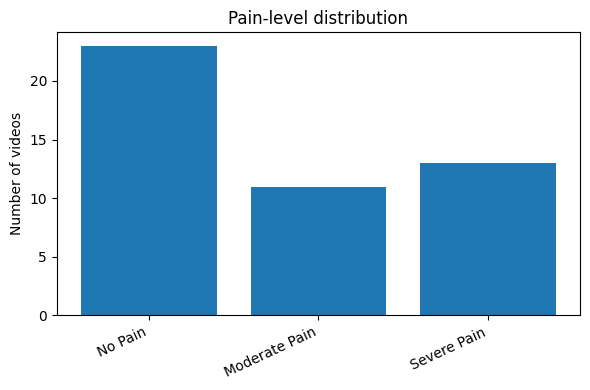

,pain_level,n
0,No Pain,23
1,Moderate Pain,11
2,Severe Pain,13


In [20]:
# Pain-level distribution
plt.figure(figsize=(6, 4))
counts = manifest["pain_level"].value_counts().reindex(pain_order)

plt.bar(counts.index.astype(str), counts.values)
plt.title("Pain-level distribution")
plt.ylabel("Number of videos")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.savefig(fig_dir / "pain_level_distribution.png", dpi=300)
plt.show()

display(counts.rename("n").reset_index().rename(columns={"index": "pain_level"}))

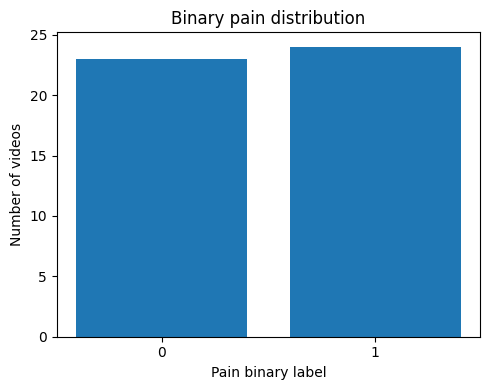

,pain_binary,n
0,0,23
1,1,24


In [21]:
# Binary pain distribution
plt.figure(figsize=(5, 4))
pain_binary_counts = manifest["pain_binary"].value_counts(dropna=False).sort_index()

plt.bar([str(x) for x in pain_binary_counts.index], pain_binary_counts.values)
plt.title("Binary pain distribution")
plt.xlabel("Pain binary label")
plt.ylabel("Number of videos")
plt.tight_layout()
plt.savefig(fig_dir / "pain_binary_distribution.png", dpi=300)
plt.show()

display(pain_binary_counts.rename("n").reset_index().rename(columns={"index": "pain_binary"}))

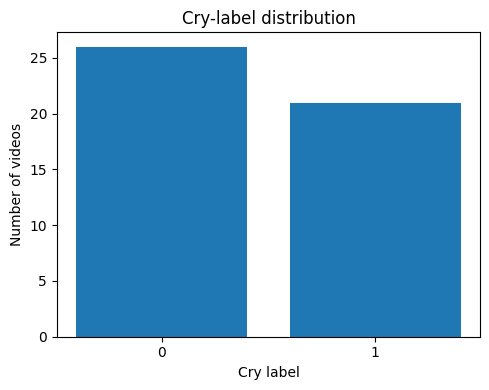

,cry_binary,n
0,0,26
1,1,21


In [22]:
# Cry-label distribution
if manifest["cry_binary"].notna().any():
    plt.figure(figsize=(5, 4))
    cry_counts = manifest["cry_binary"].value_counts(dropna=False).sort_index()

    plt.bar([str(x) for x in cry_counts.index], cry_counts.values)
    plt.title("Cry-label distribution")
    plt.ylabel("Number of videos")
    plt.xlabel("Cry label")
    plt.tight_layout()
    plt.savefig(fig_dir / "cry_distribution.png", dpi=300)
    plt.show()

    display(cry_counts.rename("n").reset_index().rename(columns={"index": "cry_binary"}))

Group/case summary:


,group_id,n_videos,pain_levels,n_pain_classes,any_cry
0,case_1,2,"No Pain, Severe Pain",2,1
1,case_10,2,"Moderate Pain, Severe Pain",2,1
2,case_11,2,"Moderate Pain, No Pain",2,1
3,case_12,2,"Moderate Pain, No Pain",2,0
4,case_13,1,Severe Pain,1,1
5,case_14,2,"Moderate Pain, No Pain",2,1
6,case_15,2,"No Pain, Severe Pain",2,1
7,case_16,2,"Moderate Pain, No Pain",2,0
8,case_17,2,"No Pain, Severe Pain",2,1
9,case_18,2,"No Pain, Severe Pain",2,1


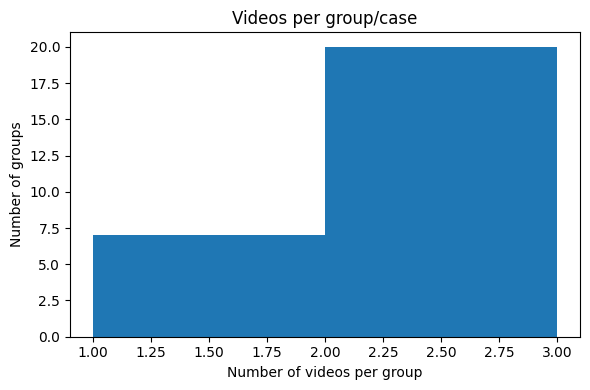

In [23]:
# ============================================================
# STEP 7B: Group/case-level summary
# ============================================================

group_summary = (
    manifest
    .groupby("group_id")
    .agg(
        n_videos=("video_path", "count"),
        pain_levels=("pain_level", lambda x: ", ".join(sorted(set(map(str, x))))),
        n_pain_classes=("pain_code", "nunique"),
        any_cry=("cry_binary", "max"),
    )
    .reset_index()
)

group_summary.to_csv(table_dir / "group_summary.csv", index=False)

print("Group/case summary:")
display(group_summary.head(20))

plt.figure(figsize=(6, 4))
plt.hist(group_summary["n_videos"], bins=range(1, group_summary["n_videos"].max() + 2))
plt.title("Videos per group/case")
plt.xlabel("Number of videos per group")
plt.ylabel("Number of groups")
plt.tight_layout()
plt.savefig(fig_dir / "videos_per_group.png", dpi=300)
plt.show()

Video durations:   0%|          | 0/47 [00:00<?, ?it/s]

count    47.000000
mean     10.337872
std       0.134955
min      10.120000
25%      10.240000
50%      10.320000
75%      10.360000
max      10.920000
Name: duration_s, dtype: float64


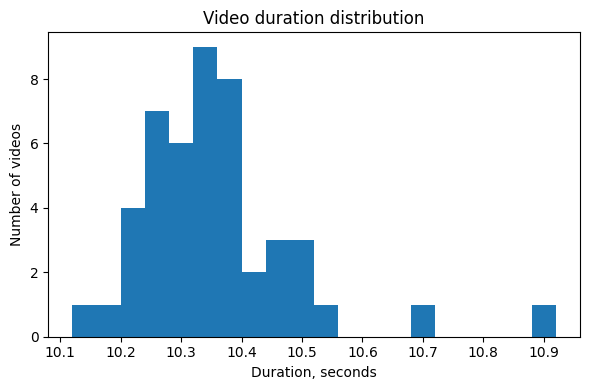

In [24]:
# ============================================================
# STEP 7C: Video duration distribution
# ============================================================

def get_video_duration(path: str) -> float:
    cap = cv2.VideoCapture(path)

    if not cap.isOpened():
        return np.nan

    fps = cap.get(cv2.CAP_PROP_FPS)
    frames = cap.get(cv2.CAP_PROP_FRAME_COUNT)

    cap.release()

    if fps and fps > 0:
        return float(frames / fps)

    return np.nan


dur_path = table_dir / "video_durations.csv"

if dur_path.exists():
    dur_df = pd.read_csv(dur_path)
else:
    rows = []

    for p in tqdm(manifest["video_path"], desc="Video durations"):
        rows.append({
            "video_path": p,
            "duration_s": get_video_duration(p),
        })

    dur_df = pd.DataFrame(rows)
    dur_df.to_csv(dur_path, index=False)

manifest = manifest.drop(columns=["duration_s"], errors="ignore")
manifest = manifest.merge(dur_df, on="video_path", how="left")

print(manifest["duration_s"].describe())

plt.figure(figsize=(6, 4))
plt.hist(manifest["duration_s"].dropna(), bins=20)
plt.title("Video duration distribution")
plt.xlabel("Duration, seconds")
plt.ylabel("Number of videos")
plt.tight_layout()
plt.savefig(fig_dir / "duration_distribution.png", dpi=300)
plt.show()

In [25]:
# ============================================================
# STEP 8: Extract audio features from each video
# ============================================================

def run_cmd(cmd, quiet=True):
    stdout = subprocess.DEVNULL if quiet else None
    stderr = subprocess.DEVNULL if quiet else None
    return subprocess.run(cmd, stdout=stdout, stderr=stderr, check=False)


def extract_wav_from_video(video_path: str, wav_path: Path, sample_rate: int = 16000) -> Path | None:
    wav_path.parent.mkdir(parents=True, exist_ok=True)

    if wav_path.exists() and wav_path.stat().st_size > 0:
        return wav_path

    cmd = [
        "ffmpeg", "-y",
        "-i", video_path,
        "-vn",
        "-ac", "1",
        "-ar", str(sample_rate),
        str(wav_path),
    ]

    res = run_cmd(cmd, quiet=True)

    if res.returncode != 0 or not wav_path.exists() or wav_path.stat().st_size == 0:
        return None

    return wav_path


def safe_stats(x, prefix):
    x = np.asarray(x)

    if x.size == 0:
        return {
            f"{prefix}_mean": np.nan,
            f"{prefix}_std": np.nan,
            f"{prefix}_min": np.nan,
            f"{prefix}_max": np.nan,
            f"{prefix}_median": np.nan,
        }

    return {
        f"{prefix}_mean": float(np.nanmean(x)),
        f"{prefix}_std": float(np.nanstd(x)),
        f"{prefix}_min": float(np.nanmin(x)),
        f"{prefix}_max": float(np.nanmax(x)),
        f"{prefix}_median": float(np.nanmedian(x)),
    }


def extract_audio_features(wav_path: Path, sr: int) -> dict:
    y, sr = librosa.load(wav_path, sr=sr, mono=True)

    if len(y) < sr * 0.25:
        return {
            "audio_valid": 0,
            "audio_duration_s": len(y) / sr,
        }

    feats = {
        "audio_valid": 1,
        "audio_duration_s": len(y) / sr,
    }

    y = librosa.util.normalize(y)

    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=20)

    for i in range(mfcc.shape[0]):
        feats.update(safe_stats(mfcc[i], f"mfcc_{i + 1:02d}"))

    zcr = librosa.feature.zero_crossing_rate(y)[0]
    rms = librosa.feature.rms(y=y)[0]
    centroid = librosa.feature.spectral_centroid(y=y, sr=sr)[0]
    bandwidth = librosa.feature.spectral_bandwidth(y=y, sr=sr)[0]
    rolloff = librosa.feature.spectral_rolloff(y=y, sr=sr)[0]

    for name, arr in [
        ("zcr", zcr),
        ("rms", rms),
        ("centroid", centroid),
        ("bandwidth", bandwidth),
        ("rolloff", rolloff),
    ]:
        feats.update(safe_stats(arr, name))

    try:
        max_bands = 4 if sr <= 16000 else 6
        contrast = librosa.feature.spectral_contrast(y=y, sr=sr, n_bands=max_bands)

        for i in range(contrast.shape[0]):
            feats.update(safe_stats(contrast[i], f"contrast_{i + 1:02d}"))

    except Exception as e:
        feats["spectral_contrast_error"] = str(e)

    try:
        chroma = librosa.feature.chroma_stft(y=y, sr=sr)

        for i in range(chroma.shape[0]):
            feats.update(safe_stats(chroma[i], f"chroma_{i + 1:02d}"))

    except Exception as e:
        feats["chroma_error"] = str(e)

    return feats

In [26]:
# ============================================================
# STEP 8B: Run audio extraction
# ============================================================

audio_feat_path = Path(cfg.artifact_root) / "features" / "audio_features.csv"
wav_dir = Path(cfg.artifact_root) / "audio"
wav_dir.mkdir(parents=True, exist_ok=True)

if audio_feat_path.exists():
    audio_features = pd.read_csv(audio_feat_path)

else:
    rows = []

    for _, r in tqdm(manifest.iterrows(), total=len(manifest), desc="Audio features"):
        wav_path = wav_dir / f"{Path(r['video_name']).stem}.wav"

        wav = extract_wav_from_video(
            r["video_path"],
            wav_path,
            cfg.sample_rate
        )

        if wav is None:
            feats = {
                "audio_valid": 0,
                "audio_duration_s": np.nan,
                "audio_error": "ffmpeg extraction failed",
            }

        else:
            try:
                feats = extract_audio_features(wav, cfg.sample_rate)

            except Exception as e:
                feats = {
                    "audio_valid": 0,
                    "audio_duration_s": np.nan,
                    "audio_error": str(e),
                }

        feats.update({
            "video_path": r["video_path"],
            "video_name": r["video_name"],
            "wav_path": str(wav) if wav is not None else None,
        })

        rows.append(feats)

    audio_features = pd.DataFrame(rows)
    audio_features.to_csv(audio_feat_path, index=False)

print("Audio feature shape:", audio_features.shape)
display(audio_features.head())

print("Audio valid:")
print(audio_features["audio_valid"].value_counts(dropna=False))

Audio features:   0%|          | 0/47 [00:00<?, ?it/s]

Audio feature shape: (47, 215)


,audio_valid,audio_duration_s,mfcc_01_mean,mfcc_01_std,mfcc_01_min,mfcc_01_max,mfcc_01_median,mfcc_02_mean,mfcc_02_std,mfcc_02_min,...,chroma_11_max,chroma_11_median,chroma_12_mean,chroma_12_std,chroma_12_min,chroma_12_max,chroma_12_median,video_path,video_name,wav_path
0,1,10.24,-153.071609,35.038769,-211.589005,22.376324,-163.832748,75.005394,18.501472,3.801746,...,1.0,0.364578,0.437419,0.275751,0.011169,1.0,0.408318,/content/ifpalvd_project/data/ifpalvd_videos/k...,kasus 5_PRE_1.avi,/content/ifpalvd_project/artifacts/audio/kasus...
1,1,10.32,-103.277527,46.736317,-240.101761,11.389532,-92.345512,88.360077,19.796942,-15.337762,...,1.0,0.259815,0.366501,0.329965,0.001347,1.0,0.272664,/content/ifpalvd_project/data/ifpalvd_videos/k...,kasus 1_PRE_1.avi,/content/ifpalvd_project/artifacts/audio/kasus...
2,1,10.40,-103.803970,78.198380,-312.554260,61.598877,-94.163704,-6.548738,71.957733,-125.887558,...,1.0,0.110566,0.220275,0.243741,0.001432,1.0,0.105363,/content/ifpalvd_project/data/ifpalvd_videos/k...,kasus 3_PRE_3.avi,/content/ifpalvd_project/artifacts/audio/kasus...
3,1,10.28,-48.659336,21.073303,-130.703186,54.473709,-53.717602,64.903900,14.259466,-3.401444,...,1.0,0.520019,0.531854,0.210983,0.022091,1.0,0.531732,/content/ifpalvd_project/data/ifpalvd_videos/k...,kasus 21_PRE_1.avi,/content/ifpalvd_project/artifacts/audio/kasus...
4,1,10.32,-138.339569,78.609344,-326.051819,49.902721,-141.264664,46.599922,19.768446,-29.569170,...,1.0,0.263055,0.337617,0.308418,0.001874,1.0,0.265314,/content/ifpalvd_project/data/ifpalvd_videos/k...,kasus 7_POST_2.avi,/content/ifpalvd_project/artifacts/audio/kasus...


Audio valid:
audio_valid
1    47
Name: count, dtype: int64


In [27]:
# ============================================================
# STEP 8C: Audio extraction quality check
# ============================================================

audio_qc = audio_features[[
    "video_name",
    "audio_valid",
    "audio_duration_s",
    "audio_error" if "audio_error" in audio_features.columns else "audio_valid"
]].copy()

display(audio_qc.head(20))

audio_qc_path = Path(cfg.artifact_root) / "tables" / "audio_feature_qc.csv"
audio_qc.to_csv(audio_qc_path, index=False)

print("Audio QC saved to:", audio_qc_path)
print("Audio features saved to:", audio_feat_path)

,video_name,audio_valid,audio_duration_s,audio_valid
0,kasus 5_PRE_1.avi,1,10.24,1
1,kasus 1_PRE_1.avi,1,10.32,1
2,kasus 3_PRE_3.avi,1,10.40,1
3,kasus 21_PRE_1.avi,1,10.28,1
4,kasus 7_POST_2.avi,1,10.32,1
5,kasus 10_PRE_1.avi,1,10.24,1
6,kasus 8_PRE_4.avi,1,10.92,1
7,kasus 2_PRE_1.avi,1,10.36,1
8,kasus 10_POST_2.avi,1,10.44,1
9,kasus 28_POST_2.avi,1,10.28,1


Audio QC saved to: /content/ifpalvd_project/artifacts/tables/audio_feature_qc.csv
Audio features saved to: /content/ifpalvd_project/artifacts/features/audio_features.csv


In [28]:
# ============================================================
# STEP 9A: Extract static image features from sampled frames
# ============================================================

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

weights = models.ResNet18_Weights.IMAGENET1K_V1
resnet = models.resnet18(weights=weights)
image_encoder = nn.Sequential(*list(resnet.children())[:-1]).to(device).eval()

preprocess = weights.transforms()


@torch.no_grad()
def encode_pil_images(images):
    if len(images) == 0:
        return None

    batch = torch.stack([preprocess(img) for img in images]).to(device)
    emb = image_encoder(batch).squeeze(-1).squeeze(-1)

    return emb.detach().cpu().numpy()


def sample_video_frames(video_path: str, n_frames: int = 8) -> list[Image.Image]:
    cap = cv2.VideoCapture(video_path)

    if not cap.isOpened():
        return []

    total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

    if total <= 0:
        cap.release()
        return []

    idxs = np.linspace(0, max(total - 1, 0), n_frames).astype(int)
    frames = []

    for idx in idxs:
        cap.set(cv2.CAP_PROP_POS_FRAMES, int(idx))
        ok, frame = cap.read()

        if not ok or frame is None:
            continue

        frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        frames.append(Image.fromarray(frame))

    cap.release()
    return frames


image_feat_path = Path(cfg.artifact_root) / "features" / "image_static_resnet_features.csv"

if image_feat_path.exists():
    image_features = pd.read_csv(image_feat_path)

else:
    rows = []

    for _, r in tqdm(manifest.iterrows(), total=len(manifest), desc="Static image features"):
        try:
            imgs = sample_video_frames(r["video_path"], cfg.n_frames_per_video)
            emb = encode_pil_images(imgs)

            if emb is None:
                feats = {
                    "image_valid": 0,
                    "n_frames_encoded": 0,
                }

            else:
                mean_emb = emb.mean(axis=0)
                std_emb = emb.std(axis=0)
                center_emb = emb[len(emb) // 2]

                feats = {
                    "image_valid": 1,
                    "n_frames_encoded": emb.shape[0],
                }

                for j, val in enumerate(center_emb):
                    feats[f"resnet_center_{j:04d}"] = float(val)

                for j, val in enumerate(mean_emb):
                    feats[f"resnet_mean_{j:04d}"] = float(val)

                for j, val in enumerate(std_emb):
                    feats[f"resnet_std_{j:04d}"] = float(val)

        except Exception as e:
            feats = {
                "image_valid": 0,
                "n_frames_encoded": 0,
                "image_error": str(e),
            }

        feats.update({
            "video_path": r["video_path"],
            "video_name": r["video_name"],
        })

        rows.append(feats)

    image_features = pd.DataFrame(rows)
    image_features.to_csv(image_feat_path, index=False)

print("Static image feature shape:", image_features.shape)
display(image_features.head())
print("Image valid:", image_features["image_valid"].value_counts(dropna=False).to_dict())

Device: cuda
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 137MB/s]


Static image features:   0%|          | 0/47 [00:00<?, ?it/s]

Static image feature shape: (47, 1540)


,image_valid,n_frames_encoded,resnet_center_0000,resnet_center_0001,resnet_center_0002,resnet_center_0003,resnet_center_0004,resnet_center_0005,resnet_center_0006,resnet_center_0007,...,resnet_std_0504,resnet_std_0505,resnet_std_0506,resnet_std_0507,resnet_std_0508,resnet_std_0509,resnet_std_0510,resnet_std_0511,video_path,video_name
0,1,8,0.000000,0.200147,0.000000,0.599693,0.004007,0.003079,0.000000,0.872903,...,9.313226e-10,2.384186e-07,0.000000e+00,0.000000e+00,7.450581e-09,0.000000e+00,0.000000e+00,0.000000e+00,/content/ifpalvd_project/data/ifpalvd_videos/k...,kasus 5_PRE_1.avi
1,1,8,0.079724,0.000000,0.026499,0.929264,0.000000,0.000000,0.075548,0.000623,...,0.000000e+00,0.000000e+00,0.000000e+00,1.862645e-09,0.000000e+00,0.000000e+00,1.490116e-08,0.000000e+00,/content/ifpalvd_project/data/ifpalvd_videos/k...,kasus 1_PRE_1.avi
2,1,8,1.681808,0.208659,0.057547,2.343121,0.378332,0.000000,0.000000,0.051820,...,7.450581e-09,1.164153e-10,7.450581e-09,7.450581e-09,2.980232e-08,0.000000e+00,5.960464e-08,0.000000e+00,/content/ifpalvd_project/data/ifpalvd_videos/k...,kasus 3_PRE_3.avi
3,1,8,0.632855,0.643178,0.439176,2.052278,0.751285,0.000000,0.060185,0.339373,...,0.000000e+00,0.000000e+00,7.450581e-09,0.000000e+00,7.450581e-09,2.980232e-08,0.000000e+00,7.450581e-09,/content/ifpalvd_project/data/ifpalvd_videos/k...,kasus 21_PRE_1.avi
4,1,8,0.654401,0.993011,2.761685,1.294020,1.088258,0.294115,0.332663,1.601224,...,0.000000e+00,0.000000e+00,1.164153e-10,5.960464e-08,2.980232e-08,0.000000e+00,0.000000e+00,1.490116e-08,/content/ifpalvd_project/data/ifpalvd_videos/k...,kasus 7_POST_2.avi


Image valid: {1: 47}


In [29]:
# ============================================================
# STEP 9B: Extract video-motion features from video stream
# ============================================================

def sample_video_gray_frames(video_path: str, n_frames: int = 16, frame_size: int = 112) -> list[np.ndarray]:
    cap = cv2.VideoCapture(video_path)

    if not cap.isOpened():
        return []

    total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

    if total <= 1:
        cap.release()
        return []

    idxs = np.linspace(0, max(total - 1, 0), n_frames).astype(int)
    frames = []

    for idx in idxs:
        cap.set(cv2.CAP_PROP_POS_FRAMES, int(idx))
        ok, frame = cap.read()

        if not ok or frame is None:
            continue

        frame = cv2.resize(frame, (frame_size, frame_size), interpolation=cv2.INTER_AREA)
        gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
        frames.append(gray)

    cap.release()
    return frames


def extract_video_motion_features(video_path: str, n_frames: int = 16, frame_size: int = 112) -> dict:
    frames = sample_video_gray_frames(
        video_path,
        n_frames=n_frames,
        frame_size=frame_size,
    )

    if len(frames) < 2:
        return {
            "motion_valid": 0,
            "n_motion_frames": len(frames),
        }

    flow_mag_mean, flow_mag_std, flow_mag_p95, flow_mag_max = [], [], [], []
    flow_x_mean, flow_x_std, flow_y_mean, flow_y_std = [], [], [], []
    diff_mean, diff_std, diff_p95, diff_max = [], [], [], []

    for prev, nxt in zip(frames[:-1], frames[1:]):
        prev_f = prev.astype(np.float32) / 255.0
        nxt_f = nxt.astype(np.float32) / 255.0

        flow = cv2.calcOpticalFlowFarneback(
            prev_f,
            nxt_f,
            None,
            pyr_scale=0.5,
            levels=3,
            winsize=15,
            iterations=3,
            poly_n=5,
            poly_sigma=1.2,
            flags=0,
        )

        mag, _ = cv2.cartToPolar(flow[..., 0], flow[..., 1])
        diff = np.abs(nxt_f - prev_f)

        flow_mag_mean.append(float(np.mean(mag)))
        flow_mag_std.append(float(np.std(mag)))
        flow_mag_p95.append(float(np.percentile(mag, 95)))
        flow_mag_max.append(float(np.max(mag)))

        flow_x_mean.append(float(np.mean(flow[..., 0])))
        flow_x_std.append(float(np.std(flow[..., 0])))
        flow_y_mean.append(float(np.mean(flow[..., 1])))
        flow_y_std.append(float(np.std(flow[..., 1])))

        diff_mean.append(float(np.mean(diff)))
        diff_std.append(float(np.std(diff)))
        diff_p95.append(float(np.percentile(diff, 95)))
        diff_max.append(float(np.max(diff)))

    feats = {
        "motion_valid": 1,
        "n_motion_frames": len(frames),
        "n_motion_pairs": len(frames) - 1,
    }

    for prefix, arr in [
        ("video_flow_mag_mean", flow_mag_mean),
        ("video_flow_mag_std", flow_mag_std),
        ("video_flow_mag_p95", flow_mag_p95),
        ("video_flow_mag_max", flow_mag_max),
        ("video_flow_x_mean", flow_x_mean),
        ("video_flow_x_std", flow_x_std),
        ("video_flow_y_mean", flow_y_mean),
        ("video_flow_y_std", flow_y_std),
        ("video_diff_mean", diff_mean),
        ("video_diff_std", diff_std),
        ("video_diff_p95", diff_p95),
        ("video_diff_max", diff_max),
    ]:
        feats.update(safe_stats(np.asarray(arr), prefix))

    feats["video_motion_energy"] = float(np.mean(flow_mag_mean))
    feats["video_motion_peak"] = float(np.max(flow_mag_p95))
    feats["video_frame_change_energy"] = float(np.mean(diff_mean))

    return feats


motion_feat_path = Path(cfg.artifact_root) / "features" / "video_motion_features.csv"

if cfg.run_video_motion_features:
    if motion_feat_path.exists():
        motion_features = pd.read_csv(motion_feat_path)

    else:
        rows = []

        for _, r in tqdm(manifest.iterrows(), total=len(manifest), desc="Video motion features"):
            try:
                feats = extract_video_motion_features(
                    r["video_path"],
                    n_frames=cfg.video_motion_n_frames,
                    frame_size=cfg.video_motion_frame_size,
                )

            except Exception as e:
                feats = {
                    "motion_valid": 0,
                    "motion_error": str(e),
                }

            feats.update({
                "video_path": r["video_path"],
                "video_name": r["video_name"],
            })

            rows.append(feats)

        motion_features = pd.DataFrame(rows)
        motion_features.to_csv(motion_feat_path, index=False)

else:
    motion_features = pd.DataFrame(columns=["video_path", "video_name", "motion_valid"])
    print("Skipping video-motion extraction because cfg.run_video_motion_features is False.")

print("Video-motion feature shape:", motion_features.shape)
display(motion_features.head())

if "motion_valid" in motion_features.columns:
    print("Motion valid:", motion_features["motion_valid"].value_counts(dropna=False).to_dict())

Video motion features:   0%|          | 0/47 [00:00<?, ?it/s]

Video-motion feature shape: (47, 68)


,motion_valid,n_motion_frames,n_motion_pairs,video_flow_mag_mean_mean,video_flow_mag_mean_std,video_flow_mag_mean_min,video_flow_mag_mean_max,video_flow_mag_mean_median,video_flow_mag_std_mean,video_flow_mag_std_std,...,video_diff_max_mean,video_diff_max_std,video_diff_max_min,video_diff_max_max,video_diff_max_median,video_motion_energy,video_motion_peak,video_frame_change_energy,video_path,video_name
0,1,16,15,2.716489e-12,0.0,2.716489e-12,2.716489e-12,2.716489e-12,1.771759e-11,0.0,...,0.0,0.0,0.0,0.0,0.0,2.716489e-12,1.709705e-12,0.0,/content/ifpalvd_project/data/ifpalvd_videos/k...,kasus 5_PRE_1.avi
1,1,16,15,2.716489e-12,0.0,2.716489e-12,2.716489e-12,2.716489e-12,1.771759e-11,0.0,...,0.0,0.0,0.0,0.0,0.0,2.716489e-12,1.709705e-12,0.0,/content/ifpalvd_project/data/ifpalvd_videos/k...,kasus 1_PRE_1.avi
2,1,16,15,2.716489e-12,0.0,2.716489e-12,2.716489e-12,2.716489e-12,1.771759e-11,0.0,...,0.0,0.0,0.0,0.0,0.0,2.716489e-12,1.709705e-12,0.0,/content/ifpalvd_project/data/ifpalvd_videos/k...,kasus 3_PRE_3.avi
3,1,16,15,2.716489e-12,0.0,2.716489e-12,2.716489e-12,2.716489e-12,1.771759e-11,0.0,...,0.0,0.0,0.0,0.0,0.0,2.716489e-12,1.709705e-12,0.0,/content/ifpalvd_project/data/ifpalvd_videos/k...,kasus 21_PRE_1.avi
4,1,16,15,2.716489e-12,0.0,2.716489e-12,2.716489e-12,2.716489e-12,1.771759e-11,0.0,...,0.0,0.0,0.0,0.0,0.0,2.716489e-12,1.709705e-12,0.0,/content/ifpalvd_project/data/ifpalvd_videos/k...,kasus 7_POST_2.avi


Motion valid: {1: 47}


In [30]:
# ============================================================
# STEP 9C: Cache ordered frame-sequence embeddings
# ============================================================

seq_dir = Path(cfg.artifact_root) / "features" / "image_sequences"
seq_dir.mkdir(parents=True, exist_ok=True)

seq_index_path = Path(cfg.artifact_root) / "features" / "image_sequence_index.csv"

if cfg.run_temporal_model or cfg.run_explainability:
    if seq_index_path.exists():
        image_seq_index = pd.read_csv(seq_index_path)

    else:
        rows = []

        for _, r in tqdm(manifest.iterrows(), total=len(manifest), desc="Image sequence cache"):
            seq_path = seq_dir / f"{Path(r['video_name']).stem}_seq.npy"

            if seq_path.exists():
                arr = np.load(seq_path)

            else:
                imgs = sample_video_frames(r["video_path"], cfg.temporal_n_frames)
                emb = encode_pil_images(imgs)

                if emb is None:
                    arr = np.empty((0, 512), dtype=np.float32)
                else:
                    arr = emb.astype(np.float32)

                np.save(seq_path, arr)

            rows.append({
                "video_path": r["video_path"],
                "video_name": r["video_name"],
                "seq_path": str(seq_path),
                "n_seq_frames": int(arr.shape[0]) if arr.ndim == 2 else 0,
                "seq_valid": int(arr.ndim == 2 and arr.shape[0] > 0),
            })

        image_seq_index = pd.DataFrame(rows)
        image_seq_index.to_csv(seq_index_path, index=False)

    print("Sequence index shape:", image_seq_index.shape)
    display(image_seq_index.head())
    print("Sequence valid counts:", image_seq_index["seq_valid"].value_counts(dropna=False).to_dict())

else:
    image_seq_index = pd.DataFrame(
        columns=["video_path", "video_name", "seq_path", "n_seq_frames", "seq_valid"]
    )
    print("Skipping sequence cache because both cfg.run_temporal_model and cfg.run_explainability are False.")

Image sequence cache:   0%|          | 0/47 [00:00<?, ?it/s]

Sequence index shape: (47, 5)


,video_path,video_name,seq_path,n_seq_frames,seq_valid
0,/content/ifpalvd_project/data/ifpalvd_videos/k...,kasus 5_PRE_1.avi,/content/ifpalvd_project/artifacts/features/im...,8,1
1,/content/ifpalvd_project/data/ifpalvd_videos/k...,kasus 1_PRE_1.avi,/content/ifpalvd_project/artifacts/features/im...,8,1
2,/content/ifpalvd_project/data/ifpalvd_videos/k...,kasus 3_PRE_3.avi,/content/ifpalvd_project/artifacts/features/im...,8,1
3,/content/ifpalvd_project/data/ifpalvd_videos/k...,kasus 21_PRE_1.avi,/content/ifpalvd_project/artifacts/features/im...,8,1
4,/content/ifpalvd_project/data/ifpalvd_videos/k...,kasus 7_POST_2.avi,/content/ifpalvd_project/artifacts/features/im...,8,1


Sequence valid counts: {1: 47}


In [31]:
# ============================================================
# STEP 9D: Image/video feature QC summary
# ============================================================

qc_rows = []

qc_rows.append({
    "feature_set": "static_image_resnet",
    "n_rows": len(image_features),
    "valid_col": "image_valid",
    "n_valid": int(image_features["image_valid"].sum()) if "image_valid" in image_features.columns else np.nan,
})

if "motion_valid" in motion_features.columns:
    qc_rows.append({
        "feature_set": "video_motion_optical_flow",
        "n_rows": len(motion_features),
        "valid_col": "motion_valid",
        "n_valid": int(motion_features["motion_valid"].sum()),
    })

if "seq_valid" in image_seq_index.columns:
    qc_rows.append({
        "feature_set": "ordered_frame_sequence",
        "n_rows": len(image_seq_index),
        "valid_col": "seq_valid",
        "n_valid": int(image_seq_index["seq_valid"].sum()),
    })

feature_qc = pd.DataFrame(qc_rows)

feature_qc_path = Path(cfg.artifact_root) / "tables" / "image_video_feature_qc.csv"
feature_qc.to_csv(feature_qc_path, index=False)

display(feature_qc)
print("Feature QC saved to:", feature_qc_path)

manifest_path = Path(cfg.artifact_root) / "tables" / "manifest_ifpalvd.csv"
manifest.to_csv(manifest_path, index=False)
print("Manifest saved to:", manifest_path)

,feature_set,n_rows,valid_col,n_valid
0,static_image_resnet,47,image_valid,47
1,video_motion_optical_flow,47,motion_valid,47
2,ordered_frame_sequence,47,seq_valid,47


Feature QC saved to: /content/ifpalvd_project/artifacts/tables/image_video_feature_qc.csv
Manifest saved to: /content/ifpalvd_project/artifacts/tables/manifest_ifpalvd.csv


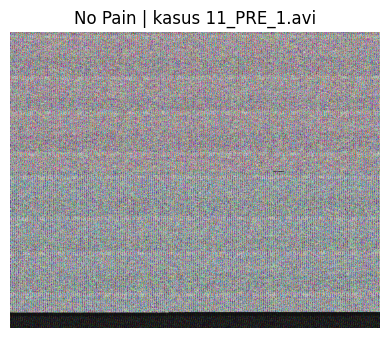

Saved: /content/ifpalvd_project/artifacts/figures/example_frame_No_Pain.png


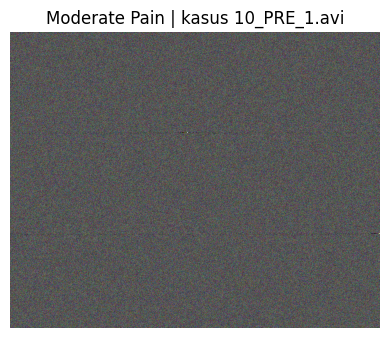

Saved: /content/ifpalvd_project/artifacts/figures/example_frame_Moderate_Pain.png


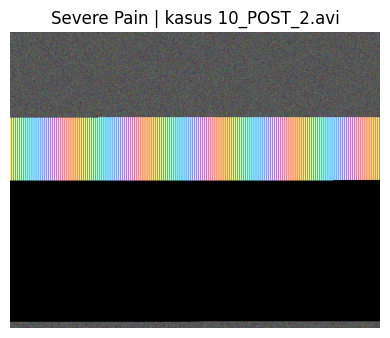

Saved: /content/ifpalvd_project/artifacts/figures/example_frame_Severe_Pain.png


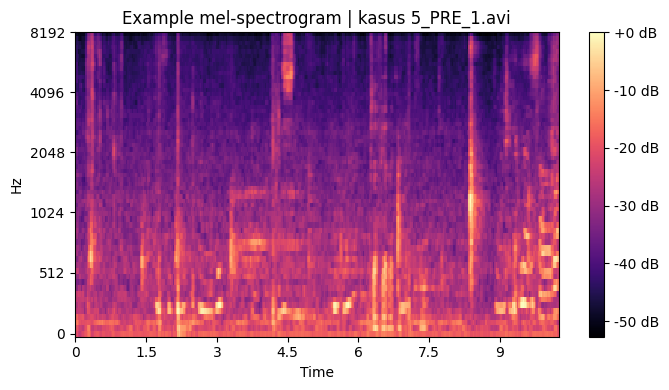

Saved: /content/ifpalvd_project/artifacts/figures/example_mel_spectrogram.png


In [32]:
# ============================================================
# STEP 10A: Representative examples: frame and spectrogram
# ============================================================

fig_dir = Path(cfg.artifact_root) / "figures"
fig_dir.mkdir(parents=True, exist_ok=True)

# One representative frame from each pain class
example_rows = (
    manifest
    .sort_values(["pain_code", "video_name"])
    .groupby("pain_level", group_keys=False)
    .head(1)
)

for _, r in example_rows.iterrows():
    frames = sample_video_frames(r["video_path"], 1)

    if not frames:
        continue

    plt.figure(figsize=(4, 4))
    plt.imshow(frames[0])
    plt.axis("off")
    plt.title(f"{r['pain_level']} | {r['video_name']}")
    plt.tight_layout()

    safe_label = re.sub(r"[^A-Za-z0-9]+", "_", str(r["pain_level"]))
    out = fig_dir / f"example_frame_{safe_label}.png"

    plt.savefig(out, dpi=300)
    plt.show()

    print("Saved:", out)


# Example mel-spectrogram from first valid audio clip
valid_audio_rows = audio_features[audio_features["audio_valid"] == 1].copy()

if len(valid_audio_rows):
    row = valid_audio_rows.iloc[0]

    if "wav_path" in row and pd.notna(row["wav_path"]):
        wav_path = Path(row["wav_path"])
    else:
        wav_path = Path(cfg.artifact_root) / "audio" / f"{Path(row['video_name']).stem}.wav"

    if wav_path.exists():
        y, sr = librosa.load(wav_path, sr=cfg.sample_rate)

        S = librosa.feature.melspectrogram(
            y=y,
            sr=sr,
            n_mels=64
        )

        S_db = librosa.power_to_db(S, ref=np.max)

        plt.figure(figsize=(7, 4))
        librosa.display.specshow(
            S_db,
            sr=sr,
            x_axis="time",
            y_axis="mel"
        )
        plt.colorbar(format="%+2.0f dB")
        plt.title(f"Example mel-spectrogram | {row['video_name']}")
        plt.tight_layout()

        out = fig_dir / "example_mel_spectrogram.png"
        plt.savefig(out, dpi=300)
        plt.show()

        print("Saved:", out)

    else:
        print("No WAV file found for spectrogram:", wav_path)

else:
    print("No valid audio rows available for spectrogram.")

In [33]:
# ============================================================
# STEP 10B: Representative media preview: frames and short clips
# ============================================================

preview_dir = Path(cfg.artifact_root) / "previews"
preview_dir.mkdir(parents=True, exist_ok=True)

if "pain_level" in manifest.columns and manifest["pain_level"].notna().any():
    per_class = max(
        1,
        math.ceil(cfg.preview_n_examples / max(1, manifest["pain_level"].nunique()))
    )

    example_rows = (
        manifest
        .sort_values(["pain_code", "video_name"])
        .groupby("pain_level", group_keys=False)
        .head(per_class)
        .head(cfg.preview_n_examples)
        .copy()
    )

else:
    example_rows = manifest.head(cfg.preview_n_examples).copy()

display_cols = [
    c for c in ["video_name", "pain_level", "group_id", "video_path"]
    if c in example_rows.columns
]

display(example_rows[display_cols])

,video_name,pain_level,group_id,video_path
11,kasus 11_PRE_1.avi,No Pain,case_11,/content/ifpalvd_project/data/ifpalvd_videos/k...
39,kasus 12_PRE_1.avi,No Pain,case_12,/content/ifpalvd_project/data/ifpalvd_videos/k...
5,kasus 10_PRE_1.avi,Moderate Pain,case_10,/content/ifpalvd_project/data/ifpalvd_videos/k...
26,kasus 11_POST_3.avi,Moderate Pain,case_11,/content/ifpalvd_project/data/ifpalvd_videos/k...


In [34]:
def make_preview_clip(video_path: str, out_path: Path, seconds: int = 3) -> Path | None:
    out_path.parent.mkdir(parents=True, exist_ok=True)

    if out_path.exists() and out_path.stat().st_size > 0:
        return out_path

    cmd = [
        "ffmpeg",
        "-y",
        "-i", str(video_path),
        "-t", str(seconds),
        "-vf", "scale='min(640,iw)':-2",
        "-c:v", "libx264",
        "-preset", "veryfast",
        "-an",
        str(out_path),
    ]

    res = run_cmd(cmd, quiet=True)

    if res.returncode == 0 and out_path.exists() and out_path.stat().st_size > 0:
        return out_path

    return None

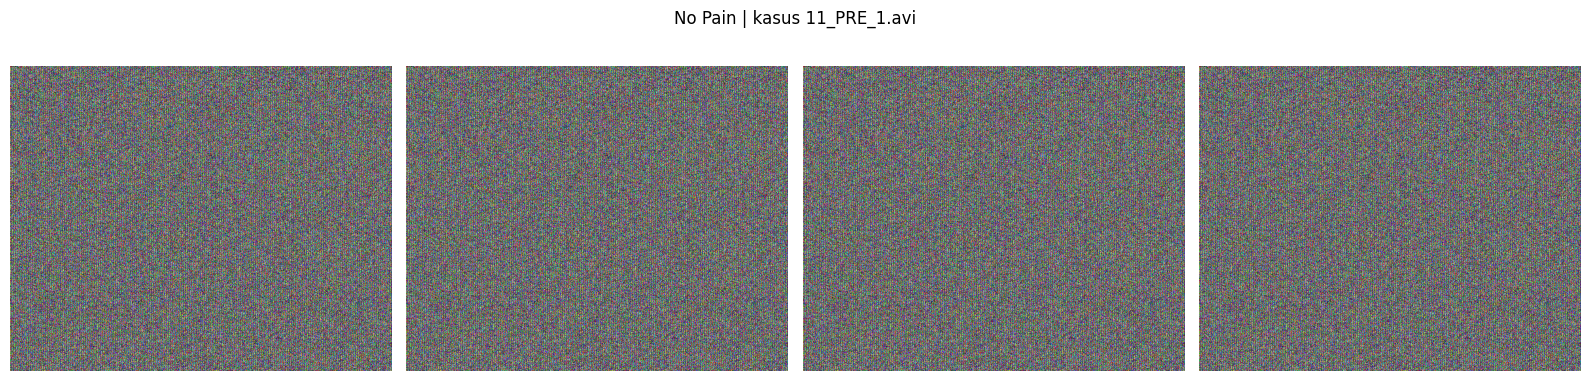

Preview clip: No Pain | kasus 11_PRE_1.avi


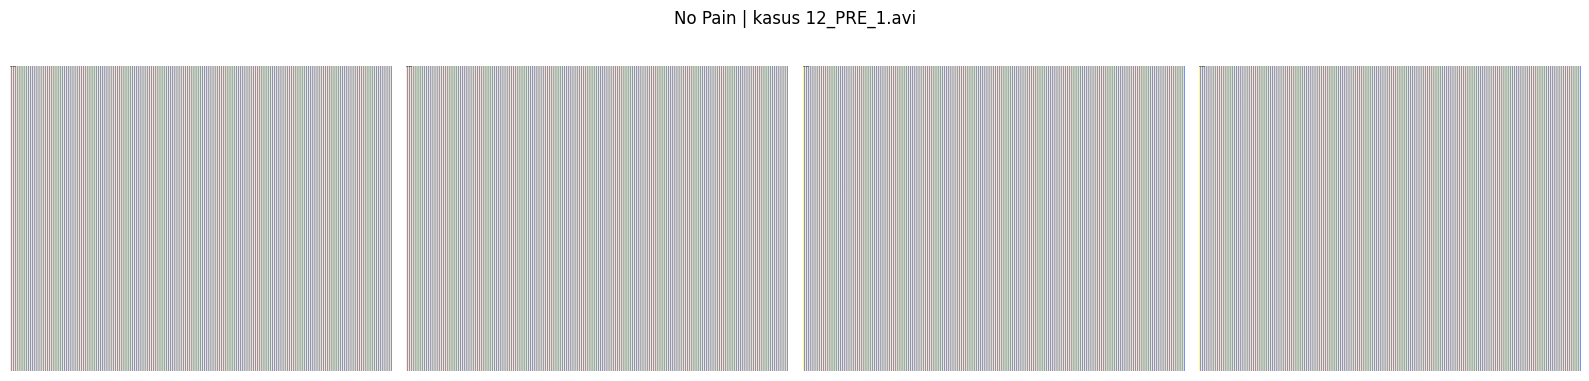

Preview clip: No Pain | kasus 12_PRE_1.avi


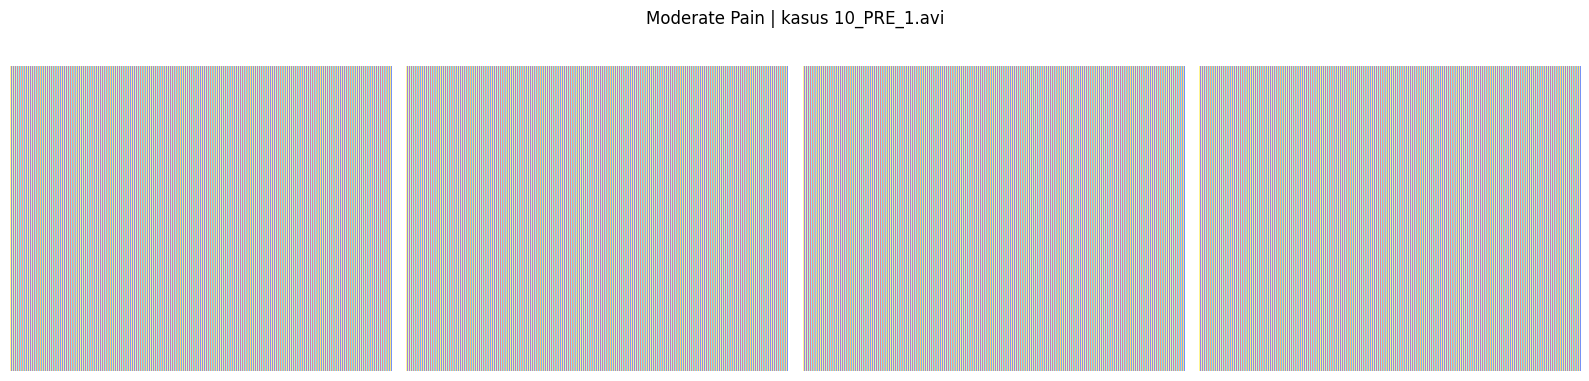

Preview clip: Moderate Pain | kasus 10_PRE_1.avi


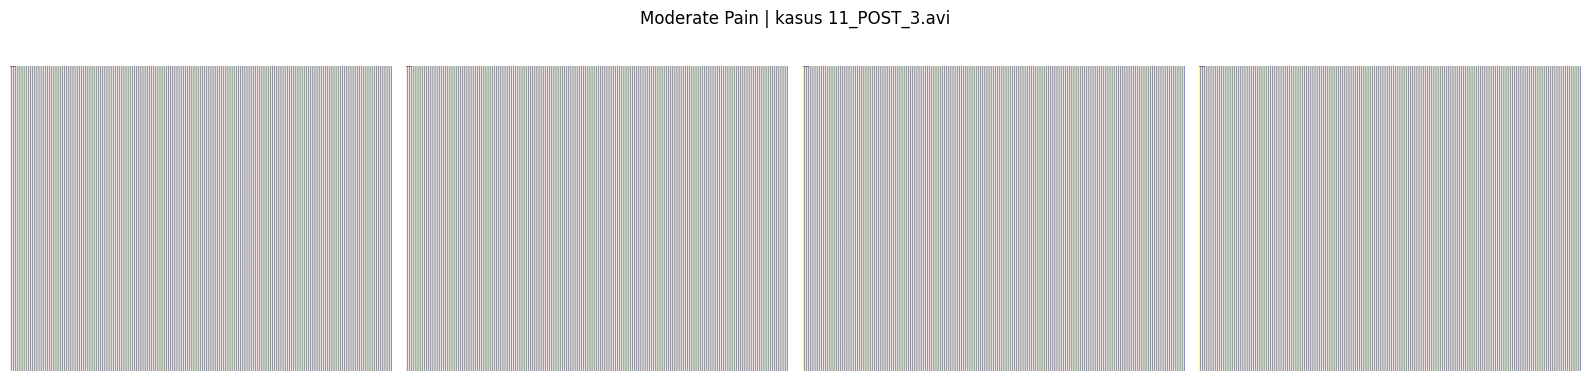

Preview clip: Moderate Pain | kasus 11_POST_3.avi


In [35]:
for _, r in example_rows.iterrows():
    frames = sample_video_frames(
        r["video_path"],
        cfg.preview_frames_per_video
    )

    if len(frames):
        fig, axes = plt.subplots(
            1,
            len(frames),
            figsize=(4 * len(frames), 4)
        )

        if len(frames) == 1:
            axes = [axes]

        for ax, img in zip(axes, frames):
            ax.imshow(img)
            ax.axis("off")

        title = f"{r.get('pain_level', 'Unknown')} | {r.get('video_name', 'clip')}"
        fig.suptitle(title, fontsize=12)

        plt.tight_layout()
        plt.show()

    clip_path = preview_dir / f"{Path(r['video_name']).stem}_{cfg.preview_seconds}s.mp4"

    clip = make_preview_clip(
        r["video_path"],
        clip_path,
        cfg.preview_seconds
    )

    if clip is not None:
        print(f"Preview clip: {r.get('pain_level', 'Unknown')} | {r.get('video_name', 'clip')}")
        display(Video(str(clip), embed=True, html_attributes="controls muted"))

    else:
        print("Could not create preview clip for:", r.get("video_name", "unknown"))

In [36]:
# ============================================================
# STEP 11: Merge features and define feature sets
# ============================================================

def prepare_feature_table(feat_df: pd.DataFrame, name: str, valid_col: str):
    if feat_df is None or len(feat_df) == 0:
        out = pd.DataFrame(columns=["video_path", "video_name", valid_col])
        out[valid_col] = pd.Series(dtype=int)
        return out

    out = feat_df.copy()

    if "video_path" not in out.columns:
        out["video_path"] = np.nan

    if "video_name" not in out.columns:
        out["video_name"] = out["video_path"].map(
            lambda x: Path(str(x)).name if pd.notna(x) else np.nan
        )

    if valid_col not in out.columns:
        out[valid_col] = 0

    out[valid_col] = out[valid_col].fillna(0).astype(int)

    out = out.drop_duplicates(subset=["video_path", "video_name"])

    out.to_csv(
        Path(cfg.artifact_root) / "tables" / f"{name}_prepared.csv",
        index=False
    )

    return out


audio_features = prepare_feature_table(
    audio_features,
    "audio_features",
    "audio_valid"
)

image_features = prepare_feature_table(
    image_features,
    "image_static_features",
    "image_valid"
)

if "motion_features" not in globals():
    motion_features = pd.DataFrame(columns=["video_path", "video_name", "motion_valid"])

motion_features = prepare_feature_table(
    motion_features,
    "video_motion_features",
    "motion_valid"
)

In [37]:
# Merge features
df = manifest.merge(
    audio_features,
    on=["video_path", "video_name"],
    how="left"
)

df = df.merge(
    image_features,
    on=["video_path", "video_name"],
    how="left",
    suffixes=("", "_imagedup")
)

df = df.merge(
    motion_features,
    on=["video_path", "video_name"],
    how="left",
    suffixes=("", "_motiondup")
)

# Merge sequence-cache metadata
if "image_seq_index" in globals() and len(image_seq_index):
    seq_meta = (
        image_seq_index[["video_path", "video_name", "seq_path", "n_seq_frames", "seq_valid"]]
        .drop_duplicates(subset=["video_path", "video_name"])
    )

    df = df.merge(
        seq_meta,
        on=["video_path", "video_name"],
        how="left"
    )

else:
    df["seq_path"] = np.nan
    df["n_seq_frames"] = 0
    df["seq_valid"] = 0

In [38]:
# Resolve validity columns
for col in ["audio_valid", "image_valid", "motion_valid", "seq_valid"]:
    if col not in df.columns:
        df[col] = 0

    df[col] = df[col].fillna(0).astype(int)

df["video_sequence_valid"] = df["seq_valid"].fillna(0).astype(int)

In [39]:
# ============================================================
# Define feature columns
# ============================================================

audio_cols = [
    c for c in df.columns
    if c.startswith((
        "mfcc_",
        "zcr_",
        "rms_",
        "centroid_",
        "bandwidth_",
        "rolloff_",
        "contrast_",
        "chroma_",
        "audio_duration_s",
    ))
]

image_cols = [
    c for c in df.columns
    if c.startswith((
        "resnet_center_",
        "resnet_mean_",
        "resnet_std_",
    ))
]

video_motion_cols = [
    c for c in df.columns
    if c.startswith((
        "video_flow_",
        "video_diff_",
        "video_motion_",
        "video_frame_change_",
        "n_motion_pairs",
    ))
]

# Backward-compatible aliases
vision_cols = image_cols
video_engineered_cols = image_cols + video_motion_cols if len(video_motion_cols) else []
video_cols = video_engineered_cols

print("Audio feature count:", len(audio_cols))
print("Image/static feature count:", len(image_cols))
print("Video-motion feature count:", len(video_motion_cols))
print("Rows:", len(df))

Audio feature count: 211
Image/static feature count: 1536
Video-motion feature count: 64
Rows: 47


In [40]:
# ============================================================
# Define modality availability flags
# ============================================================

df["audio_valid"] = df["audio_valid"].fillna(0).astype(int)
df["image_valid"] = df["image_valid"].fillna(0).astype(int)
df["motion_valid"] = df["motion_valid"].fillna(0).astype(int)
df["video_sequence_valid"] = df["video_sequence_valid"].fillna(0).astype(int)

df["image_audio_valid"] = (
    (df["audio_valid"] == 1) &
    (df["image_valid"] == 1)
).astype(int)

df["both_valid"] = df["image_audio_valid"]

if len(video_motion_cols):
    df["video_feature_valid"] = (
        (df["image_valid"] == 1) &
        (df["motion_valid"] == 1)
    ).astype(int)
else:
    df["video_feature_valid"] = 0

df["video_valid"] = (
    (df["video_feature_valid"] == 1) |
    (df["video_sequence_valid"] == 1)
).astype(int)

df["video_audio_valid"] = (
    (df["audio_valid"] == 1) &
    (df["video_valid"] == 1)
).astype(int)

df["video_feature_audio_valid"] = (
    (df["audio_valid"] == 1) &
    (df["video_feature_valid"] == 1)
).astype(int)

df["video_sequence_audio_valid"] = (
    (df["audio_valid"] == 1) &
    (df["video_sequence_valid"] == 1)
).astype(int)

In [41]:
# ============================================================
# Modality availability table
# ============================================================

availability = pd.DataFrame({
    "comparison_arm": [
        "Audio",
        "Image",
        "Image+Audio",
        "Video motion",
        "Video temporal",
        "Video+Audio",
    ],
    "validity_column": [
        "audio_valid",
        "image_valid",
        "image_audio_valid",
        "video_feature_valid",
        "video_sequence_valid",
        "video_audio_valid",
    ],
    "n_rows": [
        int((df["audio_valid"] == 1).sum()),
        int((df["image_valid"] == 1).sum()),
        int((df["image_audio_valid"] == 1).sum()),
        int((df["video_feature_valid"] == 1).sum()),
        int((df["video_sequence_valid"] == 1).sum()),
        int((df["video_audio_valid"] == 1).sum()),
    ],
    "n_features": [
        len(audio_cols),
        len(image_cols),
        len(audio_cols) + len(image_cols),
        len(video_engineered_cols),
        cfg.temporal_n_frames * 512,
        len(audio_cols) + len(video_engineered_cols),
    ],
})

display(availability)

availability_path = Path(cfg.artifact_root) / "tables" / "modality_availability.csv"
availability.to_csv(availability_path, index=False)

print("Availability table saved to:", availability_path)

,comparison_arm,validity_column,n_rows,n_features
0,Audio,audio_valid,47,211
1,Image,image_valid,47,1536
2,Image+Audio,image_audio_valid,47,1747
3,Video motion,video_feature_valid,47,1600
4,Video temporal,video_sequence_valid,47,4096
5,Video+Audio,video_audio_valid,47,1811


Availability table saved to: /content/ifpalvd_project/artifacts/tables/modality_availability.csv


In [42]:
# Save merged analytic table
analytic_path = Path(cfg.artifact_root) / "tables" / "analytic_dataset.csv"
df.to_csv(analytic_path, index=False)

print("Analytic dataset saved to:", analytic_path)
print("Analytic dataset shape:", df.shape)

Analytic dataset saved to: /content/ifpalvd_project/artifacts/tables/analytic_dataset.csv
Analytic dataset shape: (47, 1841)


In [43]:
# ============================================================
# STEP 12: Leakage-aware cross-validation helpers
# ============================================================

def make_cv_indices(
    data: pd.DataFrame,
    y_col: str = "pain_code",
    group_col: str = "group_id",
    n_splits: int = 5,
):
    y = data[y_col].astype(int).to_numpy()

    class_counts = Counter(y)
    min_class = min(class_counts.values())

    n_splits_eff = min(n_splits, min_class)
    n_splits_eff = max(2, n_splits_eff)

    use_grouped = False
    groups = None

    if cfg.use_grouped_cv and group_col in data.columns:
        g = data[group_col].copy()

        if g.notna().any():
            fallback = data["video_name"] if "video_name" in data.columns else pd.Series(range(len(data)))
            g = g.fillna(fallback).astype(str)

            if g.nunique() >= n_splits_eff:
                groups = g.to_numpy()
                use_grouped = True

    if use_grouped:
        splitter = StratifiedGroupKFold(
            n_splits=n_splits_eff,
            shuffle=True,
            random_state=RANDOM_STATE,
        )

        splits = list(splitter.split(data, y, groups))
        split_name = "StratifiedGroupKFold"

    else:
        splitter = StratifiedKFold(
            n_splits=n_splits_eff,
            shuffle=True,
            random_state=RANDOM_STATE,
        )

        splits = list(splitter.split(data, y))
        split_name = "StratifiedKFold"

    return splits, split_name, n_splits_eff

In [44]:
def multiclass_metrics(y_true, y_pred, proba=None, class_order=(0, 1, 2)):
    y_true = np.asarray(y_true).astype(int)
    y_pred = np.asarray(y_pred).astype(int)

    out = {
        "accuracy": accuracy_score(y_true, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
        "macro_f1": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "weighted_f1": f1_score(y_true, y_pred, average="weighted", zero_division=0),
        "ordinal_mae": float(np.mean(np.abs(y_true - y_pred))),
        "qwk": cohen_kappa_score(y_true, y_pred, weights="quadratic"),
    }

    if proba is not None:
        try:
            y_bin = label_binarize(y_true, classes=list(class_order))

            if proba.shape[1] == len(class_order):
                out["macro_auroc_ovr"] = roc_auc_score(
                    y_bin,
                    proba,
                    average="macro",
                    multi_class="ovr",
                )

                out["macro_auprc_ovr"] = average_precision_score(
                    y_bin,
                    proba,
                    average="macro",
                )
            else:
                out["macro_auroc_ovr"] = np.nan
                out["macro_auprc_ovr"] = np.nan

        except Exception:
            out["macro_auroc_ovr"] = np.nan
            out["macro_auprc_ovr"] = np.nan

    return out

In [45]:
def binary_metrics(y_true, y_prob, threshold=0.5):
    y_true = np.asarray(y_true).astype(int)
    y_prob = np.asarray(y_prob).astype(float)

    y_pred = (y_prob >= threshold).astype(int)

    out = {
        "binary_accuracy": accuracy_score(y_true, y_pred),
        "binary_balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
        "binary_f1": f1_score(y_true, y_pred, zero_division=0),
        "binary_brier": brier_score_loss(y_true, y_prob),
    }

    try:
        out["binary_auroc"] = roc_auc_score(y_true, y_prob)
        out["binary_auprc"] = average_precision_score(y_true, y_prob)
    except Exception:
        out["binary_auroc"] = np.nan
        out["binary_auprc"] = np.nan

    return out

In [46]:
def expected_calibration_error(y_true, y_prob, n_bins=10):
    y_true = np.asarray(y_true).astype(int)
    y_prob = np.asarray(y_prob).astype(float)

    bins = np.linspace(0, 1, n_bins + 1)
    ece = 0.0

    for i in range(n_bins):
        lo = bins[i]
        hi = bins[i + 1]

        if i < n_bins - 1:
            mask = (y_prob >= lo) & (y_prob < hi)
        else:
            mask = (y_prob >= lo) & (y_prob <= hi)

        if mask.sum() == 0:
            continue

        acc = y_true[mask].mean()
        conf = y_prob[mask].mean()

        ece += (mask.sum() / len(y_true)) * abs(acc - conf)

    return float(ece)

In [47]:
# ============================================================
# STEP 12B: Check leakage-aware CV folds
# ============================================================

splits, split_name, n_splits_eff = make_cv_indices(
    df,
    y_col="pain_code",
    group_col="group_id",
    n_splits=cfg.n_splits,
)

print("CV splitter:", split_name)
print("Effective number of folds:", n_splits_eff)

fold_rows = []

for fold, (tr_idx, te_idx) in enumerate(splits, start=1):
    train_groups = set(df.iloc[tr_idx]["group_id"].astype(str))
    test_groups = set(df.iloc[te_idx]["group_id"].astype(str))
    overlap = train_groups.intersection(test_groups)

    fold_rows.append({
        "fold": fold,
        "n_train": len(tr_idx),
        "n_test": len(te_idx),
        "n_train_groups": len(train_groups),
        "n_test_groups": len(test_groups),
        "group_overlap": len(overlap),
        "train_class_counts": dict(Counter(df.iloc[tr_idx]["pain_code"].astype(int))),
        "test_class_counts": dict(Counter(df.iloc[te_idx]["pain_code"].astype(int))),
    })

fold_check_df = pd.DataFrame(fold_rows)

display(fold_check_df)

fold_check_path = Path(cfg.artifact_root) / "tables" / "cv_fold_check.csv"
fold_check_df.to_csv(fold_check_path, index=False)

print("CV fold check saved to:", fold_check_path)

CV splitter: StratifiedGroupKFold
Effective number of folds: 5


,fold,n_train,n_test,n_train_groups,n_test_groups,group_overlap,train_class_counts,test_class_counts
0,1,39,8,22,5,0,"{0: 20, 2: 11, 1: 8}","{0: 3, 1: 3, 2: 2}"
1,2,35,12,21,6,0,"{0: 16, 2: 13, 1: 6}","{1: 5, 0: 7}"
2,3,39,8,22,5,0,"{0: 20, 2: 10, 1: 9}","{0: 3, 2: 3, 1: 2}"
3,4,37,10,21,6,0,"{0: 18, 1: 11, 2: 8}","{2: 5, 0: 5}"
4,5,38,9,22,5,0,"{2: 10, 0: 18, 1: 10}","{0: 5, 2: 3, 1: 1}"


CV fold check saved to: /content/ifpalvd_project/artifacts/tables/cv_fold_check.csv


In [48]:
# ============================================================
# STEP 13: Train and compare baseline models
# ============================================================

def make_classifier(model_name="logistic"):
    if model_name == "logistic":
        return Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
            ("clf", LogisticRegression(
                max_iter=5000,
                class_weight="balanced",
                solver="lbfgs",
                random_state=RANDOM_STATE,
            )),
        ])

    if model_name == "rf":
        return Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("clf", RandomForestClassifier(
                n_estimators=500,
                class_weight="balanced_subsample",
                random_state=RANDOM_STATE,
                n_jobs=-1,
                max_depth=None,
            )),
        ])

    raise ValueError(model_name)


def predict_proba_3class(model, X, n_classes: int = 3):
    proba = model.predict_proba(X)

    if proba.shape[1] == n_classes:
        return proba

    classes = model.named_steps["clf"].classes_

    aligned = np.zeros((proba.shape[0], n_classes), dtype=float)

    for j, cls in enumerate(classes):
        cls_int = int(cls)
        if 0 <= cls_int < n_classes:
            aligned[:, cls_int] = proba[:, j]

    aligned = aligned / np.clip(aligned.sum(axis=1, keepdims=True), 1e-8, None)

    return aligned

In [49]:
# ============================================================
# SAFETY CELL: Ensure results_df and preds_df exist
# ============================================================

results_path = Path(cfg.artifact_root) / "tables" / "model_comparison.csv"
preds_path = Path(cfg.artifact_root) / "tables" / "oof_predictions.csv"

if "results_df" not in globals():
    if results_path.exists():
        results_df = pd.read_csv(results_path)
        print("Loaded existing results_df:", results_df.shape)
    else:
        results_df = pd.DataFrame()
        print("Created empty results_df.")

if "preds_df" not in globals():
    if preds_path.exists():
        preds_df = pd.read_csv(preds_path)
        print("Loaded existing preds_df:", preds_df.shape)
    else:
        preds_df = pd.DataFrame()
        print("Created empty preds_df.")

Created empty results_df.
Created empty preds_df.


In [50]:
# ============================================================
# STEP 14: Late fusion for image+audio and video+audio
# ============================================================

def run_two_stream_late_fusion(
    data,
    left_cols,
    right_cols,
    valid_mask,
    feature_set_name,
    left_name="left",
    right_name="right",
):
    valid = (
        data[valid_mask]
        .dropna(subset=["pain_code"])
        .copy()
        .reset_index(drop=True)
    )

    if len(valid) < 6 or valid["pain_code"].nunique() < 2:
        print(f"Skipping {feature_set_name}: insufficient rows/classes.")
        return pd.DataFrame(), pd.DataFrame()

    if not left_cols or not right_cols:
        print(f"Skipping {feature_set_name}: missing {left_name} or {right_name} columns.")
        return pd.DataFrame(), pd.DataFrame()

    XL = valid[left_cols].replace([np.inf, -np.inf], np.nan)
    XR = valid[right_cols].replace([np.inf, -np.inf], np.nan)

    nonempty = XL.notna().any(axis=1) & XR.notna().any(axis=1)
    valid = valid.loc[nonempty].reset_index(drop=True)
    XL = XL.loc[nonempty].reset_index(drop=True)
    XR = XR.loc[nonempty].reset_index(drop=True)

    splits, split_name, n_splits_eff = make_cv_indices(
        valid,
        y_col="pain_code",
        group_col="group_id",
        n_splits=cfg.n_splits,
    )

    print(
        f"{feature_set_name}/mean_probability: "
        f"{len(valid)} rows, {split_name}, {n_splits_eff} folds"
    )

    preds = []

    prob_cols = [
        f"prob_{k}_{cls_name.replace(' ', '_').lower()}"
        for k, cls_name in enumerate(pain_order)
    ]

    for fold, (tr_idx, te_idx) in enumerate(splits, start=1):
        left_model = make_classifier("logistic")
        right_model = make_classifier("logistic")

        y_train = valid.iloc[tr_idx]["pain_code"].astype(int)

        left_model.fit(XL.iloc[tr_idx], y_train)
        right_model.fit(XR.iloc[tr_idx], y_train)

        pl = predict_proba_3class(left_model, XL.iloc[te_idx])
        pr = predict_proba_3class(right_model, XR.iloc[te_idx])

        proba = (pl + pr) / 2.0
        y_pred = proba.argmax(axis=1)

        base_cols = [
            c for c in [
                "video_name",
                "video_path",
                "group_id",
                "pain_level",
                "pain_code",
                "pain_binary",
                "cry_binary",
            ]
            if c in valid.columns
        ]

        fold_df = valid.iloc[te_idx][base_cols].copy()

        if "group_id" not in fold_df.columns:
            fold_df["group_id"] = (
                valid.iloc[te_idx]["video_name"]
                .astype(str)
                .map(lambda s: Path(s).stem)
            )

        fold_df["fold"] = fold
        fold_df["feature_set"] = feature_set_name
        fold_df["model"] = "mean_probability"
        fold_df["fusion_type"] = "late"
        fold_df["left_stream"] = left_name
        fold_df["right_stream"] = right_name
        fold_df["y_true"] = fold_df["pain_code"].astype(int)
        fold_df["y_pred"] = y_pred

        for k, col in enumerate(prob_cols):
            fold_df[col] = proba[:, k]

        fold_df["prob_pain_binary"] = proba[:, 1] + proba[:, 2]

        preds.append(fold_df)

    pred_df = pd.concat(preds, ignore_index=True)

    mc = multiclass_metrics(
        pred_df["y_true"],
        pred_df["y_pred"],
        pred_df[prob_cols].to_numpy(),
    )

    bm = binary_metrics(
        pred_df["pain_binary"],
        pred_df["prob_pain_binary"],
    )

    bm["binary_ece"] = expected_calibration_error(
        pred_df["pain_binary"],
        pred_df["prob_pain_binary"],
    )

    result = pd.DataFrame([{
        "feature_set": feature_set_name,
        "model": "mean_probability",
        "fusion_type": "late",
        "n_rows": len(valid),
        "n_features": len(left_cols) + len(right_cols),
        **mc,
        **bm,
    }])

    return result, pred_df

In [51]:
# ============================================================
# STEP 14B: Run late-fusion models
# ============================================================

late_results = []
late_preds_all = []

if len(audio_cols) and len(image_cols):
    res, pr = run_two_stream_late_fusion(
        df,
        audio_cols,
        image_cols,
        valid_mask=(df["image_audio_valid"] == 1),
        feature_set_name="image_audio_late",
        left_name="audio",
        right_name="image",
    )

    if len(res):
        late_results.append(res)
        late_preds_all.append(pr)

if len(audio_cols) and len(video_engineered_cols):
    res, pr = run_two_stream_late_fusion(
        df,
        audio_cols,
        video_engineered_cols,
        valid_mask=(df["video_feature_audio_valid"] == 1),
        feature_set_name="video_audio_late",
        left_name="audio",
        right_name="video_engineered",
    )

    if len(res):
        late_results.append(res)
        late_preds_all.append(pr)

image_audio_late/mean_probability: 47 rows, StratifiedGroupKFold, 5 folds
video_audio_late/mean_probability: 47 rows, StratifiedGroupKFold, 5 folds


In [52]:
# -----------------------------
# Extension helpers
# -----------------------------
def get_feature_set_data(feature_set_name: str):
    if feature_set_name in ["audio", "audio_only"]:
        return df[df["audio_valid"] == 1].copy().reset_index(drop=True), list(audio_cols)

    if feature_set_name in ["image", "image_only"]:
        return df[df["image_valid"] == 1].copy().reset_index(drop=True), list(image_cols)

    if feature_set_name in ["image_audio_early", "early_fusion"]:
        return df[df["image_audio_valid"] == 1].copy().reset_index(drop=True), list(audio_cols) + list(image_cols)

    if feature_set_name in ["video_motion", "video_motion_only"]:
        return df[df["motion_valid"] == 1].copy().reset_index(drop=True), list(video_motion_cols)

    if feature_set_name == "video_engineered":
        return df[df["video_feature_valid"] == 1].copy().reset_index(drop=True), list(video_engineered_cols)

    if feature_set_name == "video_audio_engineered":
        return df[df["video_feature_audio_valid"] == 1].copy().reset_index(drop=True), list(audio_cols) + list(video_engineered_cols)

    raise ValueError(feature_set_name)

def load_sequence_array(seq_path: str, target_len: int):
    arr = np.load(seq_path).astype(np.float32)
    if arr.ndim != 2 or arr.shape[1] == 0:
        arr = np.zeros((0, 512), dtype=np.float32)
    d = arr.shape[1] if arr.ndim == 2 and arr.shape[0] > 0 else 512
    out = np.zeros((target_len, d), dtype=np.float32)
    mask = np.zeros(target_len, dtype=bool)
    take = min(target_len, arr.shape[0])
    if take > 0:
        out[:take] = arr[:take]
        mask[:take] = True
    return out, mask

def make_binary_logit():
    return LogisticRegression(
        max_iter=5000,
        class_weight="balanced",
        solver="lbfgs",
        random_state=RANDOM_STATE
    )

class _BinaryProbWrapper:
    def __init__(self):
        self.constant_ = None
        self.model_ = None

    def fit(self, X, y):
        y = np.asarray(y).astype(int)
        uniq = np.unique(y)
        if len(uniq) < 2:
            self.constant_ = float(uniq[0]) if len(uniq) else 0.0
            self.model_ = None
        else:
            self.constant_ = None
            self.model_ = make_binary_logit()
            self.model_.fit(X, y)
        return self

    def predict_proba1(self, X):
        if self.model_ is None:
            return np.full(len(X), float(self.constant_), dtype=float)
        return self.model_.predict_proba(X)[:, 1]

class CumulativeOrdinalLogit(BaseEstimator, ClassifierMixin):
    def __init__(self):
        self.imputer = SimpleImputer(strategy="median")
        self.scaler = StandardScaler()
        self.models_ = []
        self.classes_ = np.array([0, 1, 2])

    def fit(self, X, y):
        y = np.asarray(y).astype(int)
        Xt = self.imputer.fit_transform(X)
        Xt = self.scaler.fit_transform(Xt)
        self.models_ = []
        for thr in [0, 1]:
            mdl = _BinaryProbWrapper().fit(Xt, (y > thr).astype(int))
            self.models_.append(mdl)
        return self

    def predict_proba(self, X):
        Xt = self.imputer.transform(X)
        Xt = self.scaler.transform(Xt)
        q0 = self.models_[0].predict_proba1(Xt)
        q1 = self.models_[1].predict_proba1(Xt)
        q0 = np.clip(q0, 0, 1)
        q1 = np.clip(q1, 0, 1)
        q1 = np.minimum(q1, q0)
        p0 = 1.0 - q0
        p1 = np.clip(q0 - q1, 0, 1)
        p2 = np.clip(q1, 0, 1)
        P = np.vstack([p0, p1, p2]).T
        P = P / np.clip(P.sum(axis=1, keepdims=True), 1e-8, None)
        return P

    def predict(self, X):
        return self.predict_proba(X).argmax(axis=1)

def run_oof_ordinal_model(data, feature_cols, feature_set_name):
    valid = data.dropna(subset=["pain_code"]).copy()
    X = valid[feature_cols].replace([np.inf, -np.inf], np.nan)
    nonempty = X.notna().any(axis=1)
    valid = valid.loc[nonempty].reset_index(drop=True)
    X = X.loc[nonempty].reset_index(drop=True)

    if len(valid) < 6 or valid["pain_code"].nunique() < 2:
        print(f"Skipping {feature_set_name}/ordinal_logit: insufficient valid rows/classes.")
        return pd.DataFrame(), pd.DataFrame()

    splits, split_name, n_splits_eff = make_cv_indices(valid, n_splits=cfg.n_splits)
    print(f"{feature_set_name}/ordinal_logit: {len(valid)} rows, {len(feature_cols)} features, {split_name}, {n_splits_eff} folds")

    preds = []
    for fold, (tr_idx, te_idx) in enumerate(splits, 1):
        model = CumulativeOrdinalLogit()
        X_train, X_test = X.iloc[tr_idx], X.iloc[te_idx]
        y_train = valid.iloc[tr_idx]["pain_code"].astype(int)
        y_test = valid.iloc[te_idx]["pain_code"].astype(int)

        model.fit(X_train, y_train)
        proba_aligned = model.predict_proba(X_test)
        y_pred = proba_aligned.argmax(axis=1)

        base_cols = [c for c in ["video_name", "group_id", "pain_level", "pain_code", "pain_binary"] if c in valid.columns]
        fold_df = valid.iloc[te_idx][base_cols].copy()
        if "group_id" not in fold_df.columns:
            fold_df["group_id"] = valid.iloc[te_idx]["video_name"].astype(str).map(lambda s: Path(s).stem if pd.notna(s) else "unknown")
        fold_df["fold"] = fold
        fold_df["feature_set"] = feature_set_name
        fold_df["model"] = "ordinal_logit"
        fold_df["y_true"] = y_test.to_numpy()
        fold_df["y_pred"] = y_pred
        for k, cls_name in enumerate(pain_order):
            fold_df[f"prob_{k}_{cls_name.replace(' ', '_').lower()}"] = proba_aligned[:, k]
        fold_df["prob_pain_binary"] = proba_aligned[:, 1] + proba_aligned[:, 2]
        preds.append(fold_df)

    pred_df = pd.concat(preds, ignore_index=True)
    proba_cols = [f"prob_{k}_{cls_name.replace(' ', '_').lower()}" for k, cls_name in enumerate(pain_order)]
    mc = multiclass_metrics(pred_df["y_true"], pred_df["y_pred"], pred_df[proba_cols].to_numpy())
    bm = binary_metrics(pred_df["pain_binary"], pred_df["prob_pain_binary"])
    bm["binary_ece"] = expected_calibration_error(pred_df["pain_binary"], pred_df["prob_pain_binary"])
    result = pd.DataFrame([{
        "feature_set": feature_set_name,
        "model": "ordinal_logit",
        "n_rows": len(valid),
        "n_features": len(feature_cols),
        **mc, **bm
    }])
    return result, pred_df

class AVProjector(nn.Module):
    def __init__(self, audio_dim, image_dim, hidden_dim=128, embed_dim=64):
        super().__init__()

        self.audio_net = nn.Sequential(
            nn.Linear(audio_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, embed_dim),
        )

        self.image_net = nn.Sequential(
            nn.Linear(image_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, embed_dim),
        )

    def forward(self, a, img):
        za = F.normalize(self.audio_net(a), dim=-1)
        zi = F.normalize(self.image_net(img), dim=-1)
        return za, zi

def _fit_impute_scale(train_df, test_df):
    imp = SimpleImputer(strategy="median")
    scl = StandardScaler()
    Xtr = scl.fit_transform(imp.fit_transform(train_df))
    Xte = scl.transform(imp.transform(test_df))
    return Xtr.astype(np.float32), Xte.astype(np.float32), imp, scl

def run_oof_ssl_fusion(data, audio_cols, image_cols):
    valid = (
        data[data["image_audio_valid"] == 1]
        .dropna(subset=["pain_code"])
        .copy()
        .reset_index(drop=True)
    )

    if len(valid) < 8 or valid["pain_code"].nunique() < 2:
        print("Skipping image_audio_ssl: insufficient valid rows/classes.")
        return pd.DataFrame(), pd.DataFrame()

    XA = valid[audio_cols].replace([np.inf, -np.inf], np.nan)
    XI = valid[image_cols].replace([np.inf, -np.inf], np.nan)

    nonempty = XA.notna().any(axis=1) & XI.notna().any(axis=1)
    valid = valid.loc[nonempty].reset_index(drop=True)
    XA = XA.loc[nonempty].reset_index(drop=True)
    XI = XI.loc[nonempty].reset_index(drop=True)

    splits, split_name, n_splits_eff = make_cv_indices(
        valid,
        y_col="pain_code",
        group_col="group_id",
        n_splits=cfg.n_splits,
    )

    print(f"image_audio_ssl/contrastive_logistic: {len(valid)} rows, {split_name}, {n_splits_eff} folds")

    preds = []
    device_ssl = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    for fold, (tr_idx, te_idx) in enumerate(splits, start=1):
        XAtr, XAte, _, _ = _fit_impute_scale(XA.iloc[tr_idx], XA.iloc[te_idx])
        XItr, XIte, _, _ = _fit_impute_scale(XI.iloc[tr_idx], XI.iloc[te_idx])

        a_tr = torch.tensor(XAtr, device=device_ssl)
        i_tr = torch.tensor(XItr, device=device_ssl)

        projector = AVProjector(
            audio_dim=a_tr.shape[1],
            image_dim=i_tr.shape[1],
            hidden_dim=cfg.ssl_hidden_dim,
            embed_dim=cfg.ssl_embed_dim,
        ).to(device_ssl)

        opt = torch.optim.Adam(projector.parameters(), lr=cfg.ssl_lr)

        for epoch in range(cfg.ssl_epochs):
            projector.train()

            za, zi = projector(a_tr, i_tr)
            logits = (za @ zi.T) / cfg.ssl_temperature
            targets = torch.arange(len(za), device=device_ssl)

            loss = 0.5 * (
                F.cross_entropy(logits, targets) +
                F.cross_entropy(logits.T, targets)
            )

            opt.zero_grad()
            loss.backward()
            opt.step()

        projector.eval()

        with torch.no_grad():
            za_tr, zi_tr = projector(
                torch.tensor(XAtr, device=device_ssl),
                torch.tensor(XItr, device=device_ssl),
            )

            za_te, zi_te = projector(
                torch.tensor(XAte, device=device_ssl),
                torch.tensor(XIte, device=device_ssl),
            )

        Ztr = np.hstack([za_tr.cpu().numpy(), zi_tr.cpu().numpy()])
        Zte = np.hstack([za_te.cpu().numpy(), zi_te.cpu().numpy()])

        clf = make_classifier("logistic")
        y_train = valid.iloc[tr_idx]["pain_code"].astype(int)
        y_test = valid.iloc[te_idx]["pain_code"].astype(int)

        clf.fit(Ztr, y_train)

        proba_aligned = predict_proba_3class(clf, Zte)
        y_pred = proba_aligned.argmax(axis=1)

        base_cols = [
            c for c in ["video_name", "video_path", "group_id", "pain_level", "pain_code", "pain_binary", "cry_binary"]
            if c in valid.columns
        ]

        fold_df = valid.iloc[te_idx][base_cols].copy()
        fold_df["fold"] = fold
        fold_df["feature_set"] = "image_audio_ssl"
        fold_df["model"] = "contrastive_logistic"
        fold_df["y_true"] = y_test.to_numpy()
        fold_df["y_pred"] = y_pred

        for k, cls_name in enumerate(pain_order):
            fold_df[f"prob_{k}_{cls_name.replace(' ', '_').lower()}"] = proba_aligned[:, k]

        fold_df["prob_pain_binary"] = proba_aligned[:, 1] + proba_aligned[:, 2]

        preds.append(fold_df)

    pred_df = pd.concat(preds, ignore_index=True)

    proba_cols = [
        f"prob_{k}_{cls_name.replace(' ', '_').lower()}"
        for k, cls_name in enumerate(pain_order)
    ]

    mc = multiclass_metrics(pred_df["y_true"], pred_df["y_pred"], pred_df[proba_cols].to_numpy())
    bm = binary_metrics(pred_df["pain_binary"], pred_df["prob_pain_binary"])
    bm["binary_ece"] = expected_calibration_error(pred_df["pain_binary"], pred_df["prob_pain_binary"])

    result = pd.DataFrame([{
        "feature_set": "image_audio_ssl",
        "model": "contrastive_logistic",
        "n_rows": len(valid),
        "n_features": int(len(audio_cols) + len(image_cols)),
        **mc,
        **bm,
    }])

    return result, pred_df

class TemporalAttentionFusionNet(nn.Module):
    def __init__(self, vision_dim=512, audio_dim=0, hidden_dim=128, n_classes=3):
        super().__init__()
        self.vision_proj = nn.Linear(vision_dim, hidden_dim)
        self.attn = nn.Linear(hidden_dim, 1)
        self.use_audio = audio_dim > 0
        if self.use_audio:
            self.audio_proj = nn.Sequential(
                nn.Linear(audio_dim, hidden_dim), nn.ReLU(),
                nn.Dropout(0.1)
            )
            self.classifier = nn.Linear(hidden_dim * 2, n_classes)
        else:
            self.classifier = nn.Linear(hidden_dim, n_classes)

    def forward(self, seq, mask, audio=None, return_attention=False):
        h = torch.tanh(self.vision_proj(seq))
        scores = self.attn(h).squeeze(-1)
        scores = scores.masked_fill(~mask, -1e9)
        attn = torch.softmax(scores, dim=1)
        pooled = (attn.unsqueeze(-1) * h).sum(dim=1)
        if self.use_audio and audio is not None:
            a = self.audio_proj(audio)
            fused = torch.cat([pooled, a], dim=1)
        else:
            fused = pooled
        logits = self.classifier(fused)
        if return_attention:
            return logits, attn
        return logits

def _prepare_temporal_arrays(sub_df, use_audio=False):
    seqs, masks = [], []

    for _, r in sub_df.iterrows():
        row = image_seq_index.loc[image_seq_index["video_path"] == r["video_path"]]

        if len(row) == 0:
            seq = np.zeros((cfg.temporal_n_frames, 512), dtype=np.float32)
            mask = np.zeros(cfg.temporal_n_frames, dtype=bool)
        else:
            seq, mask = load_sequence_array(row.iloc[0]["seq_path"], cfg.temporal_n_frames)

        seqs.append(seq)
        masks.append(mask)

    seqs = np.stack(seqs).astype(np.float32)
    masks = np.stack(masks)

    if use_audio:
        audio_df = sub_df[audio_cols].replace([np.inf, -np.inf], np.nan)
        return seqs, masks, audio_df

    return seqs, masks, None

def run_oof_temporal_model(data, use_audio=False):
    required = (data["video_sequence_audio_valid"] == 1) if use_audio else (data["video_sequence_valid"] == 1)
    valid = data[required].dropna(subset=["pain_code"]).copy().reset_index(drop=True)
    if len(valid) < 8 or valid["pain_code"].nunique() < 2:
        name = "video_audio_temporal" if use_audio else "video_temporal"
        print(f"Skipping {name}: insufficient valid rows/classes.")
        return pd.DataFrame(), pd.DataFrame()

    seqs, masks, audio_df = _prepare_temporal_arrays(valid, use_audio=use_audio)
    seq_nonempty = masks.any(axis=1)
    valid = valid.loc[seq_nonempty].reset_index(drop=True)
    seqs = seqs[seq_nonempty]
    masks = masks[seq_nonempty]
    if use_audio:
        audio_df = audio_df.loc[seq_nonempty].reset_index(drop=True)

    splits, split_name, n_splits_eff = make_cv_indices(valid, n_splits=cfg.n_splits)
    fs_name = "video_audio_temporal" if use_audio else "video_temporal"
    print(f"{fs_name}/attention_net: {len(valid)} rows, {split_name}, {n_splits_eff} folds")

    preds = []
    device_tmp = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    for fold, (tr_idx, te_idx) in enumerate(splits, 1):
        train_idx = np.array(tr_idx)
        test_idx = np.array(te_idx)
        y_train_full = valid.iloc[train_idx]["pain_code"].astype(int).to_numpy()

        # inner calibration/validation split for early stopping
        if len(np.unique(y_train_full)) > 1 and len(train_idx) >= 8:
            try:
                inner_tr, inner_va = train_test_split(
                    np.arange(len(train_idx)),
                    test_size=max(cfg.calibration_holdout_frac, 0.2),
                    random_state=RANDOM_STATE + fold,
                    stratify=y_train_full
                )
            except Exception:
                inner_tr, inner_va = train_test_split(
                    np.arange(len(train_idx)),
                    test_size=max(cfg.calibration_holdout_frac, 0.2),
                    random_state=RANDOM_STATE + fold
                )
        else:
            inner_tr = np.arange(len(train_idx))
            inner_va = np.array([], dtype=int)

        tr_rows = train_idx[inner_tr]
        va_rows = train_idx[inner_va] if len(inner_va) else np.array([], dtype=int)

        seq_tr = torch.tensor(seqs[tr_rows], device=device_tmp)
        mask_tr = torch.tensor(masks[tr_rows], device=device_tmp, dtype=torch.bool)
        y_tr = torch.tensor(valid.iloc[tr_rows]["pain_code"].astype(int).to_numpy(), device=device_tmp)

        seq_te = torch.tensor(seqs[test_idx], device=device_tmp)
        mask_te = torch.tensor(masks[test_idx], device=device_tmp, dtype=torch.bool)
        y_test = valid.iloc[test_idx]["pain_code"].astype(int).to_numpy()

        if len(va_rows):
            seq_va = torch.tensor(seqs[va_rows], device=device_tmp)
            mask_va = torch.tensor(masks[va_rows], device=device_tmp, dtype=torch.bool)
            y_va = torch.tensor(valid.iloc[va_rows]["pain_code"].astype(int).to_numpy(), device=device_tmp)

        if use_audio:
            A_tr_full = audio_df.iloc[train_idx]
            A_te_full = audio_df.iloc[test_idx]
            A_tr, A_te, imp, scl = _fit_impute_scale(A_tr_full.iloc[inner_tr], A_te_full)
            audio_tr = torch.tensor(A_tr, device=device_tmp)
            audio_te = torch.tensor(A_te, device=device_tmp)
            if len(va_rows):
                A_va = scl.transform(imp.transform(A_tr_full.iloc[inner_va])).astype(np.float32)
                audio_va = torch.tensor(A_va, device=device_tmp)
            audio_dim = audio_tr.shape[1]
        else:
            audio_tr = audio_te = None
            audio_va = None
            audio_dim = 0

        model = TemporalAttentionFusionNet(
            vision_dim=seq_tr.shape[-1],
            audio_dim=audio_dim,
            hidden_dim=cfg.temporal_hidden_dim,
            n_classes=3
        ).to(device_tmp)

        class_counts = np.bincount(y_tr.detach().cpu().numpy(), minlength=3).astype(float)
        class_weights = class_counts.sum() / np.clip(class_counts, 1.0, None)
        class_weights = class_weights / class_weights.mean()
        class_weights = torch.tensor(class_weights, dtype=torch.float32, device=device_tmp)

        opt = torch.optim.Adam(model.parameters(), lr=cfg.temporal_lr)
        criterion = nn.CrossEntropyLoss(weight=class_weights)
        best_state = None
        best_val = np.inf
        patience = 3
        wait = 0

        for epoch in range(cfg.temporal_epochs):
            model.train()
            logits = model(seq_tr, mask_tr, audio_tr)
            loss = criterion(logits, y_tr)
            opt.zero_grad()
            loss.backward()
            opt.step()

            if len(va_rows):
                model.eval()
                with torch.no_grad():
                    val_logits = model(seq_va, mask_va, audio_va)
                    val_loss = criterion(val_logits, y_va).item()
                if val_loss < best_val - 1e-4:
                    best_val = val_loss
                    best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
                    wait = 0
                else:
                    wait += 1
                    if wait >= patience:
                        break
            else:
                best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

        if best_state is not None:
            model.load_state_dict(best_state)

        model.eval()
        with torch.no_grad():
            logits_te = model(seq_te, mask_te, audio_te)
            proba_aligned = torch.softmax(logits_te, dim=1).cpu().numpy()
        y_pred = proba_aligned.argmax(axis=1)

        base_cols = [c for c in ["video_name", "group_id", "pain_level", "pain_code", "pain_binary"] if c in valid.columns]
        fold_df = valid.iloc[test_idx][base_cols].copy()
        fold_df["fold"] = fold
        fold_df["feature_set"] = fs_name
        fold_df["model"] = "attention_net"
        fold_df["y_true"] = y_test
        fold_df["y_pred"] = y_pred
        for k, cls_name in enumerate(pain_order):
            fold_df[f"prob_{k}_{cls_name.replace(' ', '_').lower()}"] = proba_aligned[:, k]
        fold_df["prob_pain_binary"] = proba_aligned[:, 1] + proba_aligned[:, 2]
        preds.append(fold_df)

    pred_df = pd.concat(preds, ignore_index=True)
    proba_cols = [f"prob_{k}_{cls_name.replace(' ', '_').lower()}" for k, cls_name in enumerate(pain_order)]
    mc = multiclass_metrics(pred_df["y_true"], pred_df["y_pred"], pred_df[proba_cols].to_numpy())
    bm = binary_metrics(pred_df["pain_binary"], pred_df["prob_pain_binary"])
    bm["binary_ece"] = expected_calibration_error(pred_df["pain_binary"], pred_df["prob_pain_binary"])
    result = pd.DataFrame([{
        "feature_set": fs_name,
        "model": "attention_net",
        "n_rows": len(valid),
        "n_features": (seqs.shape[-1] + (len(audio_cols) if use_audio else 0)),
        **mc, **bm
    }])
    return result, pred_df


In [53]:
# ============================================================
# STEP 14B: Run paper-strengthening extensions
# ============================================================

extension_results = []
extension_preds = []

if cfg.run_ordinal_model:
    ordinal_feature_sets = [
        "audio_only",
        "image_only",
        "image_audio_early",
    ]

    if len(video_motion_cols):
        ordinal_feature_sets.append("video_motion_only")

    if len(video_engineered_cols):
        ordinal_feature_sets.append("video_engineered")

        if len(audio_cols):
            ordinal_feature_sets.append("video_audio_engineered")

    for fs_name in ordinal_feature_sets:
        sub_df, cols_ = get_feature_set_data(fs_name)

        if len(cols_):
            res, pr = run_oof_ordinal_model(sub_df, cols_, fs_name)

            if len(res):
                extension_results.append(res)
                extension_preds.append(pr)


if cfg.run_ssl_pretraining:
    res, pr = run_oof_ssl_fusion(df, audio_cols, image_cols)

    if len(res):
        extension_results.append(res)
        extension_preds.append(pr)


if cfg.run_temporal_model:
    if "image_seq_index" in globals() and len(image_seq_index):
        res_v, pr_v = run_oof_temporal_model(df, use_audio=False)

        if len(res_v):
            extension_results.append(res_v)
            extension_preds.append(pr_v)

        if len(audio_cols):
            res_f, pr_f = run_oof_temporal_model(df, use_audio=True)

            if len(res_f):
                extension_results.append(res_f)
                extension_preds.append(pr_f)

    else:
        print("Skipping temporal video models because image_seq_index is unavailable.")


if extension_results:
    extension_results_df = pd.concat(extension_results, ignore_index=True)
    extension_preds_df = pd.concat(extension_preds, ignore_index=True)

    if results_df.empty:
      results_df = extension_results_df.copy()
    else:
      results_df = pd.concat([results_df, extension_results_df], ignore_index=True)

    if preds_df.empty:
      preds_df = extension_preds_df.copy()
    else:
      preds_df = pd.concat([preds_df, extension_preds_df], ignore_index=True)

    results_df.to_csv(results_path, index=False)
    preds_df.to_csv(preds_path, index=False)

    display(extension_results_df)

else:
    print("No extension results are available.")

if not results_df.empty:
    display(results_df.sort_values("macro_f1", ascending=False).reset_index(drop=True))

print("Updated results saved to:", results_path)

audio_only/ordinal_logit: 47 rows, 211 features, StratifiedGroupKFold, 5 folds
image_only/ordinal_logit: 47 rows, 1536 features, StratifiedGroupKFold, 5 folds
image_audio_early/ordinal_logit: 47 rows, 1747 features, StratifiedGroupKFold, 5 folds
video_motion_only/ordinal_logit: 47 rows, 64 features, StratifiedGroupKFold, 5 folds
video_engineered/ordinal_logit: 47 rows, 1600 features, StratifiedGroupKFold, 5 folds
video_audio_engineered/ordinal_logit: 47 rows, 1811 features, StratifiedGroupKFold, 5 folds
image_audio_ssl/contrastive_logistic: 47 rows, StratifiedGroupKFold, 5 folds
video_temporal/attention_net: 47 rows, StratifiedGroupKFold, 5 folds
video_audio_temporal/attention_net: 47 rows, StratifiedGroupKFold, 5 folds


,feature_set,model,n_rows,n_features,accuracy,balanced_accuracy,macro_f1,weighted_f1,ordinal_mae,qwk,macro_auroc_ovr,macro_auprc_ovr,binary_accuracy,binary_balanced_accuracy,binary_f1,binary_brier,binary_auroc,binary_auprc,binary_ece
0,audio_only,ordinal_logit,47,211,0.680851,0.600385,0.596106,0.663574,0.361702,0.697703,0.848894,0.705950,0.872340,0.873188,0.869565,0.114505,0.914855,0.846911,0.118104
1,image_only,ordinal_logit,47,1536,0.276596,0.246985,0.239423,0.276255,1.000000,-0.171390,0.347346,0.275220,0.425532,0.423007,0.490566,0.429552,0.411232,0.567260,0.417485
2,image_audio_early,ordinal_logit,47,1747,0.531915,0.436708,0.416190,0.509037,0.574468,0.400965,0.683446,0.507915,0.808511,0.808877,0.808511,0.125568,0.907609,0.838090,0.116558
3,video_motion_only,ordinal_logit,47,64,0.297872,0.247492,0.216863,0.266793,1.148936,-0.208356,0.431681,0.307737,0.446809,0.446558,0.458333,0.317168,0.368659,0.431676,0.135395
4,video_engineered,ordinal_logit,47,1600,0.276596,0.262795,0.250574,0.274484,1.042553,-0.250589,0.349105,0.276609,0.425532,0.423007,0.490566,0.452172,0.387681,0.535210,0.443950
5,video_audio_engineered,ordinal_logit,47,1811,0.553191,0.482822,0.451553,0.532219,0.553191,0.391804,0.674483,0.505193,0.829787,0.829710,0.833333,0.122885,0.907609,0.840727,0.131739
6,image_audio_ssl,contrastive_logistic,47,1747,0.446809,0.362927,0.344877,0.416413,0.765957,0.117962,0.597021,0.446103,0.659574,0.660326,0.652174,0.237938,0.719203,0.674158,0.218487
7,video_temporal,attention_net,47,512,0.255319,0.272423,0.244444,0.252482,1.063830,-0.018970,0.515830,0.395044,0.510638,0.500000,0.676056,0.277672,0.590580,0.621761,0.172148
8,video_audio_temporal,attention_net,47,723,0.574468,0.512111,0.509072,0.591124,0.468085,0.638889,0.731470,0.552233,0.829787,0.826993,0.851852,0.120072,0.920290,0.853061,0.138263


,feature_set,model,n_rows,n_features,accuracy,balanced_accuracy,macro_f1,weighted_f1,ordinal_mae,qwk,macro_auroc_ovr,macro_auprc_ovr,binary_accuracy,binary_balanced_accuracy,binary_f1,binary_brier,binary_auroc,binary_auprc,binary_ece
0,audio_only,ordinal_logit,47,211,0.680851,0.600385,0.596106,0.663574,0.361702,0.697703,0.848894,0.705950,0.872340,0.873188,0.869565,0.114505,0.914855,0.846911,0.118104
1,video_audio_temporal,attention_net,47,723,0.574468,0.512111,0.509072,0.591124,0.468085,0.638889,0.731470,0.552233,0.829787,0.826993,0.851852,0.120072,0.920290,0.853061,0.138263
2,video_audio_engineered,ordinal_logit,47,1811,0.553191,0.482822,0.451553,0.532219,0.553191,0.391804,0.674483,0.505193,0.829787,0.829710,0.833333,0.122885,0.907609,0.840727,0.131739
3,image_audio_early,ordinal_logit,47,1747,0.531915,0.436708,0.416190,0.509037,0.574468,0.400965,0.683446,0.507915,0.808511,0.808877,0.808511,0.125568,0.907609,0.838090,0.116558
4,image_audio_ssl,contrastive_logistic,47,1747,0.446809,0.362927,0.344877,0.416413,0.765957,0.117962,0.597021,0.446103,0.659574,0.660326,0.652174,0.237938,0.719203,0.674158,0.218487
5,video_engineered,ordinal_logit,47,1600,0.276596,0.262795,0.250574,0.274484,1.042553,-0.250589,0.349105,0.276609,0.425532,0.423007,0.490566,0.452172,0.387681,0.535210,0.443950
6,video_temporal,attention_net,47,512,0.255319,0.272423,0.244444,0.252482,1.063830,-0.018970,0.515830,0.395044,0.510638,0.500000,0.676056,0.277672,0.590580,0.621761,0.172148
7,image_only,ordinal_logit,47,1536,0.276596,0.246985,0.239423,0.276255,1.000000,-0.171390,0.347346,0.275220,0.425532,0.423007,0.490566,0.429552,0.411232,0.567260,0.417485
8,video_motion_only,ordinal_logit,47,64,0.297872,0.247492,0.216863,0.266793,1.148936,-0.208356,0.431681,0.307737,0.446809,0.446558,0.458333,0.317168,0.368659,0.431676,0.135395


Updated results saved to: /content/ifpalvd_project/artifacts/tables/model_comparison.csv


In [54]:
# Remove duplicated model-result rows
dedup_cols = [
    "feature_set", "model", "n_rows", "n_features",
    "accuracy", "balanced_accuracy", "macro_f1",
    "binary_auroc", "binary_auprc"
]

results_df = (
    results_df
    .drop_duplicates(subset=[c for c in dedup_cols if c in results_df.columns])
    .reset_index(drop=True)
)

results_df.to_csv(results_path, index=False)

display(results_df.sort_values("macro_f1", ascending=False).reset_index(drop=True))

,feature_set,model,n_rows,n_features,accuracy,balanced_accuracy,macro_f1,weighted_f1,ordinal_mae,qwk,macro_auroc_ovr,macro_auprc_ovr,binary_accuracy,binary_balanced_accuracy,binary_f1,binary_brier,binary_auroc,binary_auprc,binary_ece
0,audio_only,ordinal_logit,47,211,0.680851,0.600385,0.596106,0.663574,0.361702,0.697703,0.848894,0.705950,0.872340,0.873188,0.869565,0.114505,0.914855,0.846911,0.118104
1,video_audio_temporal,attention_net,47,723,0.574468,0.512111,0.509072,0.591124,0.468085,0.638889,0.731470,0.552233,0.829787,0.826993,0.851852,0.120072,0.920290,0.853061,0.138263
2,video_audio_engineered,ordinal_logit,47,1811,0.553191,0.482822,0.451553,0.532219,0.553191,0.391804,0.674483,0.505193,0.829787,0.829710,0.833333,0.122885,0.907609,0.840727,0.131739
3,image_audio_early,ordinal_logit,47,1747,0.531915,0.436708,0.416190,0.509037,0.574468,0.400965,0.683446,0.507915,0.808511,0.808877,0.808511,0.125568,0.907609,0.838090,0.116558
4,image_audio_ssl,contrastive_logistic,47,1747,0.446809,0.362927,0.344877,0.416413,0.765957,0.117962,0.597021,0.446103,0.659574,0.660326,0.652174,0.237938,0.719203,0.674158,0.218487
5,video_engineered,ordinal_logit,47,1600,0.276596,0.262795,0.250574,0.274484,1.042553,-0.250589,0.349105,0.276609,0.425532,0.423007,0.490566,0.452172,0.387681,0.535210,0.443950
6,video_temporal,attention_net,47,512,0.255319,0.272423,0.244444,0.252482,1.063830,-0.018970,0.515830,0.395044,0.510638,0.500000,0.676056,0.277672,0.590580,0.621761,0.172148
7,image_only,ordinal_logit,47,1536,0.276596,0.246985,0.239423,0.276255,1.000000,-0.171390,0.347346,0.275220,0.425532,0.423007,0.490566,0.429552,0.411232,0.567260,0.417485
8,video_motion_only,ordinal_logit,47,64,0.297872,0.247492,0.216863,0.266793,1.148936,-0.208356,0.431681,0.307737,0.446809,0.446558,0.458333,0.317168,0.368659,0.431676,0.135395


In [55]:
# ============================================================
# STEP 14C: Focused comparison by modality arm
# ============================================================

def infer_comparison_arm(feature_set: str) -> str:
    fs = str(feature_set).lower()

    if fs in ["audio", "audio_only"]:
        return "Audio"

    if fs in ["image", "image_only", "vision"]:
        return "Image"

    if fs.startswith("image_audio") or fs in ["early_fusion", "late_fusion", "ssl_fusion"]:
        return "Image+Audio"

    if fs.startswith("video_audio"):
        return "Video+Audio"

    if fs.startswith("video"):
        return "Video"

    return "Other"


if not results_df.empty:
    results_df["comparison_arm"] = results_df["feature_set"].map(infer_comparison_arm)

    if not preds_df.empty:
        preds_df["comparison_arm"] = preds_df["feature_set"].map(infer_comparison_arm)

    results_df.to_csv(results_path, index=False)
    preds_df.to_csv(preds_path, index=False)

    arm_order = ["Audio", "Image", "Image+Audio", "Video", "Video+Audio", "Other"]
    arm_rank = {arm: i for i, arm in enumerate(arm_order)}

    modality_best_df = (
        results_df
        .assign(_arm_rank=results_df["comparison_arm"].map(arm_rank).fillna(99))
        .sort_values(
            ["_arm_rank", "macro_f1", "balanced_accuracy", "qwk"],
            ascending=[True, False, False, False]
        )
        .groupby("comparison_arm", as_index=False)
        .head(1)
        .drop(columns=["_arm_rank"])
    )

    modality_best_df = modality_best_df[
        modality_best_df["comparison_arm"] != "Other"
    ].reset_index(drop=True)

    display_cols = [
        "comparison_arm",
        "feature_set",
        "model",
        "n_rows",
        "n_features",
        "accuracy",
        "balanced_accuracy",
        "macro_f1",
        "qwk",
        "binary_auroc",
        "binary_auprc",
        "binary_ece",
    ]

    display(modality_best_df[[c for c in display_cols if c in modality_best_df.columns]])

    best_arm_path = Path(cfg.artifact_root) / "tables" / "best_by_comparison_arm.csv"
    modality_best_df.to_csv(best_arm_path, index=False)

    print("Best-by-arm table saved to:", best_arm_path)

else:
    modality_best_df = pd.DataFrame()
    print("No model results available yet.")

,comparison_arm,feature_set,model,n_rows,n_features,accuracy,balanced_accuracy,macro_f1,qwk,binary_auroc,binary_auprc,binary_ece
0,Audio,audio_only,ordinal_logit,47,211,0.680851,0.600385,0.596106,0.697703,0.914855,0.846911,0.118104
1,Image,image_only,ordinal_logit,47,1536,0.276596,0.246985,0.239423,-0.171390,0.411232,0.567260,0.417485
2,Image+Audio,image_audio_early,ordinal_logit,47,1747,0.531915,0.436708,0.416190,0.400965,0.907609,0.838090,0.116558
3,Video,video_engineered,ordinal_logit,47,1600,0.276596,0.262795,0.250574,-0.250589,0.387681,0.535210,0.443950
4,Video+Audio,video_audio_temporal,attention_net,47,723,0.574468,0.512111,0.509072,0.638889,0.920290,0.853061,0.138263


Best-by-arm table saved to: /content/ifpalvd_project/artifacts/tables/best_by_comparison_arm.csv


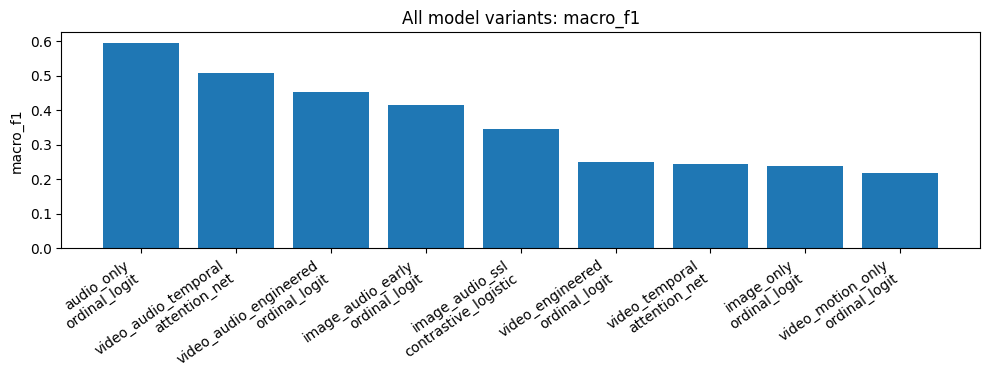

Saved: /content/ifpalvd_project/artifacts/figures/comparison_all_models_macro_f1.png


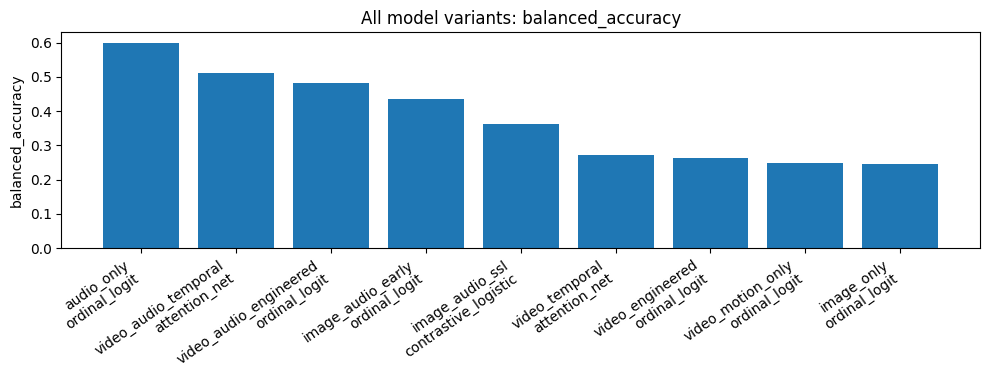

Saved: /content/ifpalvd_project/artifacts/figures/comparison_all_models_balanced_accuracy.png


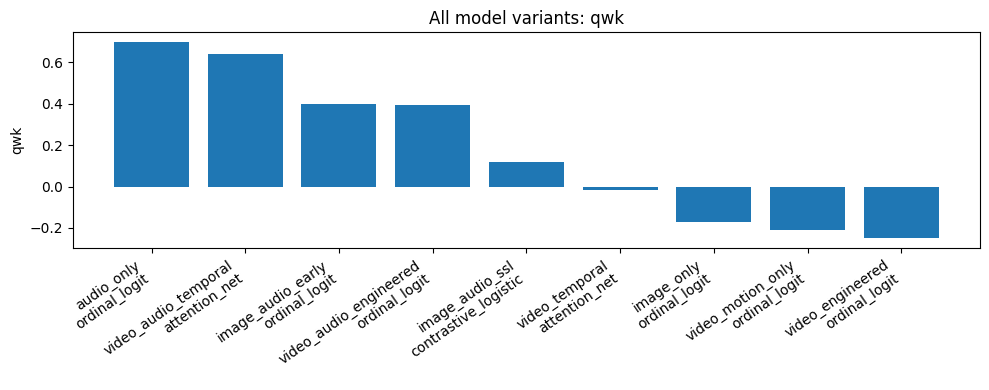

Saved: /content/ifpalvd_project/artifacts/figures/comparison_all_models_qwk.png


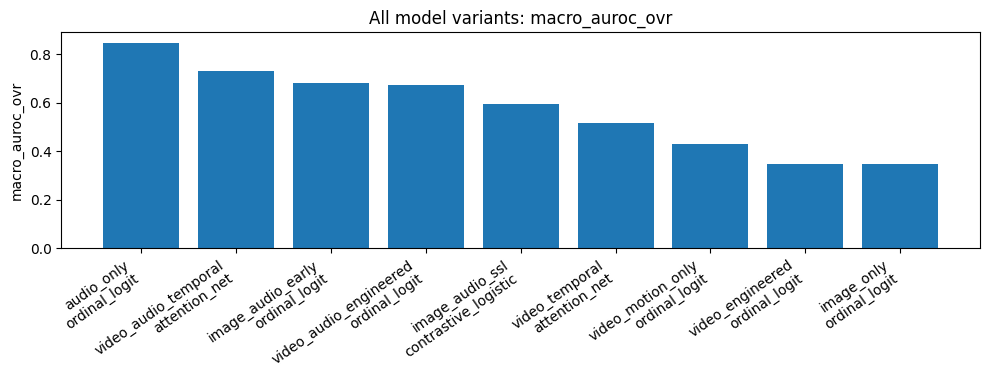

Saved: /content/ifpalvd_project/artifacts/figures/comparison_all_models_macro_auroc_ovr.png


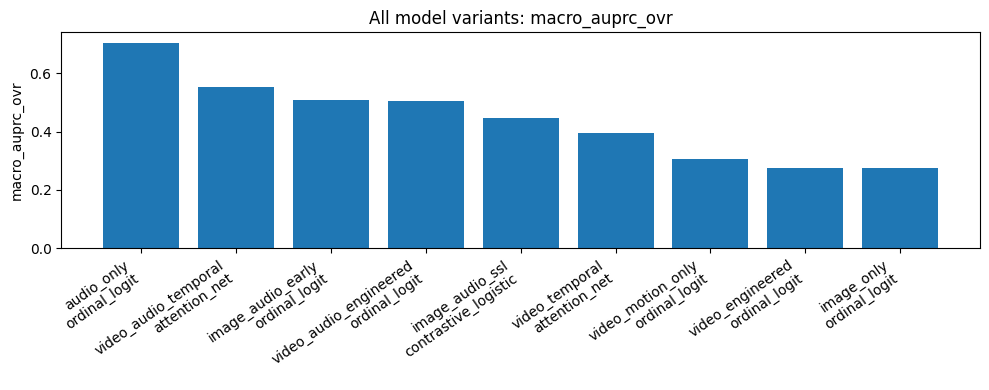

Saved: /content/ifpalvd_project/artifacts/figures/comparison_all_models_macro_auprc_ovr.png


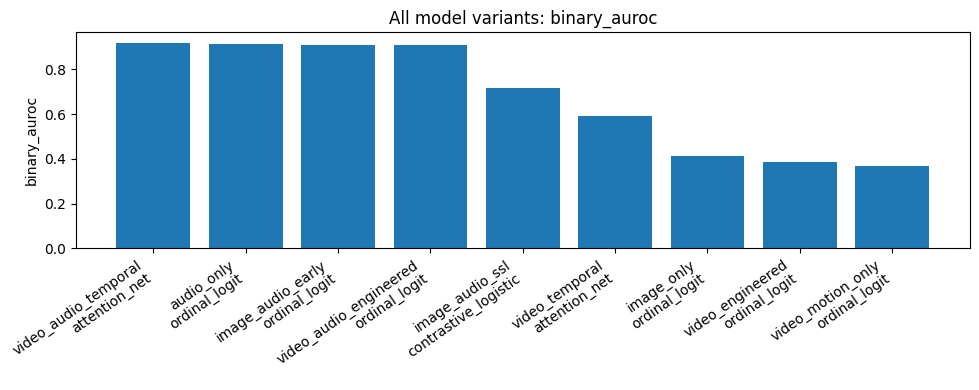

Saved: /content/ifpalvd_project/artifacts/figures/comparison_all_models_binary_auroc.png


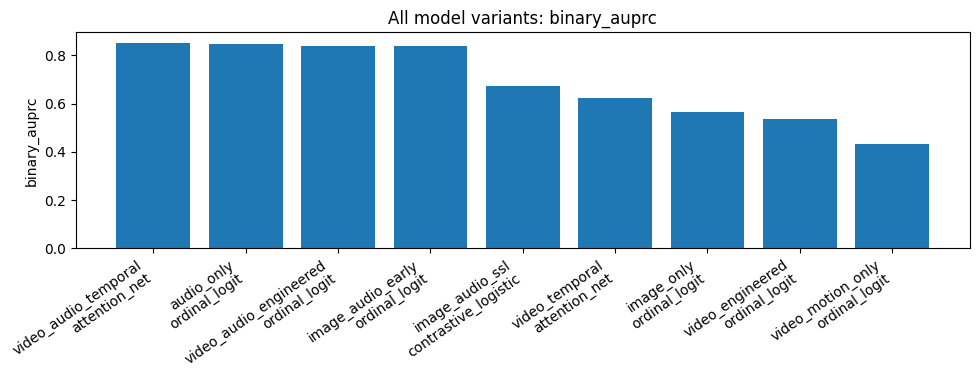

Saved: /content/ifpalvd_project/artifacts/figures/comparison_all_models_binary_auprc.png


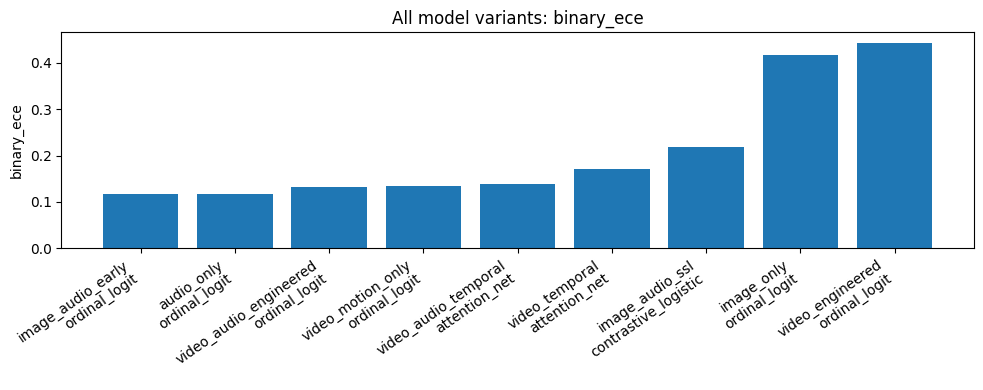

Saved: /content/ifpalvd_project/artifacts/figures/comparison_all_models_binary_ece.png


In [56]:
# ============================================================
# STEP 15: Publishable comparison figures
# ============================================================

fig_dir = Path(cfg.artifact_root) / "figures"
fig_dir.mkdir(parents=True, exist_ok=True)

if not results_df.empty:
    if "comparison_arm" not in results_df.columns:
        results_df["comparison_arm"] = results_df["feature_set"].map(infer_comparison_arm)

    metrics_to_plot = [
        "macro_f1",
        "balanced_accuracy",
        "qwk",
        "macro_auroc_ovr",
        "macro_auprc_ovr",
        "binary_auroc",
        "binary_auprc",
        "binary_ece",
    ]

    plot_df = results_df.copy()
    plot_df["label"] = plot_df["feature_set"].astype(str) + "\n" + plot_df["model"].astype(str)

    for metric in metrics_to_plot:
        if metric not in plot_df.columns or plot_df[metric].dropna().empty:
            continue

        ascending = metric in ["binary_ece", "ordinal_mae"]

        order = (
            plot_df
            .dropna(subset=[metric])
            .sort_values(metric, ascending=ascending)
        )

        plt.figure(figsize=(10, 4))
        plt.bar(order["label"], order[metric])
        plt.title(f"All model variants: {metric}")
        plt.ylabel(metric)
        plt.xticks(rotation=35, ha="right")
        plt.tight_layout()

        out = fig_dir / f"comparison_all_models_{metric}.png"
        plt.savefig(out, dpi=300)
        plt.show()

        print("Saved:", out)

else:
    print("No model results available for plotting.")

,comparison_arm,feature_set,model,macro_f1,balanced_accuracy,qwk,binary_auroc,binary_auprc,binary_ece
0,Audio,audio_only,ordinal_logit,0.596106,0.600385,0.697703,0.914855,0.846911,0.118104
1,Image,image_only,ordinal_logit,0.239423,0.246985,-0.171390,0.411232,0.567260,0.417485
2,Image+Audio,image_audio_early,ordinal_logit,0.416190,0.436708,0.400965,0.907609,0.838090,0.116558
3,Video,video_engineered,ordinal_logit,0.250574,0.262795,-0.250589,0.387681,0.535210,0.443950
4,Video+Audio,video_audio_temporal,attention_net,0.509072,0.512111,0.638889,0.920290,0.853061,0.138263


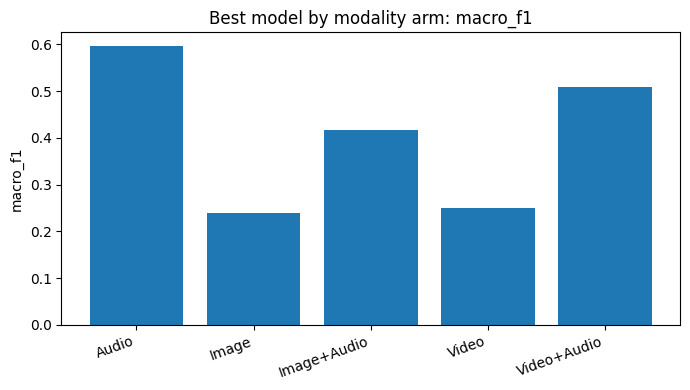

Saved: /content/ifpalvd_project/artifacts/figures/comparison_best_by_arm_macro_f1.png


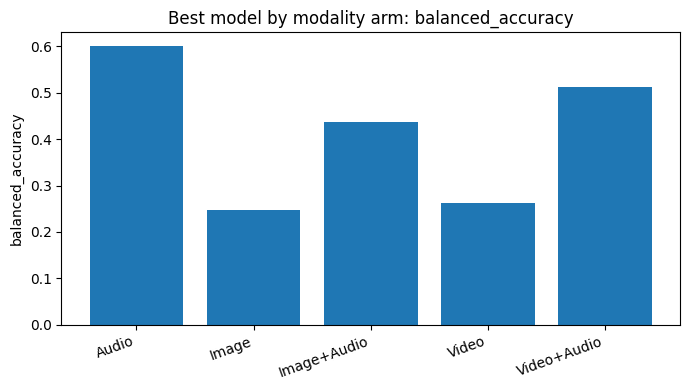

Saved: /content/ifpalvd_project/artifacts/figures/comparison_best_by_arm_balanced_accuracy.png


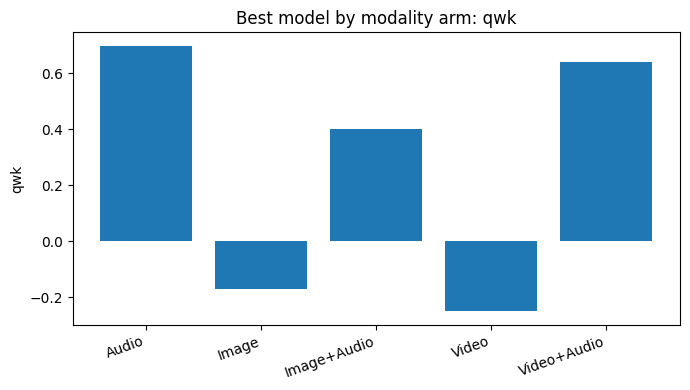

Saved: /content/ifpalvd_project/artifacts/figures/comparison_best_by_arm_qwk.png


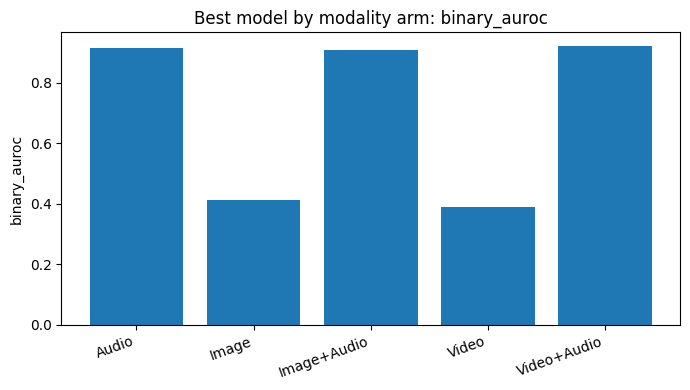

Saved: /content/ifpalvd_project/artifacts/figures/comparison_best_by_arm_binary_auroc.png


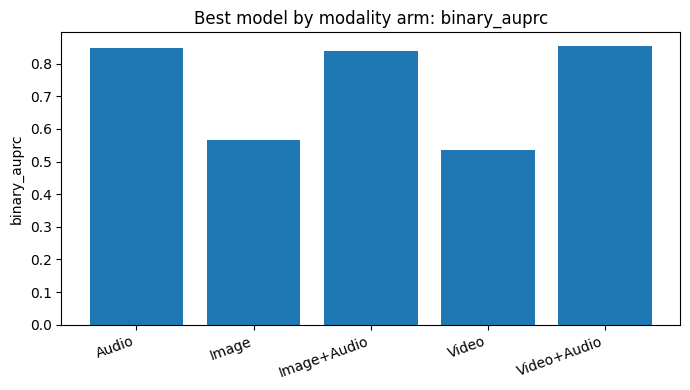

Saved: /content/ifpalvd_project/artifacts/figures/comparison_best_by_arm_binary_auprc.png


In [57]:
# ============================================================
# STEP 15B: Best model by modality arm
# ============================================================

arm_order = ["Audio", "Image", "Image+Audio", "Video", "Video+Audio"]
arm_rank = {arm: i for i, arm in enumerate(arm_order)}

if not results_df.empty:
    if "modality_best_df" not in globals() or modality_best_df.empty:
        modality_best_df = (
            results_df[results_df["comparison_arm"].isin(arm_order)]
            .assign(_arm_rank=lambda x: x["comparison_arm"].map(arm_rank))
            .sort_values(
                ["_arm_rank", "macro_f1", "balanced_accuracy", "qwk"],
                ascending=[True, False, False, False]
            )
            .groupby("comparison_arm", as_index=False)
            .head(1)
            .drop(columns=["_arm_rank"])
            .reset_index(drop=True)
        )

    best_arm_path = Path(cfg.artifact_root) / "tables" / "best_by_comparison_arm.csv"
    modality_best_df.to_csv(best_arm_path, index=False)

    display_cols = [
        "comparison_arm",
        "feature_set",
        "model",
        "macro_f1",
        "balanced_accuracy",
        "qwk",
        "binary_auroc",
        "binary_auprc",
        "binary_ece",
    ]

    display(modality_best_df[[c for c in display_cols if c in modality_best_df.columns]])

    for metric in ["macro_f1", "balanced_accuracy", "qwk", "binary_auroc", "binary_auprc"]:
        if metric not in modality_best_df.columns or modality_best_df[metric].dropna().empty:
            continue

        order = (
            modality_best_df
            .set_index("comparison_arm")
            .reindex(arm_order)
            .dropna(subset=[metric])
            .reset_index()
        )

        plt.figure(figsize=(7, 4))
        plt.bar(order["comparison_arm"], order[metric])
        plt.title(f"Best model by modality arm: {metric}")
        plt.ylabel(metric)
        plt.xticks(rotation=20, ha="right")
        plt.tight_layout()

        out = fig_dir / f"comparison_best_by_arm_{metric}.png"
        plt.savefig(out, dpi=300)
        plt.show()

        print("Saved:", out)

In [58]:
# ============================================================
# STEP 15C: One compact multi-metric publication table
# ============================================================

summary_cols = [
    "comparison_arm",
    "feature_set",
    "model",
    "n_rows",
    "n_features",
    "accuracy",
    "balanced_accuracy",
    "macro_f1",
    "qwk",
    "binary_auroc",
    "binary_auprc",
    "binary_ece",
]

publication_comparison_df = modality_best_df[
    [c for c in summary_cols if c in modality_best_df.columns]
].copy()

publication_path = Path(cfg.artifact_root) / "tables" / "publication_modality_comparison.csv"
publication_comparison_df.to_csv(publication_path, index=False)

display(publication_comparison_df)

print("Publication comparison table saved to:", publication_path)

,comparison_arm,feature_set,model,n_rows,n_features,accuracy,balanced_accuracy,macro_f1,qwk,binary_auroc,binary_auprc,binary_ece
0,Audio,audio_only,ordinal_logit,47,211,0.680851,0.600385,0.596106,0.697703,0.914855,0.846911,0.118104
1,Image,image_only,ordinal_logit,47,1536,0.276596,0.246985,0.239423,-0.171390,0.411232,0.567260,0.417485
2,Image+Audio,image_audio_early,ordinal_logit,47,1747,0.531915,0.436708,0.416190,0.400965,0.907609,0.838090,0.116558
3,Video,video_engineered,ordinal_logit,47,1600,0.276596,0.262795,0.250574,-0.250589,0.387681,0.535210,0.443950
4,Video+Audio,video_audio_temporal,attention_net,47,723,0.574468,0.512111,0.509072,0.638889,0.920290,0.853061,0.138263


Publication comparison table saved to: /content/ifpalvd_project/artifacts/tables/publication_modality_comparison.csv


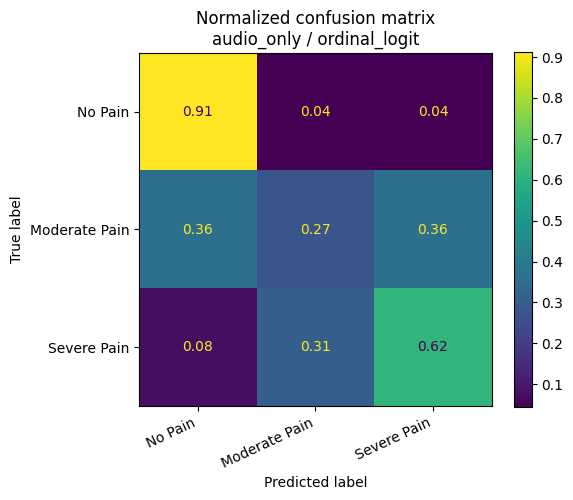

Saved: /content/ifpalvd_project/artifacts/figures/best_confusion_matrix.png


In [59]:
# ============================================================
# STEP 15D: Confusion matrix for best model
# ============================================================

def plot_confusion_for_best(preds_df, results_df):
    if preds_df.empty or results_df.empty:
        print("No predictions/results available.")
        return

    best = results_df.sort_values(
        ["macro_f1", "balanced_accuracy", "qwk"],
        ascending=False
    ).iloc[0]

    sub = preds_df[
        (preds_df["feature_set"] == best["feature_set"]) &
        (preds_df["model"] == best["model"])
    ].copy()

    if sub.empty:
        print("No matching predictions found for best model.")
        return

    cm = confusion_matrix(
        sub["y_true"].astype(int),
        sub["y_pred"].astype(int),
        labels=[0, 1, 2],
        normalize="true"
    )

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=pain_order
    )

    fig, ax = plt.subplots(figsize=(6, 5))
    disp.plot(ax=ax, values_format=".2f", colorbar=True)

    ax.set_title(
        f"Normalized confusion matrix\n"
        f"{best['feature_set']} / {best['model']}"
    )

    plt.xticks(rotation=25, ha="right")
    plt.tight_layout()

    out = fig_dir / "best_confusion_matrix.png"
    plt.savefig(out, dpi=300)
    plt.show()

    print("Saved:", out)


plot_confusion_for_best(preds_df, results_df)

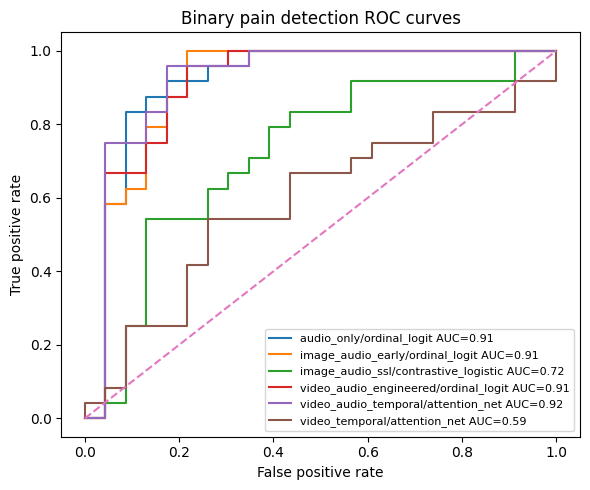

Saved: /content/ifpalvd_project/artifacts/figures/binary_roc_curves.png


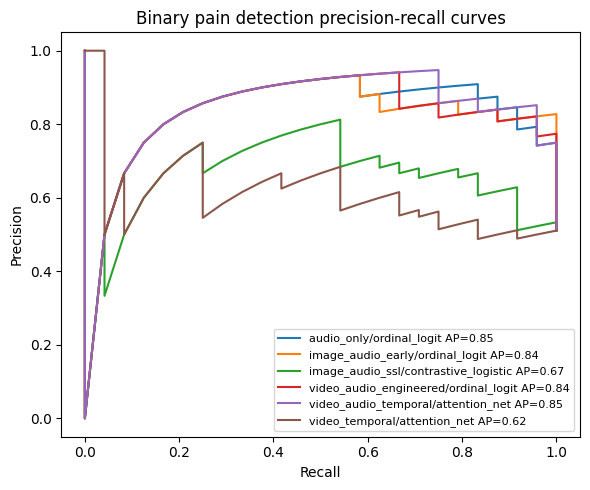

Saved: /content/ifpalvd_project/artifacts/figures/binary_pr_curves.png


In [60]:
# ============================================================
# STEP 15E: Binary ROC and precision-recall curves
# ============================================================

def plot_binary_roc_pr(preds_df, results_df=None, top_n=6):
    if preds_df.empty:
        print("No predictions available.")
        return

    plot_keys = None

    if results_df is not None and not results_df.empty and "binary_auroc" in results_df.columns:
        top = (
            results_df
            .dropna(subset=["binary_auroc"])
            .sort_values("binary_auroc", ascending=False)
            .head(top_n)
        )
        plot_keys = set(zip(top["feature_set"], top["model"]))

    # ROC curves
    plt.figure(figsize=(6, 5))

    for (fs, model), sub in preds_df.groupby(["feature_set", "model"]):
        if plot_keys is not None and (fs, model) not in plot_keys:
            continue

        if sub["pain_binary"].nunique() < 2:
            continue

        try:
            fpr, tpr, _ = roc_curve(sub["pain_binary"], sub["prob_pain_binary"])
            auc = roc_auc_score(sub["pain_binary"], sub["prob_pain_binary"])
            plt.plot(fpr, tpr, label=f"{fs}/{model} AUC={auc:.2f}")
        except Exception:
            continue

    plt.plot([0, 1], [0, 1], linestyle="--")
    plt.xlabel("False positive rate")
    plt.ylabel("True positive rate")
    plt.title("Binary pain detection ROC curves")
    plt.legend(fontsize=8)
    plt.tight_layout()

    out = fig_dir / "binary_roc_curves.png"
    plt.savefig(out, dpi=300)
    plt.show()
    print("Saved:", out)

    # Precision-recall curves
    plt.figure(figsize=(6, 5))

    for (fs, model), sub in preds_df.groupby(["feature_set", "model"]):
        if plot_keys is not None and (fs, model) not in plot_keys:
            continue

        if sub["pain_binary"].nunique() < 2:
            continue

        try:
            precision, recall, _ = precision_recall_curve(
                sub["pain_binary"],
                sub["prob_pain_binary"]
            )
            ap = average_precision_score(sub["pain_binary"], sub["prob_pain_binary"])
            plt.plot(recall, precision, label=f"{fs}/{model} AP={ap:.2f}")
        except Exception:
            continue

    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title("Binary pain detection precision-recall curves")
    plt.legend(fontsize=8)
    plt.tight_layout()

    out = fig_dir / "binary_pr_curves.png"
    plt.savefig(out, dpi=300)
    plt.show()
    print("Saved:", out)


plot_binary_roc_pr(preds_df, results_df, top_n=6)

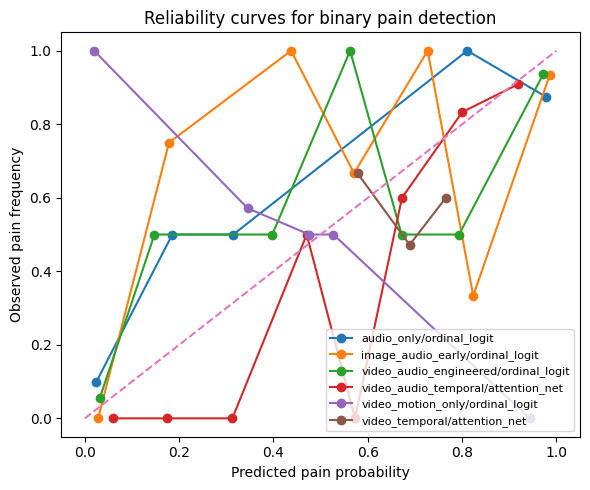

Saved: /content/ifpalvd_project/artifacts/figures/binary_calibration_curves.png


In [61]:
# ============================================================
# STEP 15F: Calibration curves for binary pain detection
# ============================================================

def plot_calibration(preds_df, results_df=None, n_bins=8, top_n=6):
    if preds_df.empty:
        print("No predictions available.")
        return

    plot_keys = None

    if results_df is not None and not results_df.empty and "binary_ece" in results_df.columns:
        top = (
            results_df
            .dropna(subset=["binary_ece"])
            .sort_values("binary_ece", ascending=True)
            .head(top_n)
        )
        plot_keys = set(zip(top["feature_set"], top["model"]))

    plt.figure(figsize=(6, 5))

    for (fs, model), sub in preds_df.groupby(["feature_set", "model"]):
        if plot_keys is not None and (fs, model) not in plot_keys:
            continue

        y = sub["pain_binary"].astype(int).to_numpy()
        p = sub["prob_pain_binary"].astype(float).to_numpy()

        if len(np.unique(y)) < 2:
            continue

        bins = np.linspace(0, 1, n_bins + 1)
        xs, ys = [], []

        for i in range(n_bins):
            lo, hi = bins[i], bins[i + 1]

            if i < n_bins - 1:
                mask = (p >= lo) & (p < hi)
            else:
                mask = (p >= lo) & (p <= hi)

            if mask.sum() >= 2:
                xs.append(p[mask].mean())
                ys.append(y[mask].mean())

        if xs:
            plt.plot(xs, ys, marker="o", label=f"{fs}/{model}")

    plt.plot([0, 1], [0, 1], linestyle="--")
    plt.xlabel("Predicted pain probability")
    plt.ylabel("Observed pain frequency")
    plt.title("Reliability curves for binary pain detection")
    plt.legend(fontsize=8)
    plt.tight_layout()

    out = fig_dir / "binary_calibration_curves.png"
    plt.savefig(out, dpi=300)
    plt.show()

    print("Saved:", out)


plot_calibration(preds_df, results_df, n_bins=8, top_n=6)

In [62]:
# ============================================================
# STEP 15G: Calibration before and after for binary pain detection
# ============================================================

def _make_base_model_for_name(model_name: str):
    if model_name in ["logistic", "rf"]:
        return make_classifier(model_name)

    if model_name == "ordinal_logit":
        return CumulativeOrdinalLogit()

    raise ValueError(f"Unsupported calibration base model: {model_name}")


def _fit_binary_calibrator(method: str, p_cal, y_cal):
    p_cal = np.asarray(p_cal).reshape(-1)
    y_cal = np.asarray(y_cal).astype(int).reshape(-1)

    if len(np.unique(y_cal)) < 2:
        const = float(y_cal[0]) if len(y_cal) else 0.0
        return ("constant", const)

    if method == "platt":
        mdl = LogisticRegression(max_iter=2000, solver="lbfgs")
        mdl.fit(p_cal.reshape(-1, 1), y_cal)
        return ("model", mdl)

    if method == "isotonic":
        mdl = IsotonicRegression(out_of_bounds="clip")
        mdl.fit(p_cal, y_cal)
        return ("model", mdl)

    raise ValueError(method)


def _apply_binary_calibrator(fitted, method: str, p):
    p = np.asarray(p).reshape(-1)
    kind, obj = fitted

    if kind == "constant":
        return np.full(len(p), float(obj), dtype=float)

    if method == "platt":
        return obj.predict_proba(p.reshape(-1, 1))[:, 1]

    if method == "isotonic":
        return obj.predict(p)

    raise ValueError(method)

In [63]:
def run_before_after_calibration(data, feature_cols, feature_set_name, model_name):
    valid = data.dropna(subset=["pain_code", "pain_binary"]).copy()

    X = valid[feature_cols].replace([np.inf, -np.inf], np.nan)

    nonempty = X.notna().any(axis=1)
    valid = valid.loc[nonempty].reset_index(drop=True)
    X = X.loc[nonempty].reset_index(drop=True)

    if len(valid) < 10 or valid["pain_binary"].nunique() < 2:
        print("Skipping calibration before/after: insufficient valid rows/classes.")
        return pd.DataFrame(), pd.DataFrame()

    splits, split_name, n_splits_eff = make_cv_indices(
        valid,
        y_col="pain_code",
        group_col="group_id",
        n_splits=cfg.n_splits,
    )

    print(
        f"Calibration before/after for {feature_set_name}/{model_name}: "
        f"{len(valid)} rows, {split_name}, {n_splits_eff} folds"
    )

    rows = []

    for fold, (tr_idx, te_idx) in enumerate(splits, start=1):
        y_train_binary = valid.iloc[tr_idx]["pain_binary"].astype(int).to_numpy()
        train_pos = int(y_train_binary.sum())
        train_neg = int(len(y_train_binary) - train_pos)

        if (
            len(np.unique(y_train_binary)) > 1
            and len(tr_idx) >= 8
            and train_pos >= 2
            and train_neg >= 2
        ):
            try:
                base_rel, calib_rel = train_test_split(
                    np.arange(len(tr_idx)),
                    test_size=max(cfg.calibration_holdout_frac, 0.2),
                    random_state=RANDOM_STATE + fold,
                    stratify=y_train_binary,
                )
            except Exception:
                base_rel, calib_rel = train_test_split(
                    np.arange(len(tr_idx)),
                    test_size=max(cfg.calibration_holdout_frac, 0.2),
                    random_state=RANDOM_STATE + fold,
                )
        else:
            base_rel = np.arange(len(tr_idx))
            calib_rel = np.arange(len(tr_idx))

        base_idx = np.array(tr_idx)[base_rel]
        calib_idx = np.array(tr_idx)[calib_rel]

        model = _make_base_model_for_name(model_name)

        model.fit(
            X.iloc[base_idx],
            valid.iloc[base_idx]["pain_code"].astype(int),
        )

        proba_te = predict_proba_3class(model, X.iloc[te_idx])
        raw_te = proba_te[:, 1] + proba_te[:, 2]

        proba_cal = predict_proba_3class(model, X.iloc[calib_idx])
        raw_cal = proba_cal[:, 1] + proba_cal[:, 2]

        y_cal = valid.iloc[calib_idx]["pain_binary"].astype(int).to_numpy()

        cal_preds = {}

        for method in cfg.calibration_methods:
            fitted = _fit_binary_calibrator(method, raw_cal, y_cal)
            cal_preds[method] = _apply_binary_calibrator(fitted, method, raw_te)

        base_cols = [
            c for c in [
                "video_name",
                "video_path",
                "group_id",
                "pain_level",
                "pain_code",
                "pain_binary",
                "cry_binary",
            ]
            if c in valid.columns
        ]

        fold_df = valid.iloc[te_idx][base_cols].copy()
        fold_df["fold"] = fold
        fold_df["feature_set"] = feature_set_name
        fold_df["model"] = model_name
        fold_df["prob_raw"] = raw_te

        for method, arr in cal_preds.items():
            fold_df[f"prob_{method}"] = arr

        rows.append(fold_df)

    pred_df = pd.concat(rows, ignore_index=True)

    metric_rows = []

    for label, col in [("raw", "prob_raw")] + [
        (m, f"prob_{m}") for m in cfg.calibration_methods
    ]:
        y = pred_df["pain_binary"].astype(int).to_numpy()
        p = pred_df[col].astype(float).to_numpy()

        metric_rows.append({
            "variant": label,
            "binary_brier": brier_score_loss(y, p),
            "binary_ece": expected_calibration_error(y, p),
            "binary_auroc": roc_auc_score(y, p) if len(np.unique(y)) > 1 else np.nan,
            "binary_auprc": average_precision_score(y, p) if len(np.unique(y)) > 1 else np.nan,
            "binary_f1_at_0_5": f1_score(y, (p >= 0.5).astype(int), zero_division=0),
        })

    metrics_df = pd.DataFrame(metric_rows)

    return metrics_df, pred_df

In [64]:
# ============================================================
# STEP 15G-B: Run calibration before/after
# ============================================================

if cfg.run_calibration_before_after and not results_df.empty:
    supported_feature_sets = [
        "audio_only",
        "image_only",
        "image_audio_early",
        "video_motion_only",
        "video_engineered",
        "video_audio_engineered",
    ]

    calib_candidates = results_df[
        results_df["feature_set"].isin(supported_feature_sets)
        & results_df["model"].isin(["logistic", "rf", "ordinal_logit"])
    ].copy()

    if calib_candidates.empty:
        print("No supported candidate was available for before/after calibration.")
        calibration_metrics_df = pd.DataFrame()
        calibration_pred_df = pd.DataFrame()

    else:
        calib_best = (
            calib_candidates
            .sort_values(["binary_auroc", "macro_f1"], ascending=False)
            .iloc[0]
        )

        print("Calibration candidate:")
        print(calib_best[["feature_set", "model", "binary_auroc", "macro_f1"]])

        calib_data, calib_cols = get_feature_set_data(calib_best["feature_set"])

        calibration_metrics_df, calibration_pred_df = run_before_after_calibration(
            calib_data,
            calib_cols,
            calib_best["feature_set"],
            calib_best["model"],
        )

        display(calibration_metrics_df)

        calibration_metrics_path = Path(cfg.artifact_root) / "tables" / "calibration_before_after_metrics.csv"
        calibration_preds_path = Path(cfg.artifact_root) / "tables" / "calibration_before_after_predictions.csv"

        calibration_metrics_df.to_csv(calibration_metrics_path, index=False)
        calibration_pred_df.to_csv(calibration_preds_path, index=False)

        print("Saved:", calibration_metrics_path)
        print("Saved:", calibration_preds_path)

else:
    calibration_metrics_df = pd.DataFrame()
    calibration_pred_df = pd.DataFrame()
    print("Calibration-before-after section skipped.")

Calibration candidate:
feature_set        audio_only
model           ordinal_logit
binary_auroc         0.914855
macro_f1             0.596106
Name: 0, dtype: object
Calibration before/after for audio_only/ordinal_logit: 47 rows, StratifiedGroupKFold, 5 folds


,variant,binary_brier,binary_ece,binary_auroc,binary_auprc,binary_f1_at_0_5
0,raw,0.116993,0.119718,0.922101,0.855713,0.851064
1,platt,0.188988,0.255030,0.875000,0.846732,0.857143
2,isotonic,0.109233,0.108763,0.933877,0.897117,0.857143


Saved: /content/ifpalvd_project/artifacts/tables/calibration_before_after_metrics.csv
Saved: /content/ifpalvd_project/artifacts/tables/calibration_before_after_predictions.csv


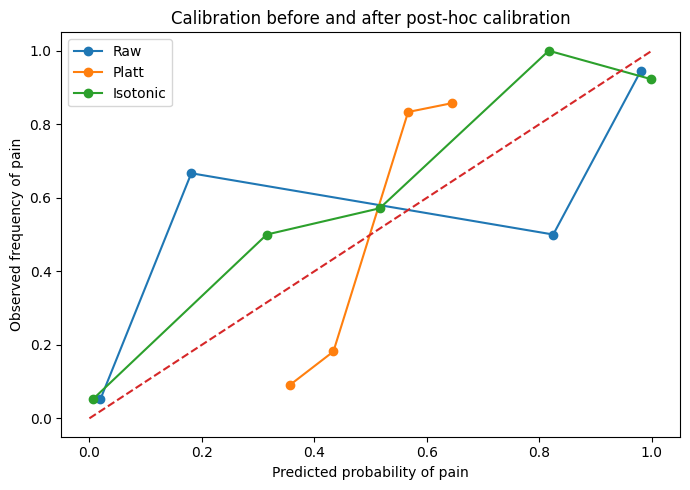

Saved: /content/ifpalvd_project/artifacts/figures/calibration_before_after_reliability.png


In [65]:
# ============================================================
# STEP 15G-C: Plot calibration before/after
# ============================================================

if "calibration_pred_df" in globals() and not calibration_pred_df.empty:
    plt.figure(figsize=(7, 5))
    bins = np.linspace(0, 1, 9)

    variants = [("Raw", "prob_raw")] + [
        (m.title(), f"prob_{m}") for m in cfg.calibration_methods
    ]

    for label, col in variants:
        if col not in calibration_pred_df.columns:
            continue

        y = calibration_pred_df["pain_binary"].astype(int).to_numpy()
        p = calibration_pred_df[col].astype(float).to_numpy()

        xs, ys = [], []

        for i in range(len(bins) - 1):
            lo, hi = bins[i], bins[i + 1]

            if i < len(bins) - 2:
                mask = (p >= lo) & (p < hi)
            else:
                mask = (p >= lo) & (p <= hi)

            if mask.sum() >= 2:
                xs.append(p[mask].mean())
                ys.append(y[mask].mean())

        if xs:
            plt.plot(xs, ys, marker="o", label=label)

    plt.plot([0, 1], [0, 1], linestyle="--")
    plt.xlabel("Predicted probability of pain")
    plt.ylabel("Observed frequency of pain")
    plt.title("Calibration before and after post-hoc calibration")
    plt.legend()
    plt.tight_layout()

    out = fig_dir / "calibration_before_after_reliability.png"
    plt.savefig(out, dpi=300)
    plt.show()

    print("Saved:", out)

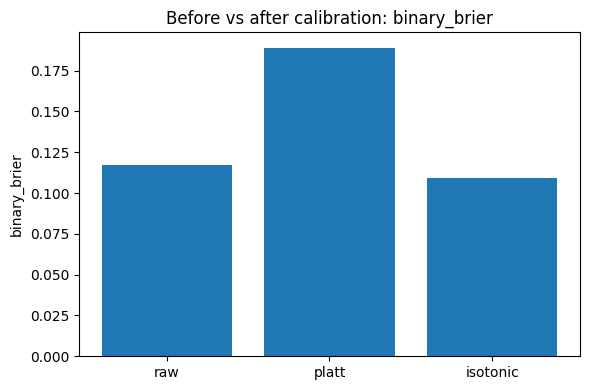

Saved: /content/ifpalvd_project/artifacts/figures/calibration_before_after_binary_brier.png


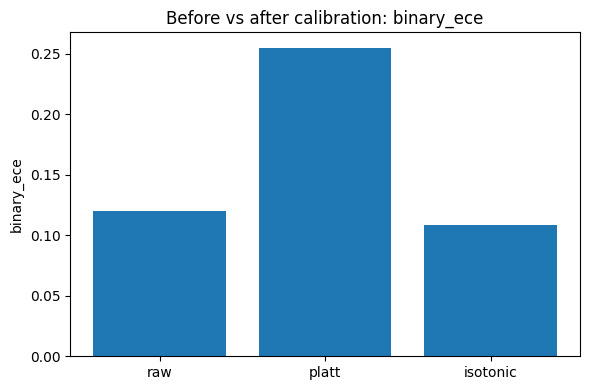

Saved: /content/ifpalvd_project/artifacts/figures/calibration_before_after_binary_ece.png


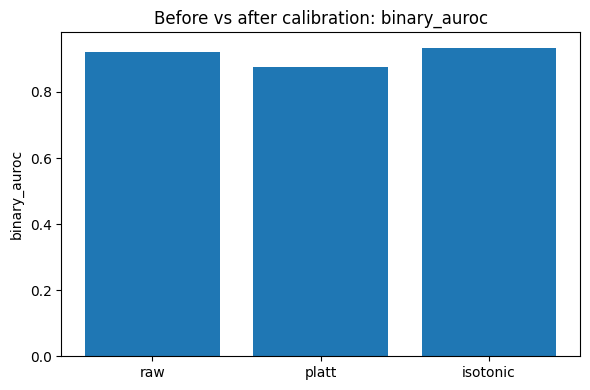

Saved: /content/ifpalvd_project/artifacts/figures/calibration_before_after_binary_auroc.png


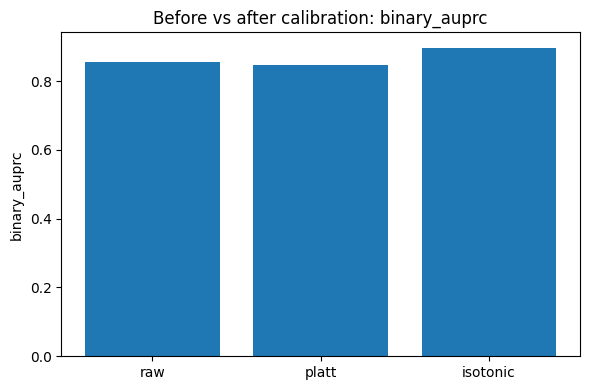

Saved: /content/ifpalvd_project/artifacts/figures/calibration_before_after_binary_auprc.png


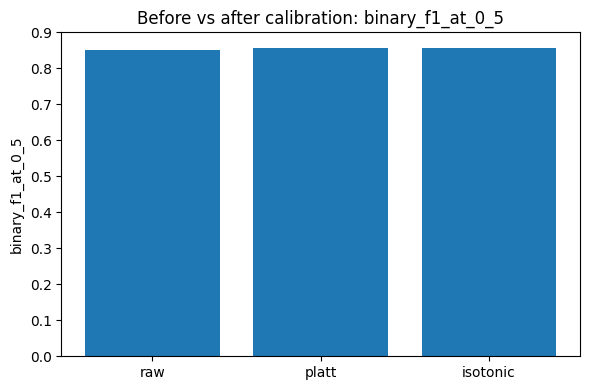

Saved: /content/ifpalvd_project/artifacts/figures/calibration_before_after_binary_f1_at_0_5.png


In [66]:
# ============================================================
# STEP 15G-D: Plot calibration metrics
# ============================================================

if "calibration_metrics_df" in globals() and not calibration_metrics_df.empty:
    for metric in [
        "binary_brier",
        "binary_ece",
        "binary_auroc",
        "binary_auprc",
        "binary_f1_at_0_5",
    ]:
        if metric not in calibration_metrics_df.columns:
            continue

        sub = calibration_metrics_df[["variant", metric]].dropna()

        if sub.empty:
            continue

        plt.figure(figsize=(6, 4))
        plt.bar(sub["variant"], sub[metric])
        plt.title(f"Before vs after calibration: {metric}")
        plt.ylabel(metric)
        plt.tight_layout()

        out = fig_dir / f"calibration_before_after_{metric}.png"
        plt.savefig(out, dpi=300)
        plt.show()

        print("Saved:", out)

In [67]:
# ============================================================
# STEP 16: Permutation importance for image+audio and video+audio
# ============================================================

def feature_family_name(feature: str) -> str:
    if feature.startswith((
        "mfcc_", "zcr_", "rms_", "centroid_", "bandwidth_",
        "rolloff_", "contrast_", "chroma_", "audio_duration_s"
    )):
        return "audio"

    if feature.startswith(("resnet_center_", "resnet_mean_", "resnet_std_")):
        return "image"

    if feature.startswith((
        "video_flow_", "video_diff_", "video_motion_",
        "video_frame_change_", "n_motion_pairs"
    )):
        return "video_motion"

    return "other"

In [68]:
def run_permutation_importance_for_fusion(
    fusion_name: str,
    valid_mask,
    cols: list[str],
    n_repeats: int = 10,
):
    sub = df[valid_mask].dropna(subset=["pain_code"]).copy().reset_index(drop=True)

    if len(sub) < 10 or not cols or sub["pain_code"].nunique() < 2:
        print(f"Not enough valid fused data for permutation importance: {fusion_name}")
        return pd.DataFrame(), pd.DataFrame()

    X = sub[cols].replace([np.inf, -np.inf], np.nan)
    y = sub["pain_code"].astype(int)

    nonempty = X.notna().any(axis=1)
    sub = sub.loc[nonempty].reset_index(drop=True)
    X = X.loc[nonempty].reset_index(drop=True)
    y = y.loc[nonempty].reset_index(drop=True)

    splits, split_name, n_splits_eff = make_cv_indices(
        sub,
        y_col="pain_code",
        group_col="group_id",
        n_splits=cfg.n_splits,
    )

    print(
        f"Permutation importance for {fusion_name}: "
        f"{len(sub)} rows, {len(cols)} features, {split_name}, {n_splits_eff} folds"
    )

    all_rows = []

    for fold, (tr_idx, te_idx) in enumerate(splits, start=1):
        model = make_classifier("logistic")

        X_train = X.iloc[tr_idx]
        X_test = X.iloc[te_idx]

        y_train = y.iloc[tr_idx]
        y_test = y.iloc[te_idx]

        model.fit(X_train, y_train)

        try:
            perm = permutation_importance(
                model,
                X_test,
                y_test,
                n_repeats=n_repeats,
                random_state=RANDOM_STATE + fold,
                scoring="balanced_accuracy",
                n_jobs=-1,
            )

            fold_imp = pd.DataFrame({
                "fold": fold,
                "feature": X.columns,
                "importance_mean": perm.importances_mean,
                "importance_std": perm.importances_std,
            })

            fold_imp["family"] = fold_imp["feature"].map(feature_family_name)
            all_rows.append(fold_imp)

        except Exception as e:
            print(f"Fold {fold} permutation importance skipped for {fusion_name}: {e}")

    if not all_rows:
        return pd.DataFrame(), pd.DataFrame()

    imp_long_df = pd.concat(all_rows, ignore_index=True)

    imp_df = (
        imp_long_df
        .groupby(["feature", "family"], as_index=False)
        .agg(
            importance_mean=("importance_mean", "mean"),
            importance_std=("importance_mean", "std"),
        )
        .sort_values("importance_mean", ascending=False)
        .reset_index(drop=True)
    )

    family_imp = (
        imp_long_df
        .groupby(["fold", "family"], as_index=False)["importance_mean"]
        .sum()
        .groupby("family", as_index=False)
        .agg(
            importance_mean=("importance_mean", "mean"),
            importance_std=("importance_mean", "std"),
        )
        .sort_values("importance_mean", ascending=False)
    )

    imp_path = Path(cfg.artifact_root) / "tables" / f"permutation_importance_{fusion_name}.csv"
    family_path = Path(cfg.artifact_root) / "tables" / f"permutation_importance_family_{fusion_name}.csv"

    imp_df.to_csv(imp_path, index=False)
    family_imp.to_csv(family_path, index=False)

    display(imp_df.head(20))
    display(family_imp)

    plt.figure(figsize=(6, 4))
    plt.bar(family_imp["family"], family_imp["importance_mean"])
    plt.title(f"Permutation importance by modality: {fusion_name}")
    plt.ylabel("Mean decrease in balanced accuracy")
    plt.xticks(rotation=25, ha="right")
    plt.tight_layout()

    out = fig_dir / f"modality_permutation_importance_{fusion_name}.png"
    plt.savefig(out, dpi=300)
    plt.show()

    print("Saved:", imp_path)
    print("Saved:", family_path)
    print("Saved:", out)

    return imp_df, family_imp

Permutation importance for image_audio: 47 rows, 1747 features, StratifiedGroupKFold, 5 folds


,feature,family,importance_mean,importance_std
0,resnet_std_0420,image,0.033333,0.074536
1,resnet_std_0018,image,0.030000,0.067082
2,resnet_std_0407,image,0.030000,0.067082
3,resnet_std_0166,image,0.030000,0.067082
4,resnet_std_0365,image,0.030000,0.067082
5,resnet_std_0491,image,0.026667,0.059628
6,mfcc_12_min,audio,0.023333,0.052175
7,resnet_std_0140,image,0.020000,0.044721
8,resnet_std_0343,image,0.020000,0.044721
9,resnet_std_0318,image,0.020000,0.044721


,family,importance_mean,importance_std
1,image,0.603397,1.230677
0,audio,0.146667,0.327957


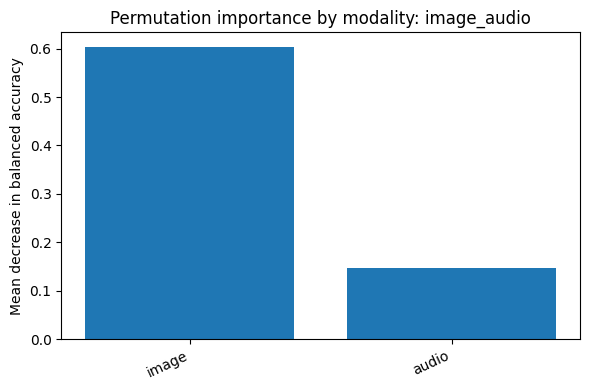

Saved: /content/ifpalvd_project/artifacts/tables/permutation_importance_image_audio.csv
Saved: /content/ifpalvd_project/artifacts/tables/permutation_importance_family_image_audio.csv
Saved: /content/ifpalvd_project/artifacts/figures/modality_permutation_importance_image_audio.png
Permutation importance for video_audio_engineered: 47 rows, 1811 features, StratifiedGroupKFold, 5 folds


,feature,family,importance_mean,importance_std
0,resnet_std_0491,image,0.026667,0.059628
1,resnet_std_0105,image,0.012000,0.026833
2,resnet_std_0005,image,0.005714,0.012778
3,resnet_std_0266,image,0.004286,0.009583
4,resnet_std_0278,image,0.002857,0.006389
5,resnet_std_0173,image,0.001429,0.003194
6,resnet_std_0124,image,0.001333,0.002981
7,resnet_std_0468,image,0.001333,0.002981
8,resnet_mean_0393,image,0.000000,0.000000
9,resnet_mean_0408,image,0.000000,0.000000


,family,importance_mean,importance_std
2,video_motion,0.000000,0.000000
0,audio,-0.152857,0.341799
1,image,-0.240095,0.658508


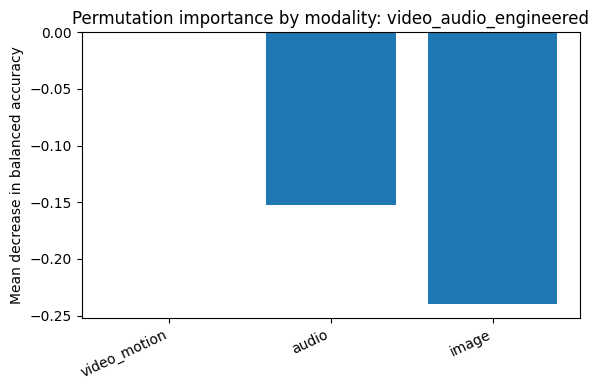

Saved: /content/ifpalvd_project/artifacts/tables/permutation_importance_video_audio_engineered.csv
Saved: /content/ifpalvd_project/artifacts/tables/permutation_importance_family_video_audio_engineered.csv
Saved: /content/ifpalvd_project/artifacts/figures/modality_permutation_importance_video_audio_engineered.png


In [69]:
image_audio_importance, image_audio_family_importance = run_permutation_importance_for_fusion(
    fusion_name="image_audio",
    valid_mask=(df["image_audio_valid"] == 1),
    cols=audio_cols + image_cols,
)

video_audio_importance, video_audio_family_importance = run_permutation_importance_for_fusion(
    fusion_name="video_audio_engineered",
    valid_mask=(df["video_feature_audio_valid"] == 1),
    cols=audio_cols + video_engineered_cols,
)

In [80]:
# Faster modality-level permutation importance

def run_modality_level_importance(
    fusion_name: str,
    valid_mask,
    modality_cols: dict,
    model_name="logistic",
    n_repeats=5,
):
    sub = df[valid_mask].dropna(subset=["pain_code"]).copy().reset_index(drop=True)

    all_cols = []
    for cols in modality_cols.values():
        all_cols.extend(cols)

    X = sub[all_cols].replace([np.inf, -np.inf], np.nan)
    y = sub["pain_code"].astype(int)

    nonempty = X.notna().any(axis=1)
    sub = sub.loc[nonempty].reset_index(drop=True)
    X = X.loc[nonempty].reset_index(drop=True)
    y = y.loc[nonempty].reset_index(drop=True)

    splits, split_name, n_splits_eff = make_cv_indices(
        sub,
        y_col="pain_code",
        group_col="group_id",
        n_splits=cfg.n_splits,
    )

    rows = []

    for fold, (tr_idx, te_idx) in enumerate(splits, start=1):
        rng = np.random.default_rng(RANDOM_STATE + fold)

        model = make_classifier(model_name)
        model.fit(X.iloc[tr_idx], y.iloc[tr_idx])

        base_pred = model.predict(X.iloc[te_idx])
        base_score = balanced_accuracy_score(y.iloc[te_idx], base_pred)

        for modality, cols in modality_cols.items():
            cols = [c for c in cols if c in X.columns]

            for rep in range(n_repeats):
                X_perm = X.iloc[te_idx].copy()

                for c in cols:
                    X_perm[c] = rng.permutation(X_perm[c].to_numpy())

                perm_pred = model.predict(X_perm)
                perm_score = balanced_accuracy_score(y.iloc[te_idx], perm_pred)

                rows.append({
                    "fusion_name": fusion_name,
                    "fold": fold,
                    "modality": modality,
                    "repeat": rep,
                    "base_score": base_score,
                    "permuted_score": perm_score,
                    "importance": base_score - perm_score,
                })

    out = pd.DataFrame(rows)

    summary = (
        out.groupby("modality", as_index=False)
        .agg(
            importance_mean=("importance", "mean"),
            importance_std=("importance", "std"),
        )
        .sort_values("importance_mean", ascending=False)
    )

    display(summary)

    summary.to_csv(
        Path(cfg.artifact_root) / "tables" / f"modality_level_importance_{fusion_name}.csv",
        index=False,
    )

    plt.figure(figsize=(6, 4))
    plt.bar(summary["modality"], summary["importance_mean"])
    plt.title(f"Modality-level permutation importance: {fusion_name}")
    plt.ylabel("Decrease in balanced accuracy")
    plt.xticks(rotation=25, ha="right")
    plt.tight_layout()
    plt.savefig(fig_dir / f"modality_level_importance_{fusion_name}.png", dpi=300)
    plt.show()

    return out, summary

,modality,importance_mean,importance_std
0,audio,0.245714,0.216111
1,image,-0.035175,0.180786


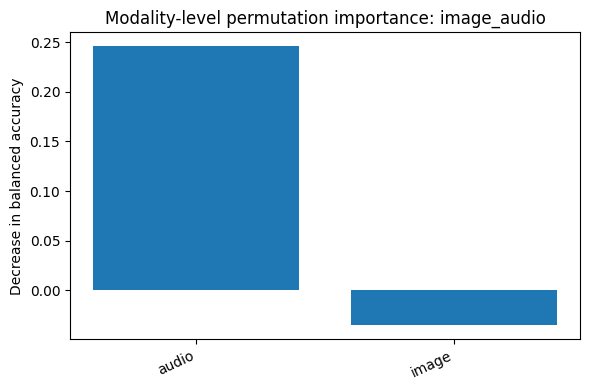

,modality,importance_mean,importance_std
0,audio,0.265079,0.245105
2,video_motion,0.033333,0.068041
1,image,0.006794,0.147200


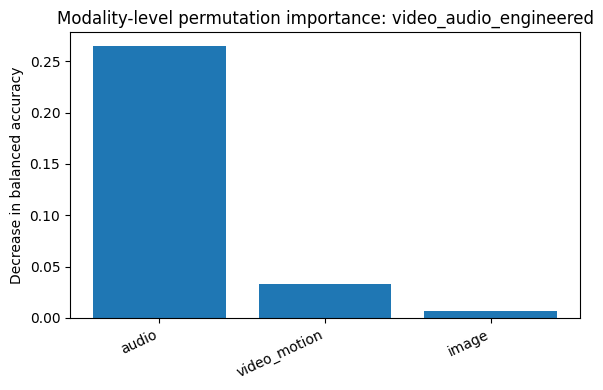

In [81]:
image_audio_perm_long, image_audio_family_importance = run_modality_level_importance(
    fusion_name="image_audio",
    valid_mask=(df["image_audio_valid"] == 1),
    modality_cols={
        "audio": audio_cols,
        "image": image_cols,
    },
    n_repeats=5,
)

video_audio_perm_long, video_audio_family_importance = run_modality_level_importance(
    fusion_name="video_audio_engineered",
    valid_mask=(df["video_feature_audio_valid"] == 1),
    modality_cols={
        "audio": audio_cols,
        "image": image_cols,
        "video_motion": video_motion_cols,
    },
    n_repeats=5,
)

In [70]:
# ============================================================
# STEP 17: Results summary generator
# ============================================================

summary_path = Path(cfg.artifact_root) / "tables" / "model_comparison.csv"

if results_df.empty:
    print("No results available.")

else:
    results_df = (
        results_df
        .sort_values(["macro_f1", "balanced_accuracy", "qwk"], ascending=False)
        .reset_index(drop=True)
    )

    best = results_df.iloc[0]

    display(results_df)

    print("\nSuggested results sentence:")
    print(
        f"The best-performing model was {best['feature_set']} ({best['model']}), "
        f"achieving macro-F1={best['macro_f1']:.3f}, "
        f"balanced accuracy={best['balanced_accuracy']:.3f}, "
        f"QWK={best.get('qwk', np.nan):.3f}, "
        f"macro-AUROC={best.get('macro_auroc_ovr', np.nan):.3f}, "
        f"and binary pain AUROC={best.get('binary_auroc', np.nan):.3f} "
        f"under leakage-aware cross-validation."
    )

    if "modality_best_df" in globals() and not modality_best_df.empty:
        modality_summary = modality_best_df[
            [
                c for c in [
                    "comparison_arm",
                    "feature_set",
                    "model",
                    "macro_f1",
                    "balanced_accuracy",
                    "qwk",
                    "binary_auroc",
                    "binary_auprc",
                    "binary_ece",
                ]
                if c in modality_best_df.columns
            ]
        ].copy()
    else:
        modality_summary = pd.DataFrame()

    dataset_note = (
        f"The analytic dataset included {len(df)} video-linked samples "
        f"from {df['group_id'].nunique() if 'group_id' in df.columns else 'unknown'} leakage-aware groups. "
        f"The label table contained {len(labels)} labelled rows before matching."
    )

    report = f"""
## IFPaLVD Audio-Visual Infant Pain Classification Summary

## Dataset

{dataset_note}

## Best overall model

**{best['feature_set']} / {best['model']}**

- Accuracy: {best.get('accuracy', np.nan):.3f}
- Balanced accuracy: {best.get('balanced_accuracy', np.nan):.3f}
- Macro-F1: {best.get('macro_f1', np.nan):.3f}
- Quadratic weighted kappa: {best.get('qwk', np.nan):.3f}
- Ordinal MAE: {best.get('ordinal_mae', np.nan):.3f}
- Macro AUROC OvR: {best.get('macro_auroc_ovr', np.nan):.3f}
- Macro AUPRC OvR: {best.get('macro_auprc_ovr', np.nan):.3f}
- Binary pain AUROC: {best.get('binary_auroc', np.nan):.3f}
- Binary pain AUPRC: {best.get('binary_auprc', np.nan):.3f}
- Binary ECE: {best.get('binary_ece', np.nan):.3f}

## Main interpretation

In this available video-linked subset, the strongest model was **{best['feature_set']} / {best['model']}**.
If this is an audio-only model, the result suggests that acoustic cry features may carry stronger discriminative pain-related signal than static facial appearance or video-motion features in this subset.
However, the findings should be interpreted cautiously because the analytic dataset contains fewer video-linked samples than the full label table.

## Important limitation

Only **{len(df)}** video-linked samples were available for modelling, compared with **{len(labels)}** labelled rows in the label table.
Therefore, these results should be reported as preliminary and conditional on the currently accessible video files.

## Outputs

Figures saved under:

`{fig_dir}`

Tables saved under:

`{Path(cfg.artifact_root) / "tables"}`
"""

    out_report = Path(cfg.artifact_root) / "IFPaLVD_results_summary.md"
    out_report.write_text(report)

    results_df.to_csv(summary_path, index=False)

    print("Report saved to:", out_report)
    print("Updated model comparison saved to:", summary_path)

,feature_set,model,n_rows,n_features,accuracy,balanced_accuracy,macro_f1,weighted_f1,ordinal_mae,qwk,macro_auroc_ovr,macro_auprc_ovr,binary_accuracy,binary_balanced_accuracy,binary_f1,binary_brier,binary_auroc,binary_auprc,binary_ece,comparison_arm
0,audio_only,ordinal_logit,47,211,0.680851,0.600385,0.596106,0.663574,0.361702,0.697703,0.848894,0.705950,0.872340,0.873188,0.869565,0.114505,0.914855,0.846911,0.118104,Audio
1,video_audio_temporal,attention_net,47,723,0.574468,0.512111,0.509072,0.591124,0.468085,0.638889,0.731470,0.552233,0.829787,0.826993,0.851852,0.120072,0.920290,0.853061,0.138263,Video+Audio
2,video_audio_engineered,ordinal_logit,47,1811,0.553191,0.482822,0.451553,0.532219,0.553191,0.391804,0.674483,0.505193,0.829787,0.829710,0.833333,0.122885,0.907609,0.840727,0.131739,Video+Audio
3,image_audio_early,ordinal_logit,47,1747,0.531915,0.436708,0.416190,0.509037,0.574468,0.400965,0.683446,0.507915,0.808511,0.808877,0.808511,0.125568,0.907609,0.838090,0.116558,Image+Audio
4,image_audio_ssl,contrastive_logistic,47,1747,0.446809,0.362927,0.344877,0.416413,0.765957,0.117962,0.597021,0.446103,0.659574,0.660326,0.652174,0.237938,0.719203,0.674158,0.218487,Image+Audio
5,video_engineered,ordinal_logit,47,1600,0.276596,0.262795,0.250574,0.274484,1.042553,-0.250589,0.349105,0.276609,0.425532,0.423007,0.490566,0.452172,0.387681,0.535210,0.443950,Video
6,video_temporal,attention_net,47,512,0.255319,0.272423,0.244444,0.252482,1.063830,-0.018970,0.515830,0.395044,0.510638,0.500000,0.676056,0.277672,0.590580,0.621761,0.172148,Video
7,image_only,ordinal_logit,47,1536,0.276596,0.246985,0.239423,0.276255,1.000000,-0.171390,0.347346,0.275220,0.425532,0.423007,0.490566,0.429552,0.411232,0.567260,0.417485,Image
8,video_motion_only,ordinal_logit,47,64,0.297872,0.247492,0.216863,0.266793,1.148936,-0.208356,0.431681,0.307737,0.446809,0.446558,0.458333,0.317168,0.368659,0.431676,0.135395,Video



Suggested results sentence:
The best-performing model was audio_only (ordinal_logit), achieving macro-F1=0.596, balanced accuracy=0.600, QWK=0.698, macro-AUROC=0.849, and binary pain AUROC=0.915 under leakage-aware cross-validation.
Report saved to: /content/ifpalvd_project/artifacts/IFPaLVD_results_summary.md
Updated model comparison saved to: /content/ifpalvd_project/artifacts/tables/model_comparison.csv


In [71]:
# ============================================================
# STEP 17B: Robustness analysis under missing/corrupted modalities
# ============================================================

def _make_model_by_name(model_name: str):
    if model_name in ["logistic", "rf"]:
        return make_classifier(model_name)

    if model_name == "ordinal_logit":
        return CumulativeOrdinalLogit()

    raise ValueError(model_name)

In [72]:
def run_multimodal_robustness(
    data,
    feature_cols,
    modality_cols: dict[str, list[str]],
    valid_mask,
    feature_set_name: str,
    model_name="logistic",
):
    valid = (
        data[valid_mask]
        .dropna(subset=["pain_code", "pain_binary"])
        .copy()
        .reset_index(drop=True)
    )

    X = valid[feature_cols].replace([np.inf, -np.inf], np.nan)

    nonempty = X.notna().any(axis=1)
    valid = valid.loc[nonempty].reset_index(drop=True)
    X = X.loc[nonempty].reset_index(drop=True)

    if len(valid) < 8 or valid["pain_code"].nunique() < 2:
        print("Skipping robustness analysis: insufficient valid rows/classes.")
        return pd.DataFrame()

    modality_sets = {
        name: set(cols)
        for name, cols in modality_cols.items()
        if len(cols) > 0
    }

    splits, split_name, n_splits_eff = make_cv_indices(
        valid,
        y_col="pain_code",
        group_col="group_id",
        n_splits=cfg.n_splits,
    )

    print(
        f"Robustness analysis using {feature_set_name}/{model_name}: "
        f"{len(valid)} rows, {split_name}, {n_splits_eff} folds"
    )

    scenario_rows = []

    for fold, (tr_idx, te_idx) in enumerate(splits, start=1):
        rng = np.random.default_rng(RANDOM_STATE + fold)

        X_train = X.iloc[tr_idx].copy()
        X_test = X.iloc[te_idx].copy()

        y_train = valid.iloc[tr_idx]["pain_code"].astype(int)
        y_test = valid.iloc[te_idx]["pain_code"].astype(int)
        y_test_bin = valid.iloc[te_idx]["pain_binary"].astype(int).to_numpy()

        model = _make_model_by_name(model_name)
        model.fit(X_train, y_train)

        train_stds = (
            X_train
            .std(axis=0, skipna=True)
            .replace(0, 1.0)
            .fillna(1.0)
        )

        scenario_inputs = {"clean": X_test.copy()}

        for modality in modality_sets:
            scenario_inputs[f"{modality}_missing"] = X_test.copy()
            scenario_inputs[f"{modality}_noise"] = X_test.copy()

        for modality, col_set in modality_sets.items():
            valid_modality_cols = [c for c in feature_cols if c in col_set]

            for c in valid_modality_cols:
                scenario_inputs[f"{modality}_missing"][c] = np.nan

                noise = rng.normal(
                    loc=0.0,
                    scale=cfg.corruption_noise_std * float(train_stds[c]),
                    size=len(X_test),
                )

                scenario_inputs[f"{modality}_noise"][c] = (
                    scenario_inputs[f"{modality}_noise"][c].astype(float) + noise
                )

        for scenario, X_s in scenario_inputs.items():
            proba = predict_proba_3class(model, X_s)
            y_pred = proba.argmax(axis=1)
            prob_pain = proba[:, 1] + proba[:, 2]

            metrics = multiclass_metrics(y_test, y_pred, proba)
            bin_metrics = binary_metrics(y_test_bin, prob_pain)
            bin_metrics["binary_ece"] = expected_calibration_error(y_test_bin, prob_pain)

            scenario_rows.append({
                "fold": fold,
                "scenario": scenario,
                "feature_set": feature_set_name,
                "model": model_name,
                **metrics,
                **bin_metrics,
            })

    robust_df = pd.DataFrame(scenario_rows)

    robust_summary = (
        robust_df
        .groupby(["feature_set", "scenario", "model"], as_index=False)
        .mean(numeric_only=True)
    )

    robust_long_path = Path(cfg.artifact_root) / "tables" / "robustness_fold_level.csv"
    robust_summary_path = Path(cfg.artifact_root) / "tables" / "robustness_summary.csv"

    robust_df.to_csv(robust_long_path, index=False)
    robust_summary.to_csv(robust_summary_path, index=False)

    print("Saved:", robust_long_path)
    print("Saved:", robust_summary_path)

    return robust_summary

In [73]:
# ============================================================
# STEP 17B-B: Run robustness analysis
# ============================================================

if cfg.run_robustness_analysis:
    robust_candidates = results_df[
        results_df["feature_set"].isin([
            "image_audio_early",
            "video_audio_engineered",
        ])
        & results_df["model"].isin(["logistic", "rf", "ordinal_logit"])
    ].copy()

    if robust_candidates.empty:
        print("No supported multimodal model available for robustness analysis.")
        robustness_summary_df = pd.DataFrame()

    else:
        robust_best = (
            robust_candidates
            .sort_values(["macro_f1", "binary_auroc"], ascending=False)
            .iloc[0]
        )

        print("Robustness candidate:")
        print(robust_best[["feature_set", "model", "macro_f1", "binary_auroc"]])

        if robust_best["feature_set"] == "video_audio_engineered":
            robust_cols = audio_cols + video_engineered_cols
            robust_mask = df["video_feature_audio_valid"] == 1
            robust_modalities = {
                "audio": audio_cols,
                "image": image_cols,
                "video_motion": video_motion_cols,
            }

        else:
            robust_cols = audio_cols + image_cols
            robust_mask = df["image_audio_valid"] == 1
            robust_modalities = {
                "audio": audio_cols,
                "image": image_cols,
            }

        robustness_summary_df = run_multimodal_robustness(
            data=df,
            feature_cols=robust_cols,
            modality_cols=robust_modalities,
            valid_mask=robust_mask,
            feature_set_name=robust_best["feature_set"],
            model_name=robust_best["model"],
        )

        display(robustness_summary_df)

else:
    robustness_summary_df = pd.DataFrame()
    print("Robustness analysis skipped.")

Robustness candidate:
feature_set     video_audio_engineered
model                    ordinal_logit
macro_f1                      0.451553
binary_auroc                  0.907609
Name: 2, dtype: object
Robustness analysis using video_audio_engineered/ordinal_logit: 47 rows, StratifiedGroupKFold, 5 folds
Saved: /content/ifpalvd_project/artifacts/tables/robustness_fold_level.csv
Saved: /content/ifpalvd_project/artifacts/tables/robustness_summary.csv


,feature_set,scenario,model,fold,accuracy,balanced_accuracy,macro_f1,weighted_f1,ordinal_mae,qwk,macro_auroc_ovr,macro_auprc_ovr,binary_accuracy,binary_balanced_accuracy,binary_f1,binary_brier,binary_auroc,binary_auprc,binary_ece
0,video_audio_engineered,audio_missing,ordinal_logit,3.0,0.321111,0.353016,0.243930,0.292680,0.894444,-0.058151,0.461728,0.421676,0.443889,0.463571,0.480519,0.383082,0.421619,0.556857,0.480820
1,video_audio_engineered,audio_noise,ordinal_logit,3.0,0.519444,0.458095,0.375409,0.490775,0.584444,0.451476,0.756790,0.595200,0.815556,0.813095,0.805455,0.117269,0.916381,0.893405,0.171708
2,video_audio_engineered,clean,ordinal_logit,3.0,0.558333,0.555873,0.437460,0.534127,0.545556,0.440380,0.756790,0.596163,0.832222,0.833095,0.826667,0.117805,0.916381,0.893405,0.185368
3,video_audio_engineered,image_missing,ordinal_logit,3.0,0.569444,0.573651,0.453928,0.580837,0.447222,0.544589,0.861420,0.716434,0.874444,0.864762,0.892929,0.085573,0.960000,0.931905,0.153745
4,video_audio_engineered,image_noise,ordinal_logit,3.0,0.558333,0.555873,0.437460,0.534127,0.545556,0.440380,0.770679,0.607274,0.832222,0.833095,0.826667,0.118123,0.916381,0.893405,0.185089
5,video_audio_engineered,video_motion_missing,ordinal_logit,3.0,0.583333,0.578095,0.456508,0.553175,0.520556,0.475936,0.741975,0.590385,0.832222,0.833095,0.826667,0.117353,0.916381,0.893405,0.190843
6,video_audio_engineered,video_motion_noise,ordinal_logit,3.0,0.558333,0.555873,0.437460,0.534127,0.545556,0.440380,0.756790,0.596163,0.832222,0.833095,0.826667,0.117453,0.916381,0.893405,0.184902


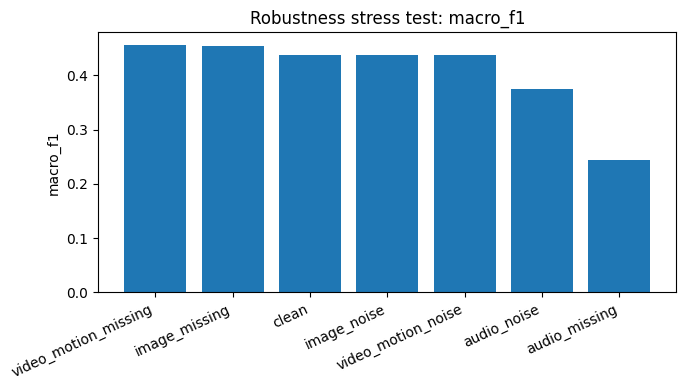

Saved: /content/ifpalvd_project/artifacts/figures/robustness_macro_f1.png


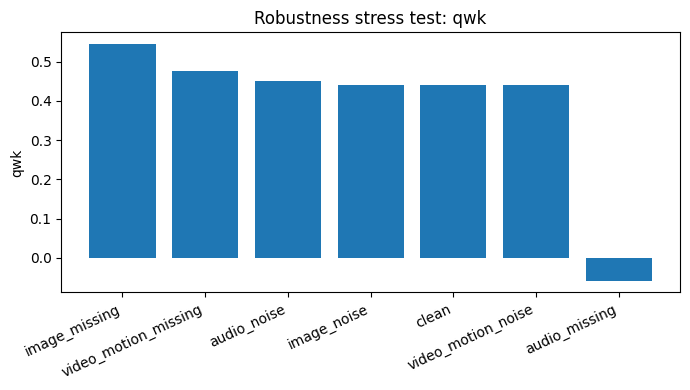

Saved: /content/ifpalvd_project/artifacts/figures/robustness_qwk.png


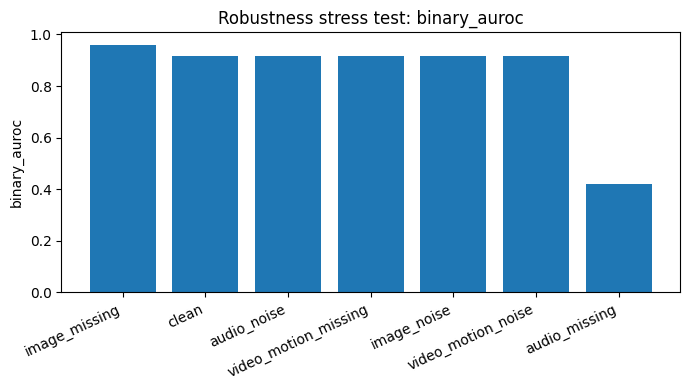

Saved: /content/ifpalvd_project/artifacts/figures/robustness_binary_auroc.png


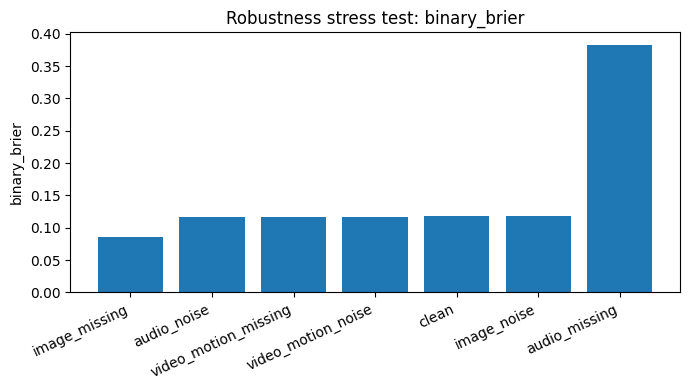

Saved: /content/ifpalvd_project/artifacts/figures/robustness_binary_brier.png


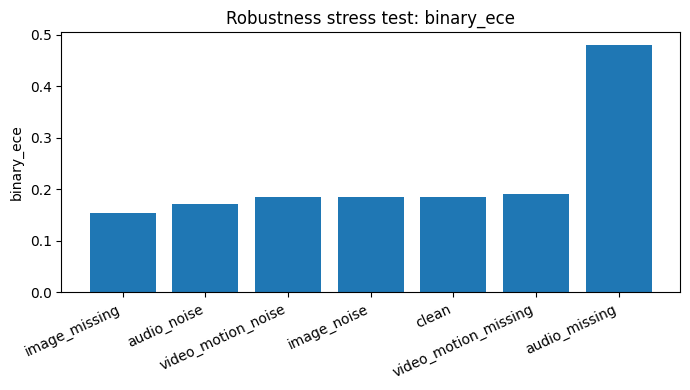

Saved: /content/ifpalvd_project/artifacts/figures/robustness_binary_ece.png


In [74]:
# ============================================================
# STEP 17B-C: Plot robustness analysis
# ============================================================

if "robustness_summary_df" in globals() and not robustness_summary_df.empty:
    for metric in ["macro_f1", "qwk", "binary_auroc", "binary_brier", "binary_ece"]:
        if metric not in robustness_summary_df.columns:
            continue

        if robustness_summary_df[metric].dropna().empty:
            continue

        ascending = metric in ["binary_brier", "binary_ece"]

        order = (
            robustness_summary_df
            .dropna(subset=[metric])
            .sort_values(metric, ascending=ascending)
        )

        plt.figure(figsize=(7, 4))
        plt.bar(order["scenario"], order[metric])
        plt.title(f"Robustness stress test: {metric}")
        plt.ylabel(metric)
        plt.xticks(rotation=25, ha="right")
        plt.tight_layout()

        out = fig_dir / f"robustness_{metric}.png"
        plt.savefig(out, dpi=300)
        plt.show()

        print("Saved:", out)

In [75]:
# ============================================================
# STEP 17C: Local explainability
# Frame attention and audio occlusion saliency
# ============================================================

def _train_final_temporal_model_for_explanation(use_audio=True):
    if "image_seq_index" not in globals() or len(image_seq_index) == 0:
        print("image_seq_index unavailable.")
        return None

    req = (
        df["video_sequence_audio_valid"] == 1
        if use_audio
        else df["video_sequence_valid"] == 1
    )

    sub = df[req].dropna(subset=["pain_code"]).copy().reset_index(drop=True)

    if len(sub) < 8 or sub["pain_code"].nunique() < 2:
        print("Insufficient data for temporal explanation.")
        return None

    seqs, masks, audio_df = _prepare_temporal_arrays(sub, use_audio=use_audio)

    nonempty = masks.any(axis=1)
    sub = sub.loc[nonempty].reset_index(drop=True)
    seqs = seqs[nonempty]
    masks = masks[nonempty]

    if use_audio:
        audio_df = audio_df.loc[nonempty].reset_index(drop=True)
        A_all, _, imp, scl = _fit_impute_scale(audio_df, audio_df)
        audio_tensor = torch.tensor(A_all, dtype=torch.float32)
        audio_dim = A_all.shape[1]
    else:
        imp = scl = None
        audio_tensor = None
        audio_dim = 0

    device_tmp = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    seq_tensor = torch.tensor(seqs, dtype=torch.float32, device=device_tmp)
    mask_tensor = torch.tensor(masks, dtype=torch.bool, device=device_tmp)
    y_tensor = torch.tensor(
        sub["pain_code"].astype(int).to_numpy(),
        dtype=torch.long,
        device=device_tmp,
    )

    if audio_tensor is not None:
        audio_tensor = audio_tensor.to(device_tmp)

    model = TemporalAttentionFusionNet(
        vision_dim=seq_tensor.shape[-1],
        audio_dim=audio_dim,
        hidden_dim=cfg.temporal_hidden_dim,
        n_classes=3,
    ).to(device_tmp)

    class_counts = np.bincount(
        sub["pain_code"].astype(int).to_numpy(),
        minlength=3,
    ).astype(float)

    class_weights = class_counts.sum() / np.clip(class_counts, 1.0, None)
    class_weights = class_weights / class_weights.mean()
    class_weights = torch.tensor(class_weights, dtype=torch.float32, device=device_tmp)

    criterion = nn.CrossEntropyLoss(weight=class_weights)
    opt = torch.optim.Adam(model.parameters(), lr=cfg.temporal_lr)

    model.train()

    for epoch in range(max(6, cfg.temporal_epochs)):
        logits = model(seq_tensor, mask_tensor, audio_tensor)
        loss = criterion(logits, y_tensor)

        opt.zero_grad()
        loss.backward()
        opt.step()

    model.eval()

    return {
        "model": model,
        "sub_df": sub,
        "seqs": seqs,
        "masks": masks,
        "audio_all": None if audio_tensor is None else audio_tensor.detach().cpu().numpy(),
        "imputer": imp,
        "scaler": scl,
        "device": device_tmp,
    }

In [76]:
def plot_temporal_attention_examples(explainer_state, n_examples=2):
    if explainer_state is None:
        print("Temporal attention explanation is unavailable.")
        return

    model = explainer_state["model"]
    sub = explainer_state["sub_df"]
    device_tmp = explainer_state["device"]
    seqs = explainer_state["seqs"]
    masks = explainer_state["masks"]
    audio_all = explainer_state["audio_all"]

    chosen = (
        sub
        .sort_values(["pain_code", "video_name"])
        .groupby("pain_level", group_keys=False)
        .head(1)
        .head(n_examples)
    )

    for idx in chosen.index:
        seq = torch.tensor(seqs[idx:idx + 1], dtype=torch.float32, device=device_tmp)
        mask = torch.tensor(masks[idx:idx + 1], dtype=torch.bool, device=device_tmp)

        aud = None
        if audio_all is not None:
            aud = torch.tensor(audio_all[idx:idx + 1], dtype=torch.float32, device=device_tmp)

        with torch.no_grad():
            logits, attn = model(seq, mask, aud, return_attention=True)
            probs = torch.softmax(logits, dim=1).cpu().numpy()[0]
            attn = attn.cpu().numpy()[0]

        row = sub.iloc[idx]
        frames = sample_video_frames(row["video_path"], cfg.temporal_n_frames)

        n_show = min(len(frames), len(attn))

        if n_show == 0:
            continue

        fig, axes = plt.subplots(
            1,
            n_show,
            figsize=(3.0 * n_show, 3.3),
        )

        if n_show == 1:
            axes = [axes]

        for j in range(n_show):
            axes[j].imshow(frames[j])
            axes[j].axis("off")
            axes[j].set_title(f"w={attn[j]:.2f}")

        pred_label = pain_order[int(np.argmax(probs))]

        fig.suptitle(
            f"Temporal attention | true={row['pain_level']} | pred={pred_label}"
        )

        plt.tight_layout()

        out = fig_dir / f"temporal_attention_{Path(row['video_name']).stem}.png"
        plt.savefig(out, dpi=300)
        plt.show()

        print("Saved:", out)

In [77]:
def extract_audio_features_from_array(y, sr):
    if len(y) < sr * 0.25:
        return {"audio_valid": 0}

    feats = {
        "audio_valid": 1,
        "audio_duration_s": len(y) / sr,
    }

    y = librosa.util.normalize(y)

    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=20)

    for i in range(mfcc.shape[0]):
        feats.update(safe_stats(mfcc[i], f"mfcc_{i + 1:02d}"))

    zcr = librosa.feature.zero_crossing_rate(y)[0]
    rms = librosa.feature.rms(y=y)[0]
    centroid = librosa.feature.spectral_centroid(y=y, sr=sr)[0]
    bandwidth = librosa.feature.spectral_bandwidth(y=y, sr=sr)[0]
    rolloff = librosa.feature.spectral_rolloff(y=y, sr=sr)[0]

    for name, arr in [
        ("zcr", zcr),
        ("rms", rms),
        ("centroid", centroid),
        ("bandwidth", bandwidth),
        ("rolloff", rolloff),
    ]:
        feats.update(safe_stats(arr, name))

    try:
        contrast = librosa.feature.spectral_contrast(
            y=y,
            sr=sr,
            n_bands=(4 if sr <= 16000 else 6),
        )

        for i in range(contrast.shape[0]):
            feats.update(safe_stats(contrast[i], f"contrast_{i + 1:02d}"))

    except Exception:
        pass

    try:
        chroma = librosa.feature.chroma_stft(y=y, sr=sr)

        for i in range(chroma.shape[0]):
            feats.update(safe_stats(chroma[i], f"chroma_{i + 1:02d}"))

    except Exception:
        pass

    return feats

In [78]:
def audio_occlusion_saliency_example(n_segments=8):
    valid_audio = (
        df[df["audio_valid"] == 1]
        .dropna(subset=["pain_binary"])
        .copy()
        .reset_index(drop=True)
    )

    if len(valid_audio) < 8:
        print("Skipping audio saliency because too few valid audio rows are available.")
        return

    X = valid_audio[audio_cols].replace([np.inf, -np.inf], np.nan)
    y = valid_audio["pain_binary"].astype(int).to_numpy()

    model = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(
            max_iter=3000,
            class_weight="balanced",
            random_state=RANDOM_STATE,
        )),
    ])

    model.fit(X, y)

    painful = valid_audio[valid_audio["pain_binary"] == 1]
    row = painful.iloc[0] if len(painful) else valid_audio.iloc[0]

    wav_path = Path(cfg.artifact_root) / "audio" / f"{Path(row['video_name']).stem}.wav"

    if not wav_path.exists():
        wav_path = extract_wav_from_video(
            row["video_path"],
            wav_path,
            cfg.sample_rate,
        )

    if wav_path is None or not Path(wav_path).exists():
        print("No waveform available for audio saliency.")
        return

    ywav, sr = librosa.load(wav_path, sr=cfg.sample_rate, mono=True)

    base_feature_row = audio_features.loc[
        audio_features["video_name"] == row["video_name"],
        audio_cols,
    ]

    if len(base_feature_row) == 0:
        print("No base audio feature row found.")
        return

    base_prob = float(model.predict_proba(base_feature_row)[:, 1][0])

    seg_edges = np.linspace(0, len(ywav), n_segments + 1).astype(int)

    drops = []
    mids = []

    for i in range(n_segments):
        lo, hi = seg_edges[i], seg_edges[i + 1]

        y_occ = ywav.copy()
        y_occ[lo:hi] = 0.0

        feats = extract_audio_features_from_array(y_occ, sr)
        feat_row = {c: feats.get(c, np.nan) for c in audio_cols}

        prob = float(model.predict_proba(pd.DataFrame([feat_row]))[:, 1][0])

        drops.append(base_prob - prob)
        mids.append((lo + hi) / 2 / sr)

    S = librosa.feature.melspectrogram(y=ywav, sr=sr, n_mels=64)
    S_db = librosa.power_to_db(S, ref=np.max)

    fig, ax = plt.subplots(
        2,
        1,
        figsize=(9, 6),
        sharex=True,
        gridspec_kw={"height_ratios": [3, 1]},
    )

    librosa.display.specshow(
        S_db,
        sr=sr,
        x_axis="time",
        y_axis="mel",
        ax=ax[0],
    )

    ax[0].set_title(
        f"Audio occlusion saliency | {row['video_name']} | "
        f"baseline pain prob={base_prob:.2f}"
    )

    ax[1].bar(
        mids,
        drops,
        width=(len(ywav) / sr) / n_segments * 0.85,
    )

    ax[1].axhline(0, linewidth=1)
    ax[1].set_ylabel("Δ pain probability")
    ax[1].set_xlabel("Time, seconds")

    plt.tight_layout()

    out = fig_dir / "audio_occlusion_saliency.png"
    plt.savefig(out, dpi=300)
    plt.show()

    print("Saved:", out)

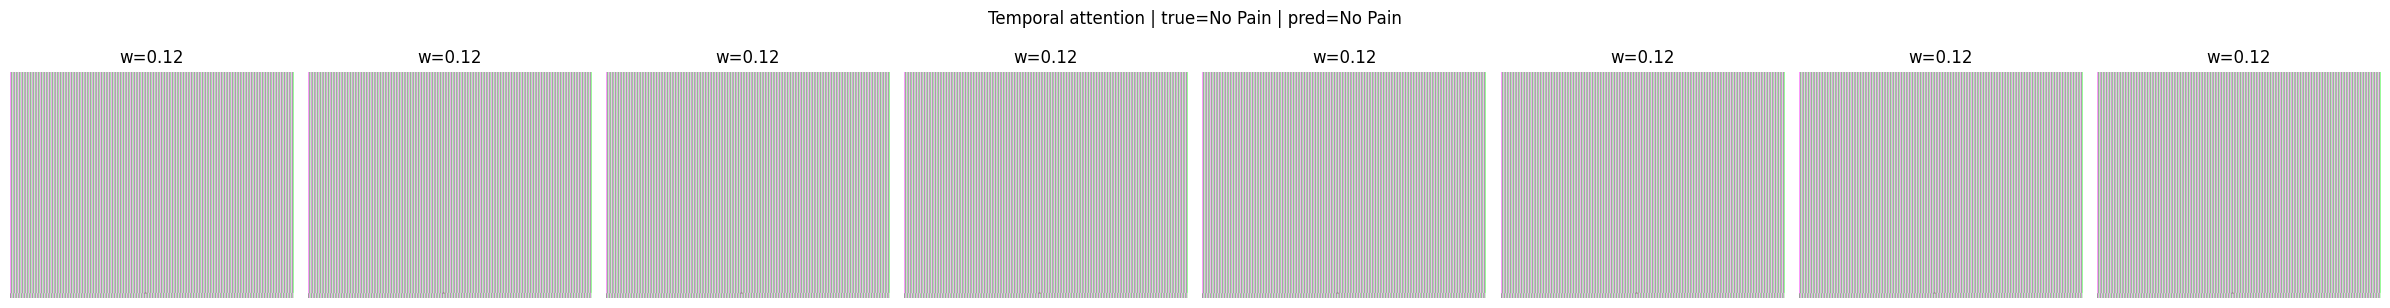

Saved: /content/ifpalvd_project/artifacts/figures/temporal_attention_kasus 11_PRE_1.png


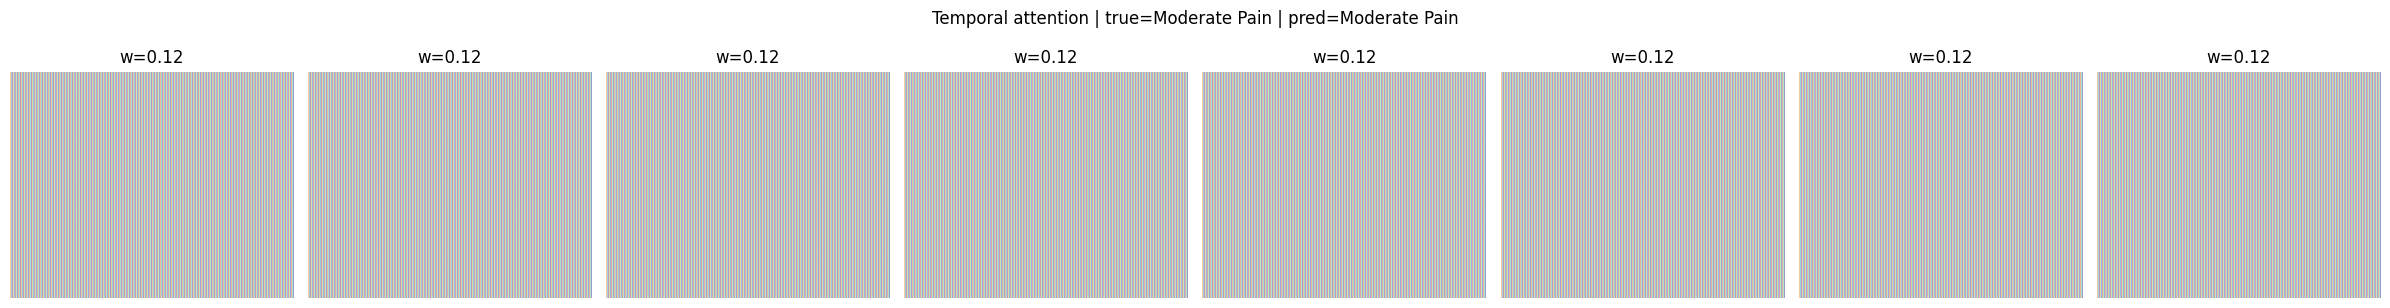

Saved: /content/ifpalvd_project/artifacts/figures/temporal_attention_kasus 10_PRE_1.png


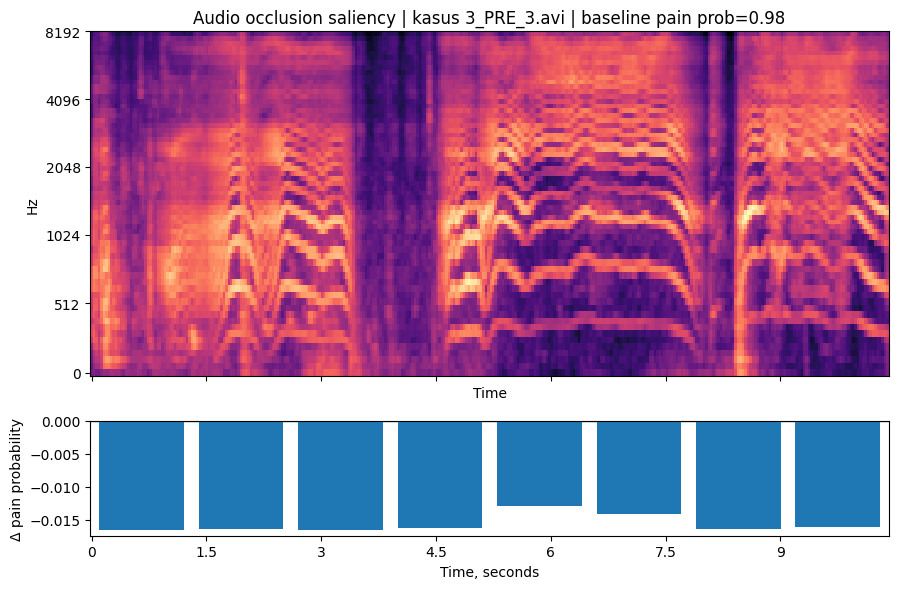

Saved: /content/ifpalvd_project/artifacts/figures/audio_occlusion_saliency.png


In [79]:
# ============================================================
# STEP 17C-B: Run local explainability
# ============================================================

if cfg.run_explainability:
    temporal_explainer_state = _train_final_temporal_model_for_explanation(use_audio=True)

    plot_temporal_attention_examples(
        temporal_explainer_state,
        n_examples=cfg.explain_n_examples,
    )

    audio_occlusion_saliency_example(n_segments=8)

else:
    print("Explainability section skipped.")

## 17d. Clinical framing and responsible use

This pipeline is intended as **decision support**, not as a replacement for clinical pain assessment. In a paper or presentation, the discussion should emphasize:

- the model estimates risk or severity from observable behavior rather than measuring pain directly
- multimodal predictions should be interpreted alongside bedside context and clinician judgment
- calibration and robustness matter because deployment settings may have missing audio, poor lighting, occlusion, or motion artifacts
- clinically safe use cases are triage, flagging, prioritization, or structured review support rather than autonomous action


18. Implemented extensions and remaining future work
Implemented in this notebook:

Explicit five-arm comparison: audio, image, image+audio, video, and video+audio.
Video-only modeling through optical-flow motion features and temporal frame-sequence attention.
Video+audio modeling through engineered audio-video fusion and temporal audio-video attention.
Ordinal modeling through a cumulative ordinal logistic baseline.
Lightweight self-supervised pretraining through cross-modal contrastive alignment on matched image/audio pairs.
Robustness analysis under missing and corrupted modalities.
Explainability using temporal frame attention and audio occlusion saliency.
Clinical framing for responsible decision-support use.
Still reasonable future work for a longer paper:

raw-encoder self-supervised pretraining on substantially larger audio–video corpora
stronger temporal backbones such as TimeSformer, VideoMAE, SlowFast, or Video Swin
external validation on another infant pain dataset
annotation-quality analysis and inter-rater uncertainty modeling

19. Draft Research & Impact Day abstract text
Title: Seeing, Hearing, and Watching Infant Pain: Comparing Image, Audio, Video, and Multimodal Models for Infant Pain Classification

Infants cannot verbally communicate pain, making clinical pain assessment dependent on observer-based interpretation of facial expression, crying, movement, and consolability. This can lead to inconsistent assessment and makes continuous monitoring difficult. We developed a multimodal pipeline to compare static image, cry audio, video-motion/temporal, and fused audiovisual models for infant pain severity using facial-expression video and cry audio, testing whether combining both behavioral signals improves pain assessment compared with either signal alone.

The study uses IFPaLVD, an openly available Infant FLACC Pain Level Video Dataset with infant videos containing both facial expression and voice, paired with labels for pain level and cry/no-cry status. Videos were processed in three ways: static frame appearance embeddings for the image-only arm, acoustic features from the soundtrack for the audio-only arm, and optical-flow/temporal frame-sequence features for the video-only arm. We compared audio, image, image+audio, video, and video+audio models using leakage-aware cross-validation designed to keep related clips from the same original infant/case together when possible. Evaluation included macro-F1, balanced accuracy, AUROC, AUPRC, ordinal error, confusion matrices, and calibration analysis for clinically relevant pain detection.

This work contributes a reproducible framework for infant pain modeling that moves beyond single-modality classification and explicitly evaluates whether multimodal behavioral cues provide more reliable pain predictions. The pipeline also supports interpretable analyses of modality contribution and model calibration, which are important for eventual clinical decision support. Final performance results should be inserted after model execution.